### **T2.4 - exploratory data analysis**

This notebook explores the engineered admission-level and hourly datasets before modelling, using descriptive tables and figures to understand cohort structure, outcome imbalance, and feature behaviour.


##### **Notebook Outline**

- **cohort description:** summarise admissions, readmission prevalence, demographics, and key clinical groups.
- **feature-family exploration:** inspect missingness, sparsity, distributions, correlations, and readmission rates across engineered feature families.
- **clinical severity visualisation:** plot psychiatric acuity, medical complexity, utilisation, discharge pathway, orders, medications, labs, vitals, and ICU activity.
- **output save:** save EDA tables and figures for reporting.


In [3]:
#load packages and shared helpers for this notebook
import sys
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import chi2_contingency, norm
from scipy.special import expit
import numpy as np
from IPython.display import display
print(sys.executable)


/scratch/DissProject/my_env/bin/python


**Load libraries and datasets**

The final engineered admission-level dataset and hourly vital-sign time-series dataset are loaded from the WP2 outputs folder. EDA tables are also saved as CSV files so figures can be recreated or refined externally if required.

In [ ]:
#set file paths and create output folders
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

project_path = Path("/scratch/DissProject")
output_path = project_path / "outputs"
eda_workbook_file = output_path / "t2_4_eda_tables.xlsx"
eda_tables = {}

admission_file = output_path / "t2_3_engineered_dataset.csv"
clinical_sequence_file = output_path / "t2_3_hourly_clinical_sequence_dataset.csv"
clinical_sequence_feature_file = output_path / "t2_3_hourly_clinical_sequence_features.csv"
clinical_sequence_available = clinical_sequence_file.exists()

#reference counts from a prior wp2.3 run are recorded for audit context rather than enforced as fixed requirements.
reference_admission_shape = (238491, 1402)
reference_admission_unique_patients = 107926
reference_admission_unique_admissions = 238491
expected_engineered_feature_count_reported_by_wp2_3 = 972

admission_required_columns = ["subject_id", "hadm_id", "admittime", "dischtime", "readmitted_30d"]
clinical_sequence_required_columns = ["subject_id", "hadm_id", "readmitted_30d", "hour_window"]
vital_columns = ["heart_rate", "respiratory_rate", "spo2", "mean_bp_noninvasive",
    "systolic_bp_noninvasive", "mean_bp_arterial", "systolic_bp_arterial"]

df = pd.read_csv(admission_file)
clinical_sequence_columns = pd.read_csv(clinical_sequence_file, nrows=0).columns.tolist() if clinical_sequence_available else []
available_hourly_vital_columns = [col for col in vital_columns if col in clinical_sequence_columns]

if clinical_sequence_available:
    hourly_vitals = pd.read_csv(clinical_sequence_file,
        usecols=clinical_sequence_required_columns + available_hourly_vital_columns)
else:
    hourly_vitals = pd.DataFrame(columns=clinical_sequence_required_columns + available_hourly_vital_columns)

#loop through each item in this feature block
for col in ["admittime", "dischtime"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

admission_missing_required_columns = [col for col in admission_required_columns if col not in df.columns]
clinical_sequence_missing_required_columns = [col for col in clinical_sequence_required_columns if col not in clinical_sequence_columns]
hourly_missing_required_columns = [col for col in clinical_sequence_required_columns if col not in hourly_vitals.columns]

admission_duplicate_id_rows = (int(df.duplicated(["subject_id", "hadm_id"]).sum())
    if not any(col in admission_missing_required_columns for col in ["subject_id", "hadm_id"]) else np.nan)
hourly_duplicate_id_rows = (int(hourly_vitals.duplicated(["subject_id", "hadm_id", "hour_window"]).sum())
    if clinical_sequence_available and not any(col in hourly_missing_required_columns for col in ["subject_id", "hadm_id", "hour_window"]) else np.nan)

input_audit_rows = [
    {"Dataset": "Admission-Level Engineered Dataset", "File": str(admission_file),
        "Observed Rows": df.shape[0], "Reference Rows": reference_admission_shape[0], "Rows Match Reference": df.shape[0] == reference_admission_shape[0],
        "Observed Columns": df.shape[1], "Reference Columns": reference_admission_shape[1], "Columns Match Reference": df.shape[1] == reference_admission_shape[1],
        "Column Meaning": "Total dataframe columns, including identifiers, timestamps, outcome, raw fields, and engineered predictors",
        "WP2.3 Engineered Features Reported": expected_engineered_feature_count_reported_by_wp2_3,
        "Unique Patients": df["subject_id"].nunique() if "subject_id" in df.columns else np.nan,
        "Reference Unique Patients": reference_admission_unique_patients,
        "Unique Admissions": df["hadm_id"].nunique() if "hadm_id" in df.columns else np.nan,
        "Reference Unique Admissions": reference_admission_unique_admissions,
        "Duplicate Key Rows": admission_duplicate_id_rows,
        "Required Columns Present": len(admission_missing_required_columns) == 0,
        "Missing Required Columns": ", ".join(admission_missing_required_columns)},
    {"Dataset": "Hourly Clinical Sequence Dataset", "File": str(clinical_sequence_file),
        "Observed Rows": hourly_vitals.shape[0] if clinical_sequence_available else np.nan,
        "Reference Rows": np.nan, "Rows Match Reference": np.nan,
        "Observed Columns": len(clinical_sequence_columns) if clinical_sequence_available else np.nan,
        "Reference Columns": np.nan, "Columns Match Reference": np.nan,
        "Column Meaning": "Admission-hour clinical timeline channels for neural sequence sensitivity analysis",
        "WP2.3 Engineered Features Reported": np.nan,
        "Unique Patients": hourly_vitals["subject_id"].nunique() if clinical_sequence_available else np.nan,
        "Reference Unique Patients": np.nan,
        "Unique Admissions": hourly_vitals["hadm_id"].nunique() if clinical_sequence_available else np.nan,
        "Reference Unique Admissions": np.nan,
        "Duplicate Key Rows": hourly_duplicate_id_rows,
        "Required Columns Present": clinical_sequence_available and len(clinical_sequence_missing_required_columns) == 0,
        "Missing Required Columns": ", ".join(clinical_sequence_missing_required_columns) if clinical_sequence_available else "File not found"}]

input_audit = pd.DataFrame(input_audit_rows)
print("Input dataset audit:")
display(input_audit)

input_audit_failures = []
#row and column counts are allowed to move when wp2.3 feature engineering changes; required fields and duplicate keys still fail.
if not clinical_sequence_available:
    input_audit_failures.append(f"Hourly clinical sequence dataset was not found: {clinical_sequence_file}.")
if admission_missing_required_columns:
    input_audit_failures.append(f"Admission-level dataset is missing required columns: {admission_missing_required_columns}.")
if clinical_sequence_available and clinical_sequence_missing_required_columns:
    input_audit_failures.append(f"Hourly clinical sequence dataset is missing required columns: {clinical_sequence_missing_required_columns}.")
if pd.notna(admission_duplicate_id_rows) and admission_duplicate_id_rows != 0:
    input_audit_failures.append(f"Admission-level dataset has {admission_duplicate_id_rows} duplicate subject_id + hadm_id rows.")
if pd.notna(hourly_duplicate_id_rows) and hourly_duplicate_id_rows != 0:
    input_audit_failures.append(f"Hourly clinical sequence dataset has {hourly_duplicate_id_rows} duplicate subject_id + hadm_id + hour_window rows.")

if input_audit_failures:
    audit_failure_message = "\n".join(input_audit_failures)
    raise ValueError(f"WP2.4 input audit failed:\n{audit_failure_message}")

print("Admission-level engineered dataset shape:", df.shape)
print("Hourly clinical sequence dataset shape:", (hourly_vitals.shape[0], len(clinical_sequence_columns)))
print("Hourly vital channels available in clinical sequence:", available_hourly_vital_columns)
print("Duplicate admission-level subject_id + hadm_id rows:", admission_duplicate_id_rows)
print("Duplicate hourly subject_id + hadm_id + hour_window rows:", hourly_duplicate_id_rows)

Input dataset audit:


,Dataset,File,Observed Rows,Reference Rows,Rows Match Reference,Observed Columns,Reference Columns,Columns Match Reference,Column Meaning,WP2.3 Engineered Features Reported,Unique Patients,Reference Unique Patients,Unique Admissions,Reference Unique Admissions,Duplicate Key Rows,Required Columns Present,Missing Required Columns
0,Admission-Level Engineered Dataset,/scratch/DissProject/outputs/t2_3_engineered_d...,238491,238491.0,True,1442,1402.0,False,"Total dataframe columns, including identifiers...",972.0,107926,107926.0,238491,238491.0,0,True,
1,Hourly Clinical Sequence Dataset,/scratch/DissProject/outputs/t2_3_hourly_clini...,1550947,NaN,NaN,39,NaN,NaN,Admission-hour clinical timeline channels for ...,NaN,29349,NaN,36494,NaN,0,True,


Admission-level engineered dataset shape: (238491, 1442)
Hourly clinical sequence dataset shape: (1550947, 39)
Hourly vital channels available in clinical sequence: ['heart_rate', 'respiratory_rate', 'spo2', 'mean_bp_noninvasive', 'systolic_bp_noninvasive', 'mean_bp_arterial', 'systolic_bp_arterial']
Duplicate admission-level subject_id + hadm_id rows: 0
Duplicate hourly subject_id + hadm_id + hour_window rows: 0


**Readable labels and helper functions**

Readable feature names are defined so tables and figures use clinical descriptions rather than raw column names. Each table is collected and later written to one Excel workbook, with one worksheet per table.

In [5]:
#readable labels for tables and figures
feature_display_names = {"readmitted_30d": "30-Day Psychiatric Readmission",
    "gender": "Gender", "anchor_age": "Age", "age_group": "Age Group",
    "admission_hour": "Admission Hour", "night_admission": "Night Admission",
    "weekend_admission": "Weekend Admission", "admission_type": "Admission Type",
    "admission_location_grouped": "Admission Source",
    "discharge_location_grouped": "Discharge Destination",
    "insurance_grouped": "Insurance", "hospital_los_days": "Hospital Length of Stay",
    "hospital_los_category": "Hospital Length of Stay Category",
    "previous_psych_admissions": "Previous Psychiatric Admissions",
    "has_previous_psych_admission": "Previous Psychiatric Admission",
    "num_transfer_events": "Transfer Events",
    "num_unique_careunits": "Unique Care Units",
    "num_procedures": "Procedures",
    "time_since_previous_psych_category": "Time Since Previous Psychiatric Admission",
    "recent_psych_admission_30d": "Previous Psychiatric Admission Within 30 Days",
    "recent_psych_admission_90d": "Previous Psychiatric Admission Within 90 Days",
    "recent_psych_admission_365d": "Previous Psychiatric Admission Within 365 Days",
    "previous_total_admissions": "Previous Hospital Admissions",
    "has_previous_hospital_admission": "Previous Hospital Admission",
    "has_previous_nonpsych_admission": "Previous Non-Psychiatric Hospital Admission",
    "has_multiple_previous_hospital_admissions": "Multiple Previous Hospital Admissions",
    "psych_diagnosis_group_count": "Psychiatric Diagnosis Groups",
    "psych_diagnosis_burden_category": "Psychiatric Diagnosis Burden",
    "nonpsych_diagnosis_burden_category": "Non-Psychiatric Diagnosis Burden",
    "total_diagnosis_burden_category": "Total Diagnosis Burden",
    "has_severe_mental_illness": "Severe Mental Illness Diagnosis",
    "has_depression": "Depression", "has_bipolar_disorder": "Bipolar Disorder",
    "has_psychotic_disorder": "Psychotic Disorder", "has_anxiety_ptsd": "Anxiety or PTSD",
    "has_substance_use": "Substance Use Disorder", 
    "has_cognitive_delirium": "Cognitive Disorder or Delirium",
    "has_personality_disorder": "Personality Disorder", "has_eating_disorder": "Eating Disorder",
    "has_neurodevelopmental_disorder": "Neurodevelopmental Disorder",
    "has_other_psych_diagnosis": "Other Psychiatric Diagnosis",
    "drg_severity_category": "DRG Severity", "drg_mortality_category": "DRG Mortality Risk",
    "high_drg_severity": "High DRG Severity", "high_drg_mortality": "High DRG Mortality Risk",
    "service_transfer_category": "Service Transfer Count",
    "high_service_transfer_burden": "High Service Transfer Burden",
    "multiple_services": "Multiple Clinical Services", "icu_type": "ICU Type",
    "had_icu_stay": "ICU Stay", "icu_utilisation_category": "ICU Utilisation",
    "multiple_icu_stays": "Multiple ICU Stays", "total_icu_los_days": "Total ICU Length of Stay",
    "prolonged_icu_stay_3plus_days": "ICU Stay of 3+ Days",
    "prolonged_icu_stay_7plus_days": "ICU Stay of 7+ Days",
    "num_psych_med_classes": "Psychiatric Medication Classes",
    "psych_medication_burden_category": "Psychiatric Medication Burden",
    "has_any_psych_medication": "Any Psychiatric Medication",
    "num_unique_drugs": "Unique Drugs Prescribed", "unique_drug_burden_category": "Unique Drug Burden",
    "polypharmacy_5plus": "Polypharmacy: 5+ Drugs", "polypharmacy_10plus": "Polypharmacy: 10+ Drugs",
    "antidepressant_antipsychotic_combination": "Antidepressant and Antipsychotic Combination",
    "mood_stabiliser_antipsychotic_combination": "Mood Stabiliser and Antipsychotic Combination",
    "had_antidepressant": "Antidepressant", "had_antipsychotic": "Antipsychotic",
    "had_mood_stabiliser": "Mood Stabiliser", "had_benzodiazepine": "Benzodiazepine",
    "had_stimulant": "Stimulant", "had_sedative_hypnotic": "Sedative or Hypnotic",
    "num_labs_measured": "Laboratory Tests Measured",
    "num_abnormal_labs": "Abnormal Laboratory Tests",
    "lab_abnormal_burden_category": "Laboratory Abnormality Burden",
    "electrolyte_abnormality_count": "Electrolyte Abnormality Count",
    "any_electrolyte_abnormality": "Any Electrolyte Abnormality",
    "renal_lab_abnormality": "Renal Laboratory Abnormality",
    "hematology_lab_abnormality": "Haematology Laboratory Abnormality",
    "num_lab_value_missing_indicators": "Laboratory Value Missingness Count",
    "num_vital_types_measured": "Vital Sign Types Measured",
    "num_vital_value_missing_indicators": "Vital Sign Missingness Count",
    "num_nonpsych_diagnoses": "Non-Psychiatric Diagnoses",
    "has_first_72h_vital_data": "First 72-Hour Vital Data Available",
    "has_drg_record": "DRG Record Available",
    "physiological_instability_score": "Physiological Instability Score",
    "physiological_instability_category": "Physiological Instability",
    "tachycardia_indicator": "Tachycardia", "severe_tachycardia_indicator": "Severe Tachycardia",
    "tachypnoea_indicator": "Tachypnoea", "hypoxia_indicator": "Hypoxia",
    "hypotension_indicator": "Hypotension", "minimum_systolic_bp": "Minimum Systolic Blood Pressure",
    "minimum_mean_bp": "Minimum Mean Blood Pressure", "heart_rate": "Heart Rate",
    "respiratory_rate": "Respiratory Rate", "spo2": "Oxygen Saturation",
    "mean_bp_noninvasive": "Mean Non-Invasive Blood Pressure",
    "systolic_bp_noninvasive": "Systolic Non-Invasive Blood Pressure", 
    "mean_bp_arterial": "Mean Arterial Blood Pressure",
    "systolic_bp_arterial": "Systolic Arterial Blood Pressure", "hour_window": "Hours Since Admission"}

feature_display_names.update({"has_first_72h_vital_data": "First 72-Hour Vital Data Available",
    "heart_rate_72h_mean": "Mean Heart Rate (72 h)",
    "heart_rate_72h_min": "Minimum Heart Rate (72 h)",
    "heart_rate_72h_max": "Maximum Heart Rate (72 h)",
    "heart_rate_72h_std": "Heart Rate Variability (72 h)",
    "heart_rate_72h_observed_hours": "Heart Rate Observed Hours (72 h)",
    "respiratory_rate_72h_mean": "Mean Respiratory Rate (72 h)",
    "respiratory_rate_72h_min": "Minimum Respiratory Rate (72 h)",
    "respiratory_rate_72h_max": "Maximum Respiratory Rate (72 h)",
    "respiratory_rate_72h_std": "Respiratory Rate Variability (72 h)",
    "respiratory_rate_72h_observed_hours": "Respiratory Rate Observed Hours (72 h)",
    "spo2_72h_mean": "Mean Oxygen Saturation (72 h)",
    "spo2_72h_min": "Minimum Oxygen Saturation (72 h)",
    "spo2_72h_max": "Maximum Oxygen Saturation (72 h)",
    "spo2_72h_std": "Oxygen Saturation Variability (72 h)",
    "spo2_72h_observed_hours": "Oxygen Saturation Observed Hours (72 h)",
    "systolic_bp_noninvasive_72h_min": "Minimum Systolic BP (72 h)",
    "systolic_bp_noninvasive_72h_mean": "Mean Systolic BP (72 h)",
    "systolic_bp_noninvasive_72h_max": "Maximum Systolic BP (72 h)",
    "systolic_bp_noninvasive_72h_std": "Systolic BP Variability (72 h)",
    "systolic_bp_noninvasive_72h_observed_hours": "Systolic BP Observed Hours (72 h)",
    "mean_bp_noninvasive_72h_min": "Minimum Mean BP (72 h)",
    "mean_bp_noninvasive_72h_mean": "Mean BP (72 h)",
    "mean_bp_noninvasive_72h_max": "Maximum Mean BP (72 h)",
    "mean_bp_noninvasive_72h_std": "Mean BP Variability (72 h)",
    "mean_bp_noninvasive_72h_observed_hours": "Mean BP Observed Hours (72 h)"})

outcome_labels = {0: "Not Readmitted", 1: "Readmitted"}

#define display name
def display_name(column):
    """Return a readable clinical label for a variable used in tables or figures."""
    if column in feature_display_names:
        return feature_display_names[column]
    readable = str(column)
    readable = re.sub(r"^(num|cat)__", "", readable)
    replacements = {
        "30d": "30-Day", "60d": "60-Day", "90d": "90-Day", "365d": "365-Day",
        "72h": "72-Hour", "48h": "48-Hour", "24h": "24-Hour", "12h": "12-Hour", "6h": "6-Hour",
        "ed": "ED", "icu": "ICU", "drg": "DRG", "emar": "EMAR", "poe": "POE",
        "bmi": "BMI", "bp": "BP", "spo2": "SpO2", "smi": "SMI", "prn": "PRN", "iv": "IV"}
    #loop through each item in this feature block
    for raw_text, replacement in replacements.items():
        readable = re.sub(rf"(?<![A-Za-z0-9]){raw_text}(?![A-Za-z0-9])", replacement, readable, flags=re.IGNORECASE)
    readable = readable.replace("_", " ")
    readable = re.sub(r"\bflag\b", "", readable, flags=re.IGNORECASE)
    readable = re.sub(r"\s+", " ", readable).strip()
    return readable.title().replace("Ed", "ED").replace("Icu", "ICU").replace("Drg", "DRG").replace("Emar", "EMAR").replace("Poe", "POE").replace("Bmi", "BMI").replace("Spo2", "SpO2").replace("Smi", "SMI").replace("Prn", "PRN").replace(" Iv ", " IV ")

#define safe file name
def safe_file_name(name):
    return re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_").lower()

#define excel sheet name
def excel_sheet_name(name):
    #excel sheet names must be 31 characters or fewer
    clean_name = safe_file_name(name)[:31]
    return clean_name or "table"

#save table
def save_table(table, name):
    sheet_name = excel_sheet_name(name)
    original_sheet_name = sheet_name
    counter = 2
    while sheet_name in eda_tables:
        suffix = f"_{counter}"
        sheet_name = f"{original_sheet_name[:31-len(suffix)]}{suffix}"
        counter += 1
    eda_tables[sheet_name] = table.copy()
    print("Added table to workbook sheet:", sheet_name)
    return sheet_name

#define count percent table
def count_percent_table(data, column, top_n=None):
    counts = data[column].value_counts(dropna=False)
    if top_n is not None:
        counts = counts.head(top_n)
    table = counts.rename_axis(display_name(column)).reset_index(name="Admissions")
    table["Percent"] = (table["Admissions"] / len(data) * 100).round(2)
    if column == "readmitted_30d":
        table[display_name(column)] = table[display_name(column)].replace(outcome_labels)
    elif column in ["night_admission", "weekend_admission", "has_previous_psych_admission", "had_icu_stay"]:
        table[display_name(column)] = table[display_name(column)].replace({0: "No", 1: "Yes"})
    return table

#define readmission summary
def readmission_summary(data, column):
    #summarise row-level records to admission-level features
    summary = (data.groupby(column, dropna=False, observed=False)
        .agg(Admissions=("readmitted_30d", "size"), Readmissions=("readmitted_30d", "sum"), Readmission_Rate=("readmitted_30d", "mean"))
        .reset_index())
    summary["Readmission Rate (%)"] = (summary["Readmission_Rate"] * 100).round(2)
    summary = summary.drop(columns="Readmission_Rate")
    summary = summary.rename(columns={column: display_name(column)})
    return summary.sort_values("Readmission Rate (%)", ascending=False)


#define distribution readmission table
def distribution_readmission_table(data, column, top_n=None):
    summary = (data.groupby(column, dropna=False, observed=False)
        .agg(Admissions=("readmitted_30d", "size"), Readmissions=("readmitted_30d", "sum"), Readmission_Rate=("readmitted_30d", "mean"))
        .reset_index())
    summary["Percent"] = (summary["Admissions"] / len(data) * 100).round(2)
    summary["Readmission Rate (%)"] = (summary["Readmission_Rate"] * 100).round(2)
    summary = summary.drop(columns="Readmission_Rate")
    summary = summary.rename(columns={column: display_name(column)})
    if column in ["night_admission", "weekend_admission", "has_previous_psych_admission", "had_icu_stay"]:
        summary[display_name(column)] = summary[display_name(column)].replace({0: "No", 1: "Yes"})
    summary = summary.sort_values("Admissions", ascending=False)
    if top_n is not None:
        summary = summary.head(top_n)
    return summary


#plot count bar
def plot_count_bar(table, category_column, title, color="#4C78A8"):
    plt.figure(figsize=(9, 5))
    sns.barplot(data=table, x=category_column, y="Admissions", color=color)
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Admissions")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

#plot rate bar
def plot_rate_bar(table, category_column, title, color="#F58518"):
    plt.figure(figsize=(9, 5))
    sns.barplot(data=table, x=category_column, y="Readmission Rate (%)", color=color)
    plt.axhline(df["readmitted_30d"].mean() * 100, color="black", linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Readmission Rate (%)")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


#additional labels for the expanded t2.3 feature set
feature_display_names.update({
    "previous_total_admissions_30d": "Previous Hospital Admissions in 30 Days",
    "previous_total_admissions_90d": "Previous Hospital Admissions in 90 Days",
    "previous_total_admissions_365d": "Previous Hospital Admissions in 365 Days",
    "previous_nonpsych_admissions_30d": "Previous Non-Psychiatric Admissions in 30 Days",
    "previous_nonpsych_admissions_90d": "Previous Non-Psychiatric Admissions in 90 Days",
    "previous_nonpsych_admissions_365d": "Previous Non-Psychiatric Admissions in 365 Days",
    "days_since_previous_hospital_admission": "Days Since Previous Hospital Admission",
    "days_since_previous_hospital_admission_filled": "Days Since Previous Hospital Admission (Filled)",
    "previous_icu_admissions": "Previous ICU Admissions",
    "has_previous_icu_admission": "Previous ICU Admission",
    "days_since_previous_icu_admission": "Days Since Previous ICU Admission",
    "days_since_previous_icu_admission_filled": "Days Since Previous ICU Admission (Filled)",
    "high_utiliser_previous_year": "High Utiliser in Previous Year",
    "previous_psych_to_total_admission_ratio": "Psychiatric-to-Total Previous Admission Ratio",
    "has_self_harm_or_suicidal_ideation": "Self-Harm or Suicidal Ideation",
    "has_alcohol_related_disorder": "Alcohol-Related Disorder",
    "has_opioid_related_disorder": "Opioid-Related Disorder",
    "has_stimulant_related_disorder": "Stimulant-Related Disorder",
    "has_diabetes": "Diabetes", "has_chronic_kidney_disease": "Chronic Kidney Disease",
    "has_copd_or_asthma": "COPD or Asthma", "has_heart_failure": "Heart Failure",
    "has_liver_disease": "Liver Disease", "has_cancer": "Cancer", "has_dementia": "Dementia",
    "charlson_comorbidity_index_simple": "Simplified Charlson Comorbidity Index",
    "elixhauser_group_count_simple": "Simplified Elixhauser Group Count",
    "has_ed_timing": "ED Timing Available", "ed_length_of_stay_hours": "ED Length of Stay (Hours)",
    "ed_to_admission_hours": "ED Registration to Admission (Hours)",
    "ed_to_ward_delay_hours": "ED to Ward Delay (Hours)",
    "microbiology_test_count": "Microbiology Test Count",
    "positive_culture_flag": "Positive Culture", "blood_culture_positive": "Blood Culture Positive",
    "urine_culture_positive": "Urine Culture Positive",
    "respiratory_culture_positive": "Respiratory Culture Positive",
    "distinct_organism_count": "Distinct Organism Count",
    "suspected_infection_flag": "Suspected Infection", "infection_burden_category": "Infection Burden",
    "administered_medication_count": "Administered Medication Count",
    "missed_dose_count": "Missed Dose Count", "missed_dose_flag": "Missed Dose",
    "incomplete_dose_not_given_count": "Incomplete Dose Not Given Count",
    "incomplete_dose_not_given_flag": "Incomplete Dose Not Given",
    "iv_medication_administration_count": "IV Medication Administration Count",
    "infusion_administration_flag": "Infusion Administration",
    "had_antibiotic_exposure": "Antibiotic Exposure", "had_opioid_exposure": "Opioid Exposure",
    "had_steroid_exposure": "Steroid Exposure", "had_iv_prescription": "IV Prescription",
    "bmi": "BMI", "weight_kg": "Weight (kg)", "height_cm": "Height (cm)", "bmi_category": "BMI Category",
    "obesity_flag": "Obesity", "underweight_flag": "Underweight", "missing_bmi_flag": "Missing BMI",
    "time_to_first_transfer_hours": "Time to First Transfer (Hours)",
    "medical_to_psych_transfer": "Medical-to-Psychiatry Transfer",
    "psych_to_medical_transfer": "Psychiatry-to-Medical Transfer",
    "same_service_admission_discharge": "Same Admission and Discharge Service",
    "last_careunit_before_discharge": "Last Care Unit Before Discharge",
    "first_72h_abnormal_hour_percent": "First 72-Hour Abnormal Vital-Hour Percent",
    "first_72h_abnormal_hour_count": "First 72-Hour Abnormal Vital-Hour Count",
    "first_72h_longest_abnormal_run_hours": "Longest First 72-Hour Abnormal Run",
    "first_72h_hours_with_2plus_instability": "First 72-Hour Hours with 2+ Instability Indicators",
    "first_72h_hours_with_3plus_instability": "First 72-Hour Hours with 3+ Instability Indicators",
    "first_72h_max_instability_score": "Maximum First 72-Hour Instability Score",
    "first_72h_mean_instability_score": "Mean First 72-Hour Instability Score",
    "has_first_72h_vital_burden_data": "First 72-Hour Vital Burden Data Available",
    "recent_psych_admission_smi_interaction": "Recent Psychiatric Admission x SMI",
    "recent_psych_admission_substance_interaction": "Recent Psychiatric Admission x Substance Use",
    "smi_antipsychotic_interaction": "SMI x Antipsychotic Use",
    "substance_benzodiazepine_interaction": "Substance Use x Benzodiazepine Use",
    "polypharmacy_age65_interaction": "Polypharmacy x Age 65+",
    "icu_physiology_instability_interaction": "ICU x Physiological Instability",
    "lab_abnormality_icu_interaction": "Laboratory Abnormality Burden x ICU"})


#readable labels for newer engineered care-transition features that appear in the final eda sections.
feature_display_names.update({
    "orders_last_24h_before_discharge": "Orders in Final 24 Hours Before Discharge",
    "orders_last_12h_before_discharge": "Orders in Final 12 Hours Before Discharge",
    "orders_last_6h_before_discharge": "Orders in Final 6 Hours Before Discharge",
    "last_order_close_to_discharge_hours": "Last Order Close to Discharge (Hours)",
    "order_activity_last_24h_to_total_ratio": "Final 24-Hour Order Share",
    "order_activity_last_12h_to_total_ratio": "Final 12-Hour Order Share",
    "late_order_intensity_score_last_12h": "Final 12-Hour Order Intensity Score",
    "late_order_severity_score_last_12h": "Final 12-Hour Order Severity Score",
    "late_order_severity_per_late_order_last_12h": "Severity per Final 12-Hour Order",
    "late_order_type_diversity_last_12h": "Final 12-Hour Order Type Diversity",
    "new_orders_last_12h_before_discharge_flag": "New Orders in Final 12 Hours",
    "discontinued_orders_last_12h_before_discharge": "Discontinued Orders in Final 12 Hours",
    "late_order_discontinuation_share": "Final Order Discontinuation Share",
    "care_team_touchpoints_last_24h_before_discharge": "Care-Team Touchpoints in Final 24 Hours",
    "care_team_touchpoints_last_12h_before_discharge": "Care-Team Touchpoints in Final 12 Hours",
    "care_team_touchpoints_last_6h_before_discharge": "Care-Team Touchpoints in Final 6 Hours",
    "care_team_touchpoints_per_hospital_day": "Care-Team Touchpoints per Hospital Day",
    "late_care_fragmentation_score": "Late Care Fragmentation Score",
    "num_lab_events_last_24h_before_discharge": "Laboratory Events in Final 24 Hours",
    "num_lab_events_last_48h_before_discharge": "Laboratory Events in Final 48 Hours",
    "abnormal_labs_last_24h_before_discharge": "Abnormal Laboratory Results in Final 24 Hours",
    "medical_workup_near_discharge_score": "Near-Discharge Medical Workup Score",
    "psychotropic_orders_last_24h_before_discharge": "Psychotropic Orders in Final 24 Hours",
    "late_medication_change_intensity_score": "Late Medication Change Intensity Score",
    "safety_orders_last_24h_before_discharge": "Safety Orders in Final 24 Hours",
    "safety_orders_last_12h_before_discharge": "Safety Orders in Final 12 Hours",
    "aftercare_quality_score": "Aftercare Quality Score",
    "protective_aftercare_present_flag": "Protective Aftercare Present",
    "low_aftercare_quality_flag": "Low Aftercare Quality",
    "quiet_risk_summary_score": "Quiet-Risk Summary Score",
    "quiet_risk_flag": "Quiet-Risk Flag",
    "discharge_medication_continuity_score": "Discharge Medication Continuity Score",
    "psychiatric_aftercare_planning_score": "Psychiatric Aftercare Planning Score",
    "unmanaged_psychiatric_discharge_risk_score": "Unmanaged Psychiatric Discharge Risk Score",
    "late_medication_change_without_discharge_med_plan_flag": "Late Medication Change Without Discharge Medication Plan",
    "home_discharge_without_medication_or_followup_plan_flag": "Home Discharge Without Medication or Follow-Up Plan",
    "psychotropic_change_without_aftercare_plan_flag": "Psychotropic Change Without Aftercare Plan",
    "medical_complexity_late_workup_home_discharge_flag": "Medical Complexity, Late Workup, and Home Discharge",
    "ed_only_crisis_pattern_score": "ED-Only Crisis Pattern Score",
    "medical_complexity_no_aftercare_flag": "Medical Complexity Without Aftercare",
    "low_psych_marker_medical_instability_flag": "Low Psychiatric Marker With Medical Instability",
    "previous_psych_admissions_180d": "Previous Psychiatric Admissions in 180 Days",
    "previous_psych_admissions_365d": "Previous Psychiatric Admissions in 365 Days",
    "previous_total_admissions_365d": "Previous Hospital Admissions in 365 Days",
    "days_since_previous_psych_admission_filled": "Days Since Previous Psychiatric Admission",
    "previous_psych_to_total_admission_ratio": "Psychiatric-to-Total Previous Admission Ratio",
    "emar_not_given_rate": "EMAR Not-Given Rate",
    "latest_bmi_before_admission_filled": "Latest BMI Before Admission",
    "days_since_latest_body_measure_filled": "Days Since Latest Body Measurement"})

MAX_TABLE_ROWS = 20
MAX_PLOT_FEATURES = 15


#define existing columns
def existing_columns(columns, data=df):
    return [column for column in columns if column in data.columns]


#define top display
def top_display(table, n=MAX_TABLE_ROWS):
    return table.head(n).copy()


#define binary yes no table
def binary_yes_no_table(data, column):
    table = distribution_readmission_table(data, column).copy()
    first_col = display_name(column)
    table[first_col] = table[first_col].replace({0: "No", 1: "Yes", 0.0: "No", 1.0: "Yes"})
    return table


#### **T2.4.1 - Dataset overview**

This section summarises the two final datasets produced by WP2.3 and confirms the readmission outcome distribution before exploratory analysis.

In [6]:
#summarise final datasets used in exploratory analysis
save_table(input_audit, "t2_4_input_dataset_audit")

dataset_summary = pd.DataFrame([
    {"Dataset": "Admission-Level Engineered Dataset", "Unit of Analysis": "Hospital admission",
        "Rows": df.shape[0], "Columns": df.shape[1],
        "Column Meaning": "Total dataframe columns, not the count of engineered features only",
        "WP2.3 Engineered Features Reported": expected_engineered_feature_count_reported_by_wp2_3,
        "Unique Patients": df["subject_id"].nunique(), "Unique Admissions": df["hadm_id"].nunique(),
        "Intended Use": "Main EDA and admission-level modelling"},
    {"Dataset": "Hourly Clinical Sequence Dataset", "Unit of Analysis": "Admission-hour",
        "Rows": hourly_vitals.shape[0], "Columns": len(clinical_sequence_columns),
        "Column Meaning": "First-72-hour vital, order, lab, EMAR, ICU, and composite event channels",
        "WP2.3 Engineered Features Reported": np.nan,
        "Unique Patients": hourly_vitals["subject_id"].nunique(), "Unique Admissions": hourly_vitals["hadm_id"].nunique(),
        "Intended Use": "Clinical-timeline neural sequence sensitivity analysis"}])

print("Dataset summary:")
display(dataset_summary)
save_table(dataset_summary, "t2_4_dataset_summary")

outcome_summary = count_percent_table(df, "readmitted_30d")
print("30-day psychiatric readmission outcome distribution:")
display(outcome_summary)
save_table(outcome_summary, "t2_4_outcome_distribution")


Added table to workbook sheet: t2_4_input_dataset_audit
Dataset summary:


,Dataset,Unit of Analysis,Rows,Columns,Column Meaning,WP2.3 Engineered Features Reported,Unique Patients,Unique Admissions,Intended Use
0,Admission-Level Engineered Dataset,Hospital admission,238491,1442,"Total dataframe columns, not the count of engi...",972.0,107926,238491,Main EDA and admission-level modelling
1,Hourly Clinical Sequence Dataset,Admission-hour,1550947,39,"First-72-hour vital, order, lab, EMAR, ICU, an...",NaN,29349,36494,Clinical-timeline neural sequence sensitivity ...


Added table to workbook sheet: t2_4_dataset_summary
30-day psychiatric readmission outcome distribution:


,30-Day Psychiatric Readmission,Admissions,Percent
0,Not Readmitted,191133,80.14
1,Readmitted,47358,19.86


Added table to workbook sheet: t2_4_outcome_distribution


't2_4_outcome_distribution'

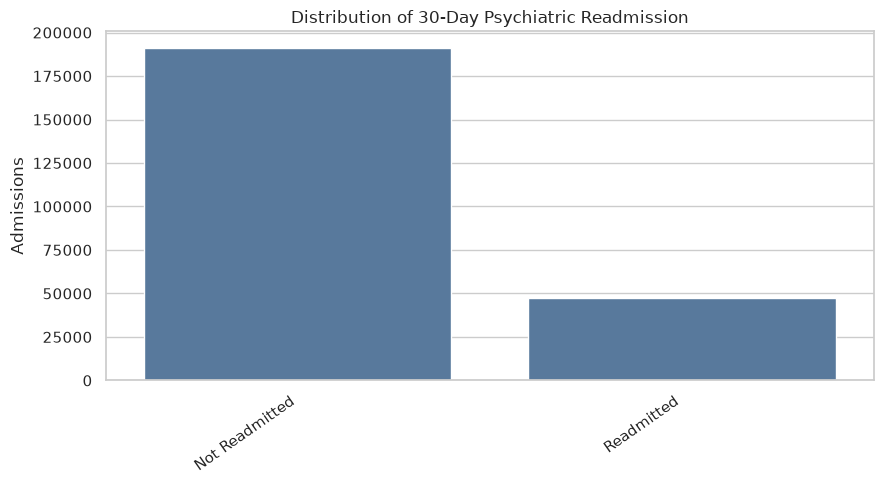

In [7]:
#plot outcome distribution
plot_count_bar(outcome_summary, "30-Day Psychiatric Readmission",
    "Distribution of 30-Day Psychiatric Readmission")


In [8]:

#summarise feature domains represented in the expanded engineered admission-level dataset
domain_feature_map = {"Demographic and admission context": ["gender", "anchor_age", "age_group", "admission_type", "admission_location_grouped", "insurance_grouped", "race", "hospital_los_days"],
    "Prior utilisation windows": ["previous_total_admissions", "previous_total_admissions_30d", "previous_total_admissions_90d", "previous_total_admissions_365d", "previous_nonpsych_admissions_30d", "previous_nonpsych_admissions_90d", "previous_nonpsych_admissions_365d", "days_since_previous_hospital_admission_filled", "previous_icu_admissions", "has_previous_icu_admission", "days_since_previous_icu_admission_filled", "high_utiliser_previous_year", "previous_psych_to_total_admission_ratio"],
    "Psychiatric diagnoses and interactions": ["psych_diagnosis_group_count", "has_severe_mental_illness", "has_self_harm_or_suicidal_ideation", "has_alcohol_related_disorder", "has_opioid_related_disorder", "has_stimulant_related_disorder", "recent_psych_admission_smi_interaction", "recent_psych_admission_substance_interaction", "smi_antipsychotic_interaction", "substance_benzodiazepine_interaction"],
    "Physical comorbidity": ["charlson_comorbidity_index_simple", "elixhauser_group_count_simple", "has_diabetes", "has_chronic_kidney_disease", "has_copd_or_asthma", "has_heart_failure", "has_liver_disease", "has_cancer", "has_dementia"],
    "Medication exposure and administration": ["num_unique_drugs", "num_psych_med_classes", "administered_medication_count", "missed_dose_count", "missed_dose_flag", "incomplete_dose_not_given_flag", "iv_medication_administration_count", "infusion_administration_flag", "had_antibiotic_exposure", "had_opioid_exposure", "had_steroid_exposure", "had_iv_prescription"],
    "Laboratory dynamics": [col for col in df.columns if col.endswith(("_lab_min_value", "_lab_max_value", "_lab_std_value", "_lab_value_change", "_lab_value_range", "_lab_severe_abnormal"))] + ["num_labs_measured", "num_abnormal_labs", "lab_abnormal_burden_category"],
    "Vital-sign burden": ["first_72h_abnormal_hour_percent", "first_72h_abnormal_hour_count", "first_72h_longest_abnormal_run_hours", "first_72h_hours_with_2plus_instability", "first_72h_hours_with_3plus_instability", "first_72h_max_instability_score", "first_72h_mean_instability_score", "has_first_72h_vital_burden_data", "physiological_instability_score", "physiological_instability_category"],
    "ED, ICU, pathway and procedures": ["has_ed_timing", "ed_length_of_stay_hours", "ed_to_admission_hours", "ed_to_ward_delay_hours", "had_icu_stay", "icu_type", "total_icu_los_days", "time_to_first_transfer_hours", "medical_to_psych_transfer", "psych_to_medical_transfer", "same_service_admission_discharge", "last_careunit_before_discharge", "num_service_transfers", "num_transfer_events", "num_procedures"],
    "Microbiology and infection": ["microbiology_test_count", "positive_culture_flag", "blood_culture_positive", "urine_culture_positive", "respiratory_culture_positive", "distinct_organism_count", "suspected_infection_flag", "infection_burden_category"],
    "OMR and body measures": ["bmi", "weight_kg", "height_cm", "bmi_category", "obesity_flag", "underweight_flag", "missing_bmi_flag"]}

feature_domain_summary_rows = []
for domain, candidate_features in domain_feature_map.items():
    available_features = existing_columns(candidate_features)
    feature_domain_summary_rows.append({"Feature Domain": domain,
        "Available Feature Count": len(available_features),
        "Example Available Features": ", ".join(display_name(col) for col in available_features[:8]) if available_features else "Not currently available"})

feature_domain_summary = pd.DataFrame(feature_domain_summary_rows)
print("Feature domain summary for the expanded engineered dataset:")
display(feature_domain_summary)
save_table(feature_domain_summary, "t2_4_feature_domain_summary")


Feature domain summary for the expanded engineered dataset:


,Feature Domain,Available Feature Count,Example Available Features
0,Demographic and admission context,8,"Gender, Age, Age Group, Admission Type, Admiss..."
1,Prior utilisation windows,13,"Previous Hospital Admissions, Previous Hospita..."
2,Psychiatric diagnoses and interactions,6,"Psychiatric Diagnosis Groups, Severe Mental Il..."
3,Physical comorbidity,6,"Diabetes, Chronic Kidney Disease, Heart Failur..."
4,Medication exposure and administration,6,"Unique Drugs Prescribed, Psychiatric Medicatio..."
5,Laboratory dynamics,51,"Creatinine Lab Max Value, Glucose Lab Max Valu..."
6,Vital-sign burden,3,"First 72-Hour Vital Burden Data Available, Phy..."
7,"ED, ICU, pathway and procedures",12,"ED Timing Available, ED Length of Stay (Hours)..."
8,Microbiology and infection,8,"Microbiology Test Count, Positive Culture, Blo..."
9,OMR and body measures,4,"BMI Category, Obesity, Underweight, Missing BMI"


Added table to workbook sheet: t2_4_feature_domain_summary


't2_4_feature_domain_summary'

#### **T2.4.2 - Cohort composition and admission context**

Demographic and admission-context variables were examined to describe the psychiatric admission cohort and the pathways through which patients entered and left hospital.

Gender Distribution:


,Gender,Admissions,Percent
0,F,121056,50.76
1,M,117435,49.24


Added table to workbook sheet: t2_4_gender_distribution


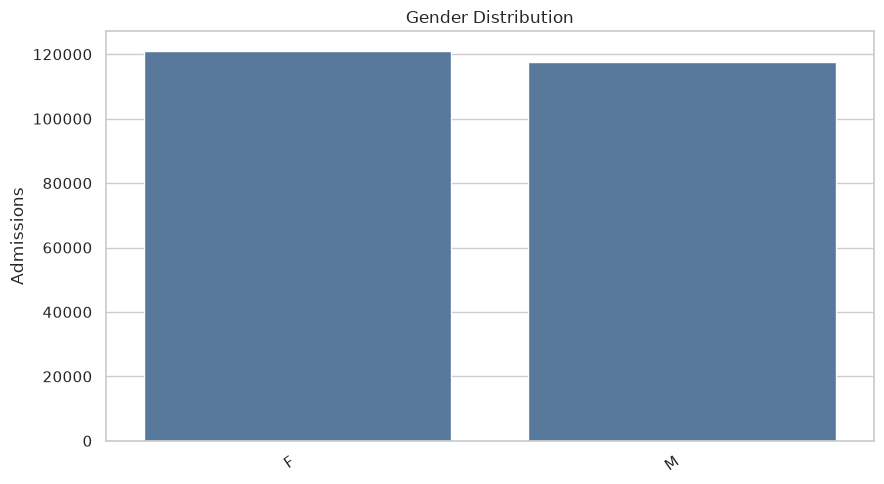

In [9]:
#table for gender distribution
if "gender" in df.columns:
    gender_table = count_percent_table(df, "gender", top_n=12)
    print("Gender Distribution:")
    display(gender_table)
    save_table(gender_table, "t2_4_gender_distribution")
    
    #plot gender distribution
    plot_count_bar(gender_table, display_name("gender"), "Gender Distribution")


Age Group Distribution and Readmission Rate:


,Age Group,Admissions,Readmissions,Percent,Readmission Rate (%)
3,50-59,48511,10756,20.34,22.17
4,60-69,42536,7859,17.84,18.48
2,40-49,36256,8608,15.20,23.74
0,18-29,30700,6650,12.87,21.66
5,70-79,28381,4229,11.90,14.90
6,80+,26200,3243,10.99,12.38
1,30-39,25907,6013,10.86,23.21


Added table to workbook sheet: t2_4_age_group_distribution_and


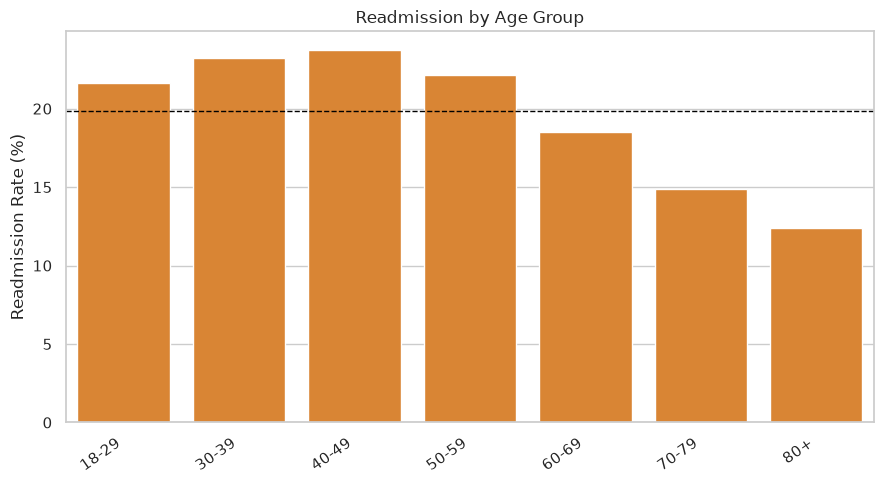

In [10]:
#table for age group distribution and readmission rate
if "age_group" in df.columns:
    age_group_table = distribution_readmission_table(df, "age_group", top_n=12)
    print("Age Group Distribution and Readmission Rate:")
    display(age_group_table)
    save_table(age_group_table, "t2_4_age_group_distribution_and_readmission_rate")

    #plot readmission by age group because this is more informative than frequency alone
    plot_rate_bar(age_group_table.sort_values(display_name("age_group")), display_name("age_group"), "Readmission by Age Group")


Admission Hour and Readmission Rate:


,Admission Hour,Admissions,Readmissions,Readmission Rate (%)
0,0,16900,2974,17.60
1,1,9791,1927,19.68
2,2,8211,1522,18.54
3,3,6414,1192,18.58
4,4,6548,1314,20.07
5,5,5973,1128,18.88
6,6,6014,1254,20.85
7,7,8400,1518,18.07
8,8,4604,827,17.96
9,9,3536,652,18.44


Added table to workbook sheet: t2_4_admission_hour_readmission


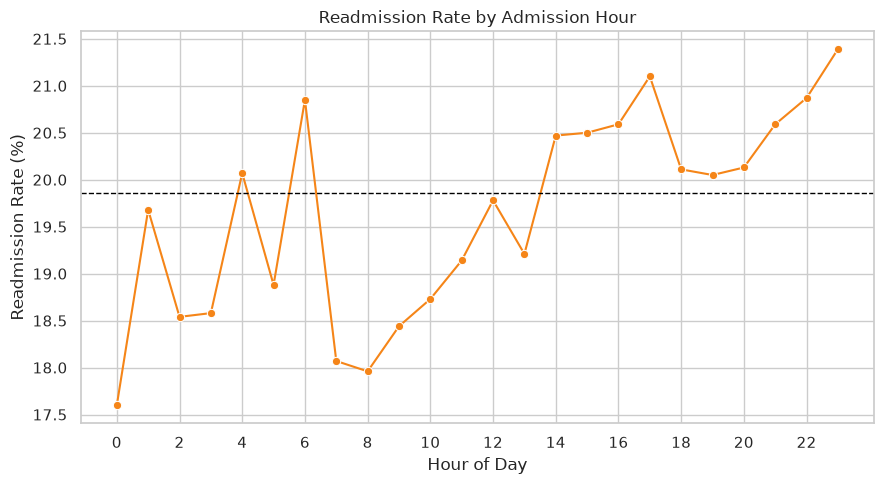

In [11]:
#table for admission hour and readmission rate
if "admission_hour" in df.columns:
    admission_hour_readmission_table = readmission_summary(df, "admission_hour").sort_values("Admission Hour")
    print("Admission Hour and Readmission Rate:")
    display(admission_hour_readmission_table)
    save_table(admission_hour_readmission_table, "t2_4_admission_hour_readmission_rate")

    #plot readmission rate by admission hour instead of admission-hour frequency
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=admission_hour_readmission_table, x="Admission Hour", y="Readmission Rate (%)", marker="o", color="#F58518")
    plt.axhline(df["readmitted_30d"].mean() * 100, color="black", linestyle="--", linewidth=1)
    plt.title("Readmission Rate by Admission Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Readmission Rate (%)")
    plt.xticks(range(0, 24, 2))
    plt.tight_layout()
    plt.show()


Night Admission Distribution and Readmission Rate:


,Night Admission,Admissions,Readmissions,Percent,Readmission Rate (%)
0,No,149384,29870,62.64,20.00
1,Yes,89107,17488,37.36,19.63


Added table to workbook sheet: t2_4_night_admission_distributi


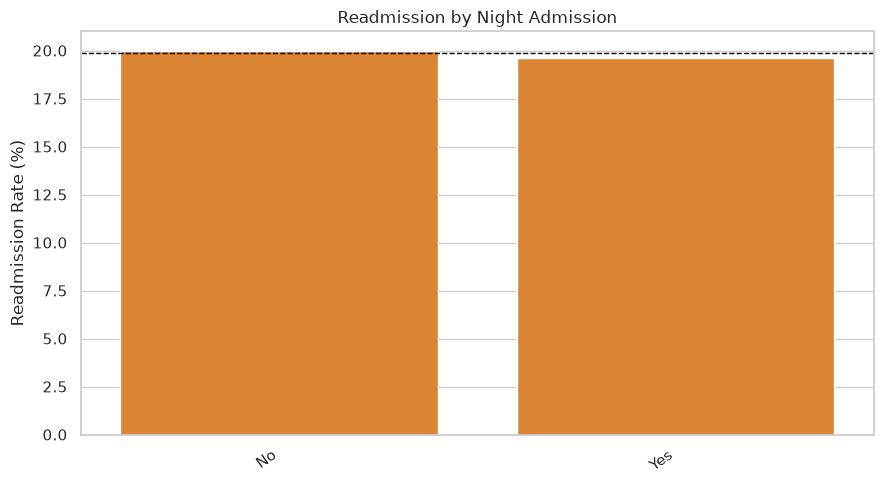

In [12]:
#table for night admission distribution and readmission rate
if "night_admission" in df.columns:
    night_admission_table = distribution_readmission_table(df, "night_admission", top_n=12)
    print("Night Admission Distribution and Readmission Rate:")
    display(night_admission_table)
    save_table(night_admission_table, "t2_4_night_admission_distribution_and_readmission_rate")

    #plot readmission by night admission
    plot_rate_bar(night_admission_table, display_name("night_admission"), "Readmission by Night Admission")


Weekend Admission Distribution and Readmission Rate:


,Weekend Admission,Admissions,Readmissions,Percent,Readmission Rate (%)
0,No,169471,33479,71.06,19.76
1,Yes,69020,13879,28.94,20.11


Added table to workbook sheet: t2_4_weekend_admission_distribu


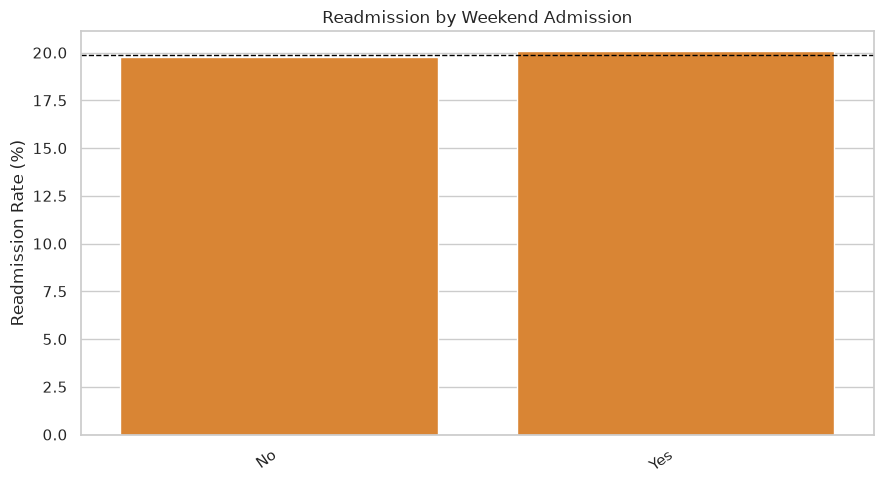

In [13]:
#table for weekend admission distribution and readmission rate
if "weekend_admission" in df.columns:
    weekend_admission_table = distribution_readmission_table(df, "weekend_admission", top_n=12)
    print("Weekend Admission Distribution and Readmission Rate:")
    display(weekend_admission_table)
    save_table(weekend_admission_table, "t2_4_weekend_admission_distribution_and_readmission_rate")

    #plot readmission by weekend admission
    plot_rate_bar(weekend_admission_table, display_name("weekend_admission"), "Readmission by Weekend Admission")


Hospital Length of Stay Distribution and Readmission Rate:


,Hospital Length of Stay Category,Admissions,Readmissions,Percent,Readmission Rate (%)
2,3-7 days,68731,12484,28.82,18.16
1,1-3 days,64843,11134,27.19,17.17
0,0-1 days,53962,13850,22.63,25.67
3,7+ days,50955,9890,21.37,19.41


Added table to workbook sheet: t2_4_hospital_length_of_stay_di


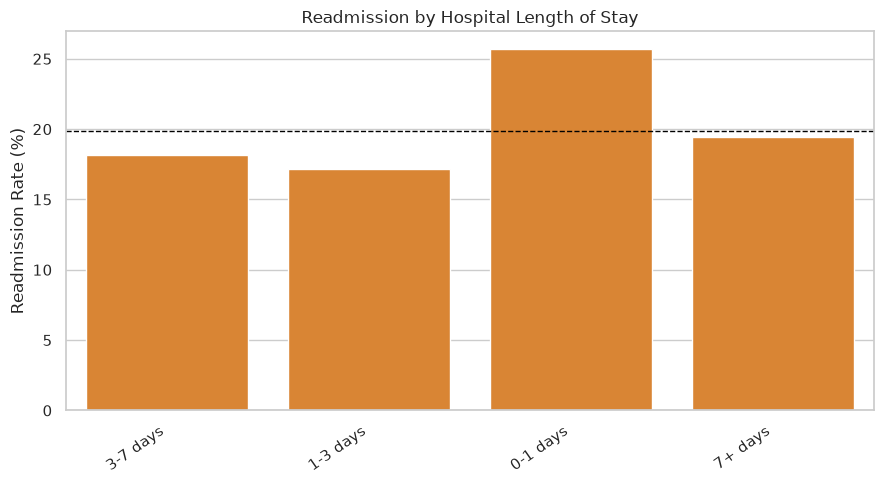

In [14]:
#table for hospital length of stay distribution and readmission rate
if "hospital_los_category" in df.columns:
    hospital_los_category_table = distribution_readmission_table(df, "hospital_los_category", top_n=12)
    print("Hospital Length of Stay Distribution and Readmission Rate:")
    display(hospital_los_category_table)
    save_table(hospital_los_category_table, "t2_4_hospital_length_of_stay_distribution_and_readmission_rate")

    #plot readmission by hospital length of stay category
    plot_rate_bar(hospital_los_category_table, display_name("hospital_los_category"), "Readmission by Hospital Length of Stay")


Admission Source Distribution and Readmission Rate:


,Admission Source,Admissions,Readmissions,Percent,Readmission Rate (%)
0,Emergency room,113811,24714,47.72,21.71
3,Physician / clinic referral,63572,12114,26.66,19.06
4,Transfer from hospital,26721,3710,11.20,13.88
2,Other,24519,5089,10.28,20.76
1,Internal transfer involving psych,5825,1013,2.44,17.39
5,Transfer from skilled nursing facility,3830,686,1.61,17.91
6,Unknown,213,32,0.09,15.02


Added table to workbook sheet: t2_4_admission_source_distribut


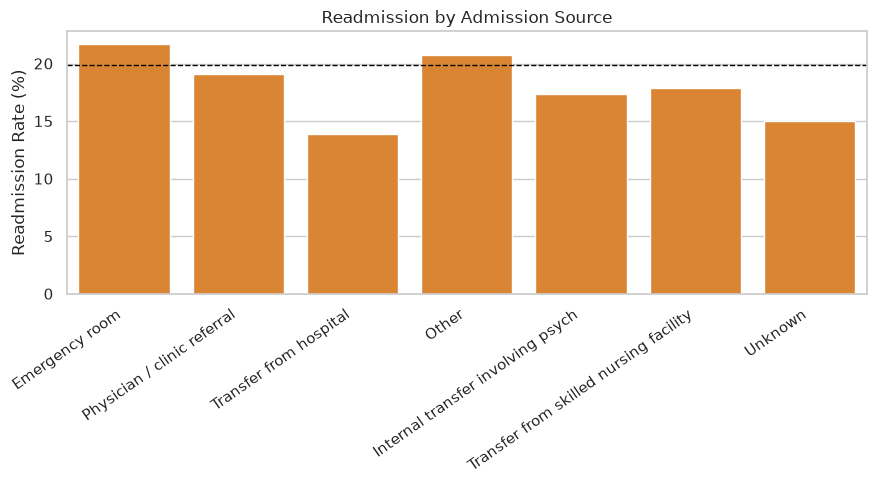

In [15]:
#table for admission source distribution and readmission rate
if "admission_location_grouped" in df.columns:
    admission_location_grouped_table = distribution_readmission_table(df, "admission_location_grouped", top_n=12)
    print("Admission Source Distribution and Readmission Rate:")
    display(admission_location_grouped_table)
    save_table(admission_location_grouped_table, "t2_4_admission_source_distribution_and_readmission_rate")

    #plot readmission by admission source
    plot_rate_bar(admission_location_grouped_table, display_name("admission_location_grouped"), "Readmission by Admission Source")


Discharge Destination Distribution and Readmission Rate:


,Discharge Destination,Admissions,Readmissions,Percent,Readmission Rate (%)
5,Unknown / not modelled,77769,17895,32.61,23.01
1,Home,72493,11551,30.40,15.93
2,Home health care,41194,8499,17.27,20.63
0,Facility / rehab / long-term care,38534,6236,16.16,16.18
3,Other,5568,1661,2.33,29.83
4,Psych facility,2933,1516,1.23,51.69


Added table to workbook sheet: t2_4_discharge_destination_dist


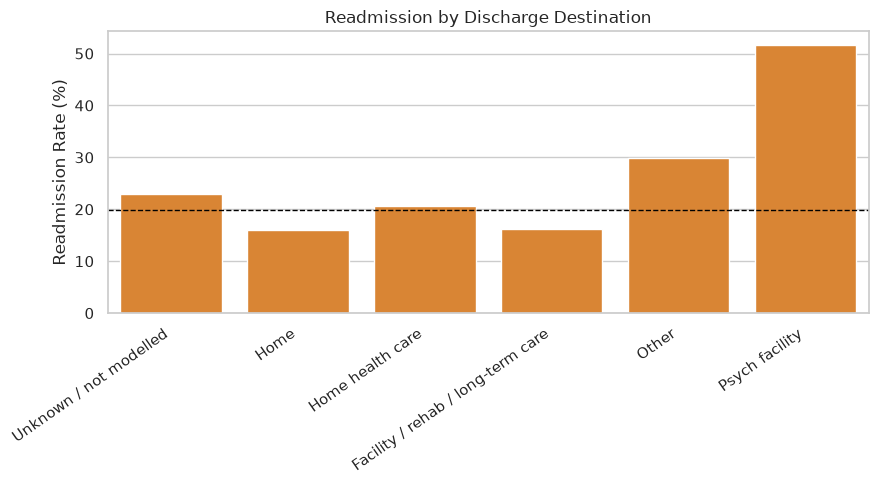

In [16]:
#table for discharge destination distribution and readmission rate
if "discharge_location_grouped" in df.columns:
    discharge_location_grouped_table = distribution_readmission_table(df, "discharge_location_grouped", top_n=12)
    print("Discharge Destination Distribution and Readmission Rate:")
    display(discharge_location_grouped_table)
    save_table(discharge_location_grouped_table, "t2_4_discharge_destination_distribution_and_readmission_rate")

    #plot readmission by discharge destination
    plot_rate_bar(discharge_location_grouped_table, display_name("discharge_location_grouped"), "Readmission by Discharge Destination")


Insurance Distribution and Readmission Rate:


,Insurance,Admissions,Readmissions,Percent,Readmission Rate (%)
1,Medicare,106133,20026,44.50,18.87
0,Medicaid,60599,14799,25.41,24.42
3,Private,59987,10244,25.15,17.08
2,Other / unknown,11772,2289,4.94,19.44


Added table to workbook sheet: t2_4_insurance_distribution_and


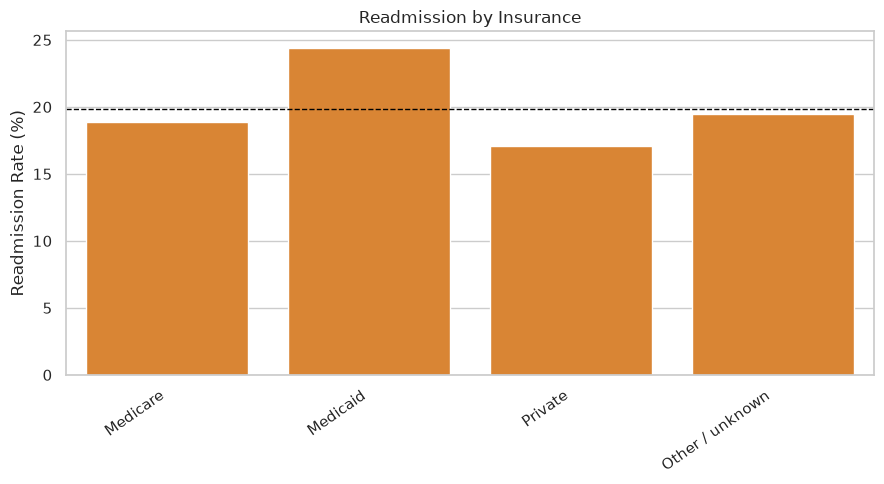

In [17]:
#table for insurance distribution and readmission rate
if "insurance_grouped" in df.columns:
    insurance_grouped_table = distribution_readmission_table(df, "insurance_grouped", top_n=12)
    print("Insurance Distribution and Readmission Rate:")
    display(insurance_grouped_table)
    save_table(insurance_grouped_table, "t2_4_insurance_distribution_and_readmission_rate")

    #plot readmission by insurance
    plot_rate_bar(insurance_grouped_table, display_name("insurance_grouped"), "Readmission by Insurance")


#### **T2.4.3 - Clinical burden, severity, and care pathway complexity**

Clinical burden features were explored across previous psychiatric admission recency, diagnosis burden, DRG severity, medication burden, laboratory abnormality burden, physiological instability, service transfers, and ICU use.

Time Since Previous Psychiatric Admission Distribution:


,Time Since Previous Psychiatric Admission,Admissions,Percent
0,No previous psychiatric admission,107926,45.25
1,0-30 days,47674,19.99
2,365+ days,30039,12.60
3,31-90 days,23135,9.70
4,91-180 days,14902,6.25
5,181-365 days,14815,6.21


Added table to workbook sheet: t2_4_time_since_previous_psychi


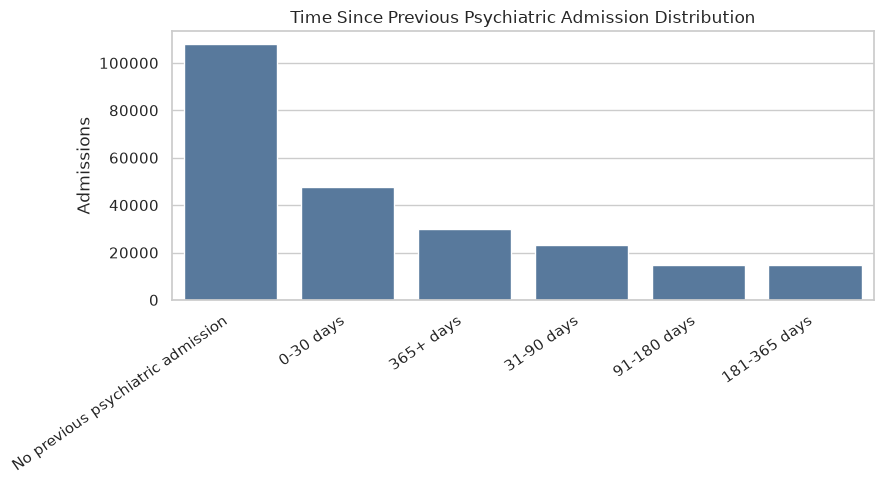

In [18]:
#table for time since previous psychiatric admission distribution
if "time_since_previous_psych_category" in df.columns:
    time_since_previous_psych_category_table = count_percent_table(df, "time_since_previous_psych_category", top_n=12)
    print("Time Since Previous Psychiatric Admission Distribution:")
    display(time_since_previous_psych_category_table)
    save_table(time_since_previous_psych_category_table, "t2_4_time_since_previous_psychiatric_admission_distribution")

    #plot time since previous psychiatric admission distribution
    plot_count_bar(time_since_previous_psych_category_table, display_name("time_since_previous_psych_category"), "Time Since Previous Psychiatric Admission Distribution")


Psychiatric Diagnosis Burden Distribution:


,Psychiatric Diagnosis Burden,Admissions,Percent
0,1 diagnosis,132132,55.40
1,2 diagnoses,61393,25.74
2,3-4 diagnoses,36590,15.34
3,5+ diagnoses,8376,3.51


Added table to workbook sheet: t2_4_psychiatric_diagnosis_burd


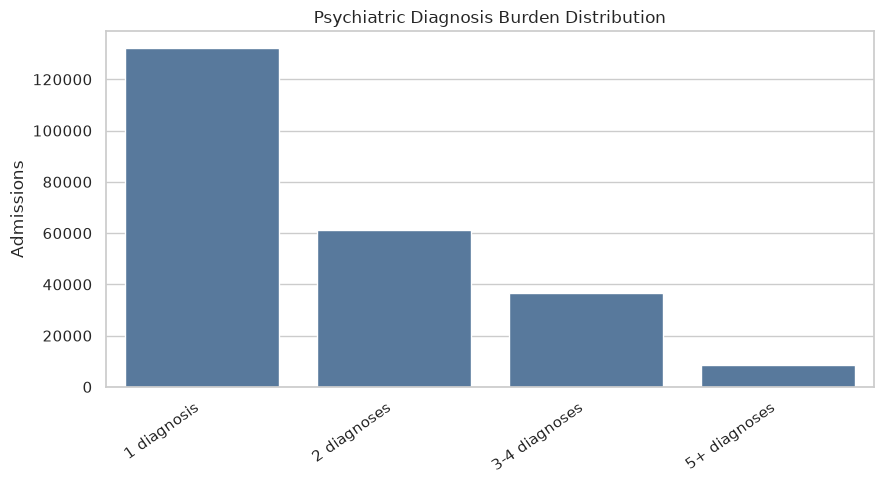

In [19]:
#table for psychiatric diagnosis burden distribution
if "psych_diagnosis_burden_category" in df.columns:
    psych_diagnosis_burden_category_table = count_percent_table(df, "psych_diagnosis_burden_category", top_n=12)
    print("Psychiatric Diagnosis Burden Distribution:")
    display(psych_diagnosis_burden_category_table)
    save_table(psych_diagnosis_burden_category_table, "t2_4_psychiatric_diagnosis_burden_distribution")

    #plot psychiatric diagnosis burden distribution
    plot_count_bar(psych_diagnosis_burden_category_table, display_name("psych_diagnosis_burden_category"), "Psychiatric Diagnosis Burden Distribution")


Non-Psychiatric Diagnosis Burden Distribution:


,Non-Psychiatric Diagnosis Burden,Admissions,Percent
0,11+,114273,47.92
1,6-10,61533,25.80
2,1-5,55204,23.15
3,0,7481,3.14


Added table to workbook sheet: t2_4_non_psychiatric_diagnosis_


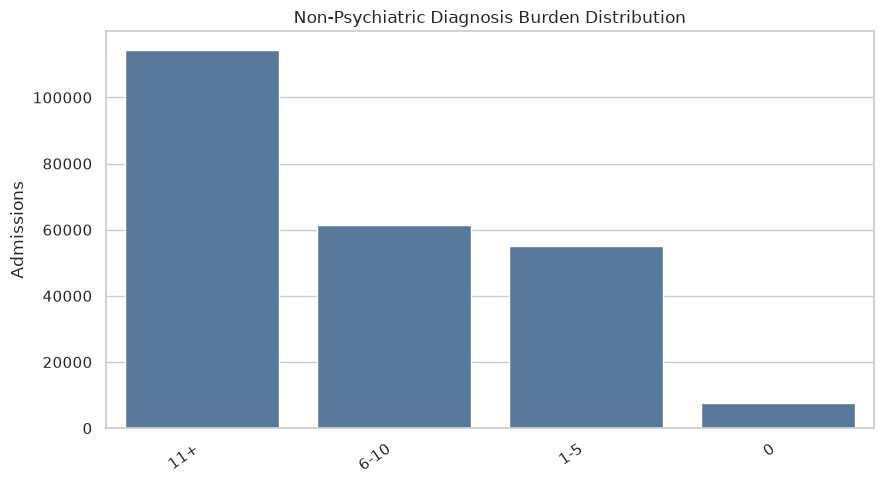

In [20]:
#table for non-psychiatric diagnosis burden distribution
if "nonpsych_diagnosis_burden_category" in df.columns:
    nonpsych_diagnosis_burden_category_table = count_percent_table(df, "nonpsych_diagnosis_burden_category", top_n=12)
    print("Non-Psychiatric Diagnosis Burden Distribution:")
    display(nonpsych_diagnosis_burden_category_table)
    save_table(nonpsych_diagnosis_burden_category_table, "t2_4_non_psychiatric_diagnosis_burden_distribution")

    #plot non-psychiatric diagnosis burden distribution
    plot_count_bar(nonpsych_diagnosis_burden_category_table, display_name("nonpsych_diagnosis_burden_category"), "Non-Psychiatric Diagnosis Burden Distribution")


Total Diagnosis Burden Distribution:


,Total Diagnosis Burden,Admissions,Percent
0,11-20,94059,39.44
1,6-10,61914,25.96
2,21+,41905,17.57
3,0-5,40613,17.03


Added table to workbook sheet: t2_4_total_diagnosis_burden_dis


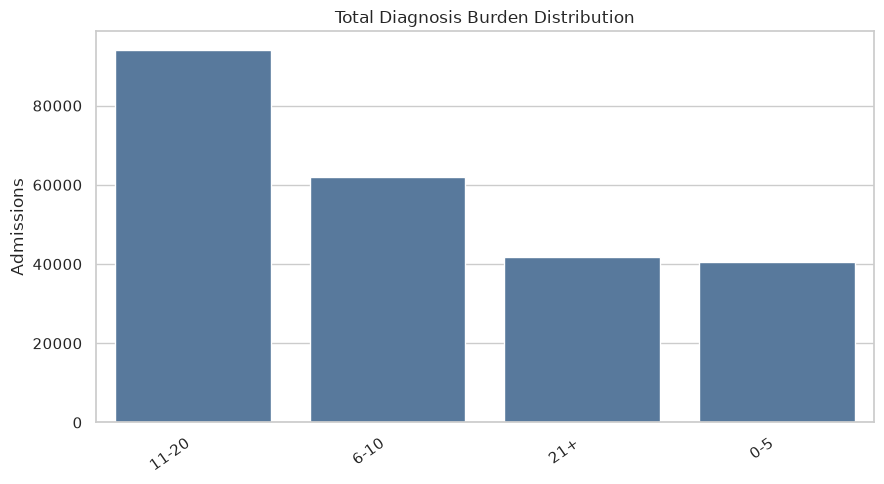

In [21]:
#table for total diagnosis burden distribution
if "total_diagnosis_burden_category" in df.columns:
    total_diagnosis_burden_category_table = count_percent_table(df, "total_diagnosis_burden_category", top_n=12)
    print("Total Diagnosis Burden Distribution:")
    display(total_diagnosis_burden_category_table)
    save_table(total_diagnosis_burden_category_table, "t2_4_total_diagnosis_burden_distribution")

    #plot total diagnosis burden distribution
    plot_count_bar(total_diagnosis_burden_category_table, display_name("total_diagnosis_burden_category"), "Total Diagnosis Burden Distribution")


DRG Severity Distribution:


,DRG Severity,Admissions,Percent
0,No DRG record,79838,33.48
1,Major,57893,24.27
2,Moderate,53318,22.36
3,Extreme,26154,10.97
4,Minor,21288,8.93


Added table to workbook sheet: t2_4_drg_severity_distribution


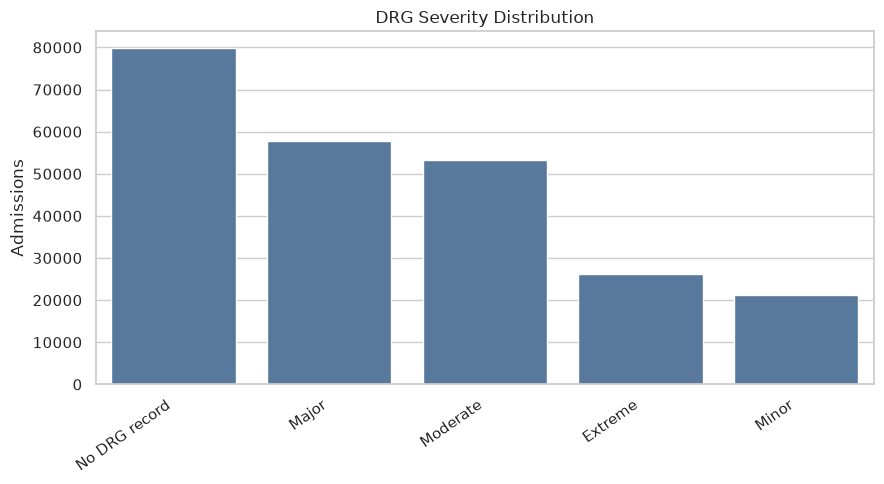

In [22]:
#table for drg severity distribution
if "drg_severity_category" in df.columns:
    drg_severity_category_table = count_percent_table(df, "drg_severity_category", top_n=12)
    print("DRG Severity Distribution:")
    display(drg_severity_category_table)
    save_table(drg_severity_category_table, "t2_4_drg_severity_distribution")

    #plot drg severity distribution
    plot_count_bar(drg_severity_category_table, display_name("drg_severity_category"), "DRG Severity Distribution")


DRG Mortality Risk Distribution:


,DRG Mortality Risk,Admissions,Percent
0,No DRG record,79838,33.48
1,Minor,54140,22.70
2,Moderate,44944,18.85
3,Major,38870,16.30
4,Extreme,20699,8.68


Added table to workbook sheet: t2_4_drg_mortality_risk_distrib


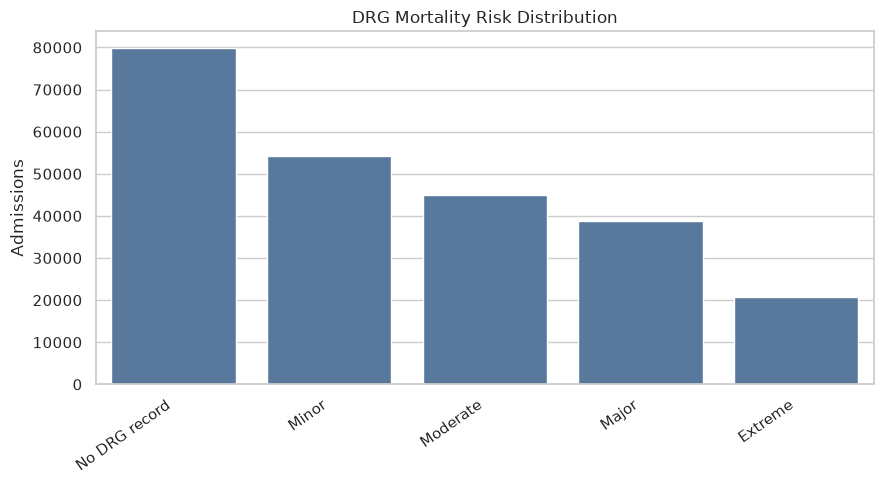

In [23]:
#table for drg mortality risk distribution
if "drg_mortality_category" in df.columns:
    drg_mortality_category_table = count_percent_table(df, "drg_mortality_category", top_n=12)
    print("DRG Mortality Risk Distribution:")
    display(drg_mortality_category_table)
    save_table(drg_mortality_category_table, "t2_4_drg_mortality_risk_distribution")

    #plot drg mortality risk distribution
    plot_count_bar(drg_mortality_category_table, display_name("drg_mortality_category"), "DRG Mortality Risk Distribution")


Service Transfer Count Distribution:


,Service Transfer Count,Admissions,Percent
0,0 transfers,221640,92.93
1,1 transfer,13646,5.72
2,2+ transfers,3205,1.34


Added table to workbook sheet: t2_4_service_transfer_count_dis


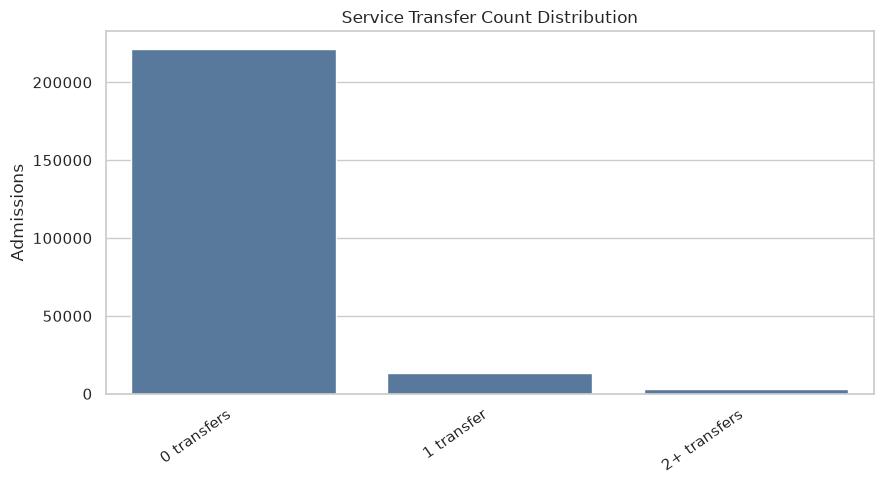

In [24]:
#table for service transfer count distribution
if "service_transfer_category" in df.columns:
    service_transfer_category_table = count_percent_table(df, "service_transfer_category", top_n=12)
    print("Service Transfer Count Distribution:")
    display(service_transfer_category_table)
    save_table(service_transfer_category_table, "t2_4_service_transfer_count_distribution")

    #plot service transfer count distribution
    plot_count_bar(service_transfer_category_table, display_name("service_transfer_category"), "Service Transfer Count Distribution")


Physical Transfer Events Distribution:


,Physical Transfer Category,Admissions,Percent
0,3-4 transfer events,166309,69.73
1,5+ transfer events,49533,20.77
2,0-2 transfer events,22649,9.50


Added table to workbook sheet: t2_4_physical_transfer_events_d


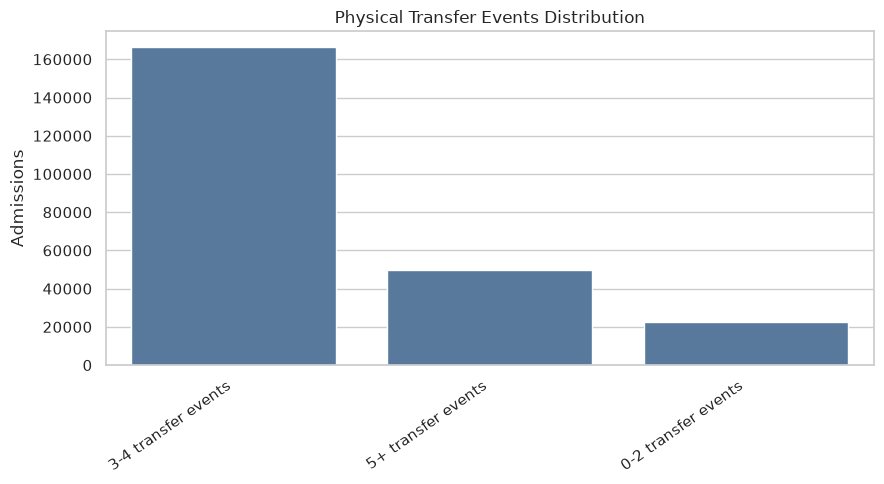

Procedure Burden Distribution:


,Procedure Burden Category,Admissions,Percent
0,0 procedures,129332,54.23
1,1-2 procedures,62966,26.40
2,3+ procedures,46193,19.37


Added table to workbook sheet: t2_4_procedure_burden_distribut


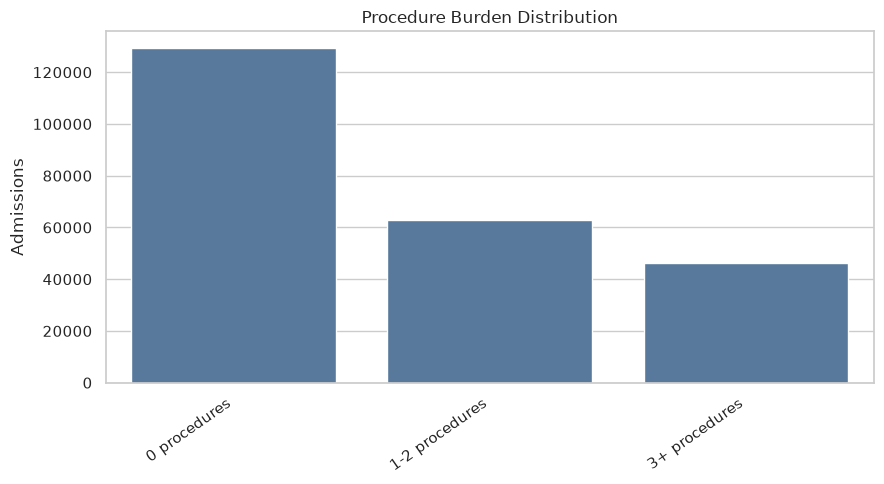

In [25]:
#tables for physical transfer and procedure burden distributions
if "physical_transfer_category" in df.columns:
    physical_transfer_category_table = count_percent_table(df, "physical_transfer_category", top_n=12)
    print("Physical Transfer Events Distribution:")
    display(physical_transfer_category_table)
    save_table(physical_transfer_category_table, "t2_4_physical_transfer_events_distribution")

    #plot physical transfer event distribution
    plot_count_bar(physical_transfer_category_table, display_name("physical_transfer_category"), "Physical Transfer Events Distribution")

if "procedure_burden_category" in df.columns:
    procedure_burden_category_table = count_percent_table(df, "procedure_burden_category", top_n=12)
    print("Procedure Burden Distribution:")
    display(procedure_burden_category_table)
    save_table(procedure_burden_category_table, "t2_4_procedure_burden_distribution")

    #plot procedure burden distribution
    plot_count_bar(procedure_burden_category_table, display_name("procedure_burden_category"), "Procedure Burden Distribution")


Psychiatric Medication Burden Distribution:


,Psychiatric Medication Burden,Admissions,Percent
0,0 classes,79739,33.43
1,1 class,64385,27.00
2,2 classes,55982,23.47
3,3+ classes,38385,16.09


Added table to workbook sheet: t2_4_psychiatric_medication_bur


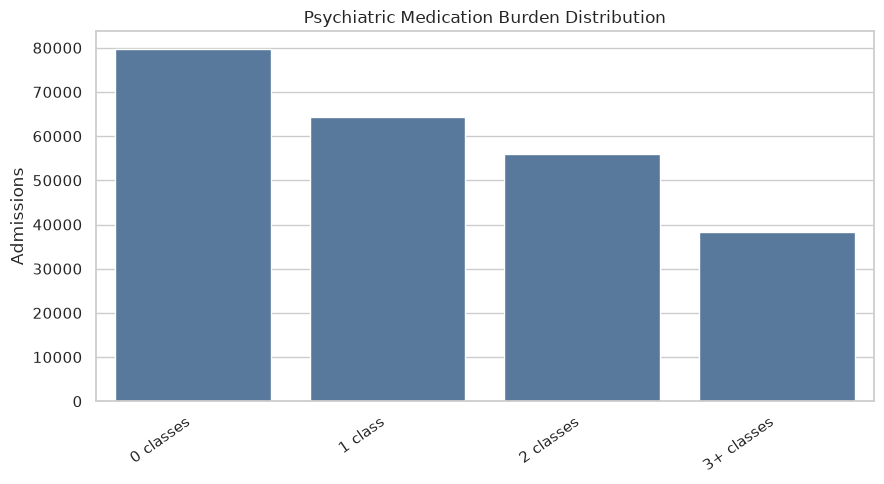

In [26]:
#table for psychiatric medication burden distribution
if "psych_medication_burden_category" in df.columns:
    psych_medication_burden_category_table = count_percent_table(df, "psych_medication_burden_category", top_n=12)
    print("Psychiatric Medication Burden Distribution:")
    display(psych_medication_burden_category_table)
    save_table(psych_medication_burden_category_table, "t2_4_psychiatric_medication_burden_distribution")

    #plot psychiatric medication burden distribution
    plot_count_bar(psych_medication_burden_category_table, display_name("psych_medication_burden_category"), "Psychiatric Medication Burden Distribution")


Unique Drug Burden Distribution:


,Unique Drug Burden,Admissions,Percent
0,10+ drugs,177939,74.61
1,0 drugs,44585,18.69
2,5-9 drugs,14058,5.89
3,1-4 drugs,1909,0.80


Added table to workbook sheet: t2_4_unique_drug_burden_distrib


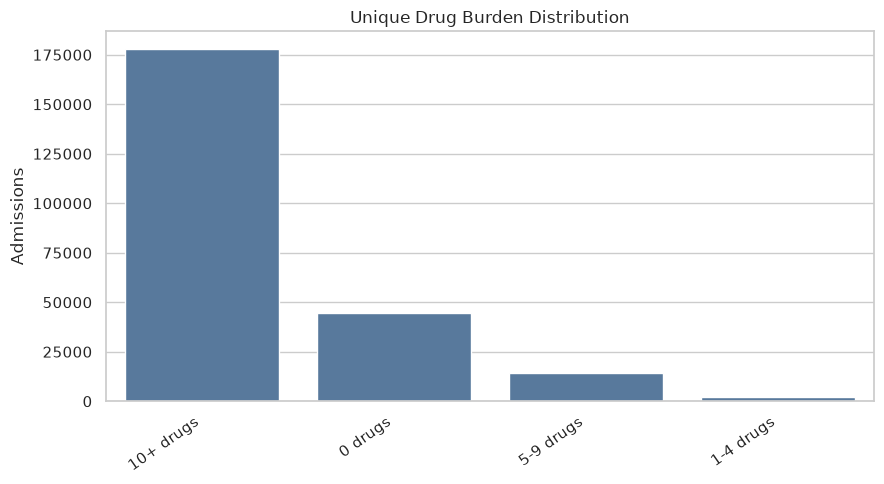

In [27]:
#table for unique drug burden distribution
if "unique_drug_burden_category" in df.columns:
    unique_drug_burden_category_table = count_percent_table(df, "unique_drug_burden_category", top_n=12)
    print("Unique Drug Burden Distribution:")
    display(unique_drug_burden_category_table)
    save_table(unique_drug_burden_category_table, "t2_4_unique_drug_burden_distribution")

    #plot unique drug burden distribution
    plot_count_bar(unique_drug_burden_category_table, display_name("unique_drug_burden_category"), "Unique Drug Burden Distribution")


Laboratory Abnormality Burden Distribution:


,Laboratory Abnormality Burden,Admissions,Percent
0,3+ abnormal labs,124326,52.13
1,0 abnormal labs,68017,28.52
2,2 abnormal labs,26886,11.27
3,1 abnormal lab,19262,8.08


Added table to workbook sheet: t2_4_laboratory_abnormality_bur


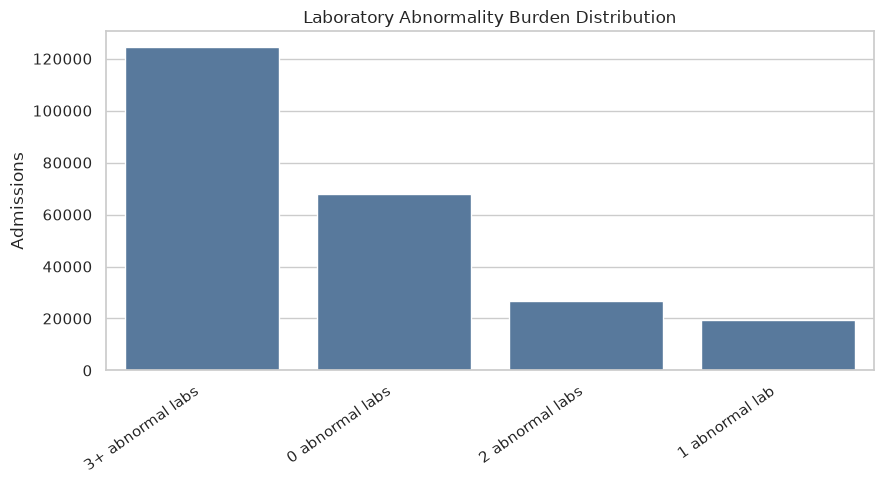

In [28]:
#table for laboratory abnormality burden distribution
if "lab_abnormal_burden_category" in df.columns:
    lab_abnormal_burden_category_table = count_percent_table(df, "lab_abnormal_burden_category", top_n=12)
    print("Laboratory Abnormality Burden Distribution:")
    display(lab_abnormal_burden_category_table)
    save_table(lab_abnormal_burden_category_table, "t2_4_laboratory_abnormality_burden_distribution")

    #plot laboratory abnormality burden distribution
    plot_count_bar(lab_abnormal_burden_category_table, display_name("lab_abnormal_burden_category"), "Laboratory Abnormality Burden Distribution")


Physiological Instability Distribution:


,Physiological Instability,Admissions,Percent
0,0 indicators,198111,83.07
1,3+ indicators,31782,13.33
2,2 indicators,6940,2.91
3,1 indicator,1658,0.70


Added table to workbook sheet: t2_4_physiological_instability_


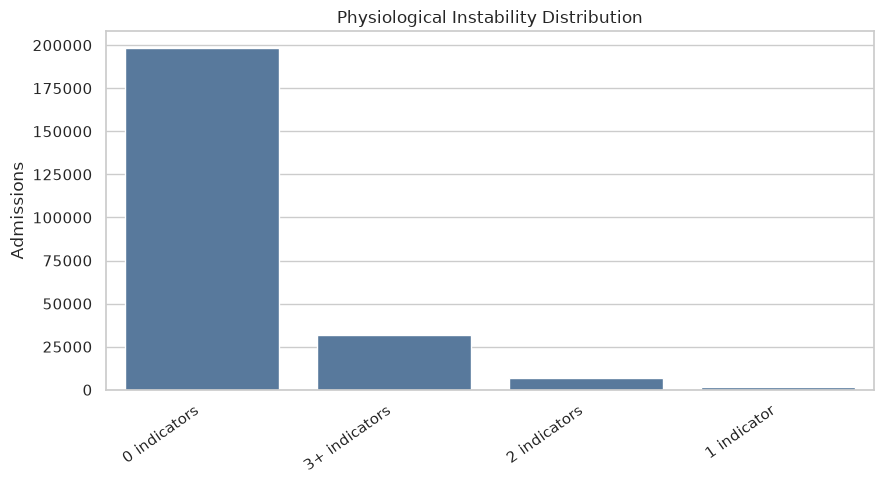

In [29]:
#table for physiological instability distribution
if "physiological_instability_category" in df.columns:
    physiological_instability_category_table = count_percent_table(df, "physiological_instability_category", top_n=12)
    print("Physiological Instability Distribution:")
    display(physiological_instability_category_table)
    save_table(physiological_instability_category_table, "t2_4_physiological_instability_distribution")

    #plot physiological instability distribution
    plot_count_bar(physiological_instability_category_table, display_name("physiological_instability_category"), "Physiological Instability Distribution")


ICU Type Distribution:


,ICU Type,Admissions,Percent
0,No ICU,198005,83.02
1,Surgical/Trauma ICU,17103,7.17
2,Medical ICU,10676,4.48
3,Cardiac ICU,8946,3.75
4,Neuro ICU,3628,1.52
5,Other ICU,133,0.06


Added table to workbook sheet: t2_4_icu_type_distribution


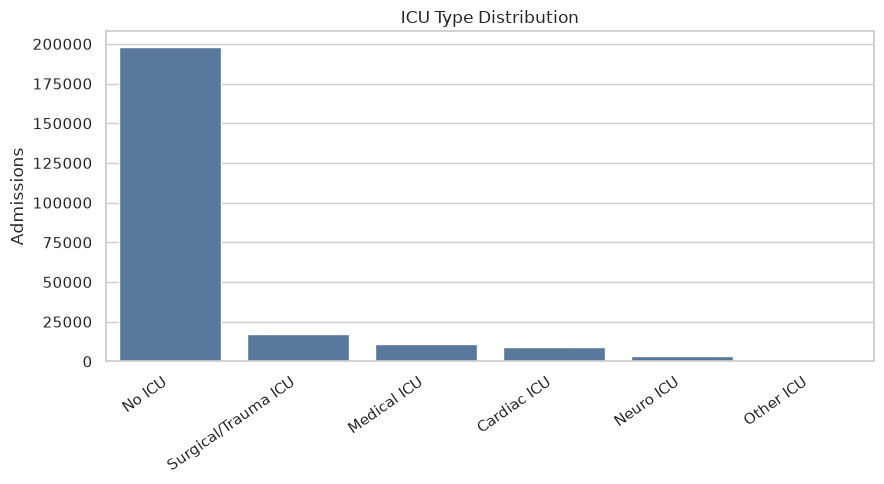

In [30]:
#table for icu type distribution
if "icu_type" in df.columns:
    icu_type_table = count_percent_table(df, "icu_type", top_n=12)
    print("ICU Type Distribution:")
    display(icu_type_table)
    save_table(icu_type_table, "t2_4_icu_type_distribution")

    #plot icu type distribution
    plot_count_bar(icu_type_table, display_name("icu_type"), "ICU Type Distribution")


ICU Utilisation Distribution:


,ICU Utilisation,Admissions,Percent
0,No ICU,198005,83.02
1,Single ICU stay,36499,15.30
2,Multiple ICU stays,3987,1.67


Added table to workbook sheet: t2_4_icu_utilisation_distributi


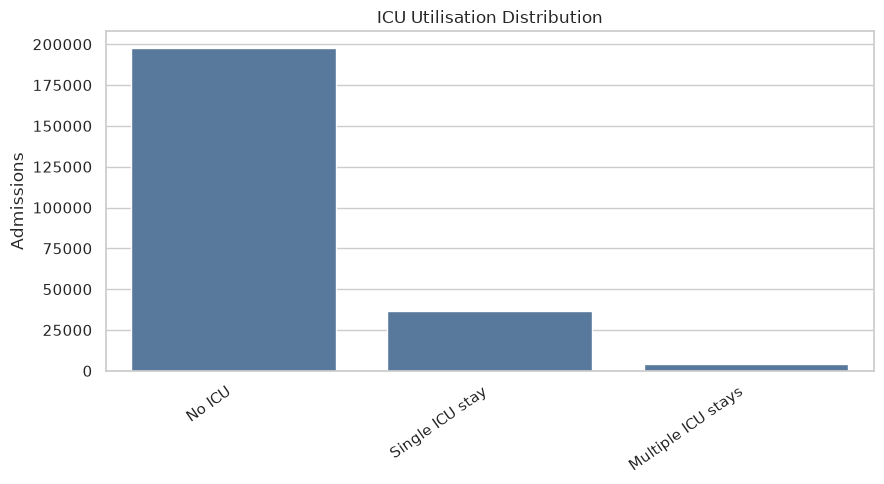

In [31]:
#table for icu utilisation distribution
if "icu_utilisation_category" in df.columns:
    icu_utilisation_category_table = count_percent_table(df, "icu_utilisation_category", top_n=12)
    print("ICU Utilisation Distribution:")
    display(icu_utilisation_category_table)
    save_table(icu_utilisation_category_table, "t2_4_icu_utilisation_distribution")

    #plot icu utilisation distribution
    plot_count_bar(icu_utilisation_category_table, display_name("icu_utilisation_category"), "ICU Utilisation Distribution")


#### **T2.4.4 - Readmission patterns across key groups**

Observed readmission rates were summarised across clinically relevant groups. These analyses are descriptive and are used to identify patterns that may be important during model development.

Readmission by Previous Psychiatric Admission:


,Previous Psychiatric Admission,Admissions,Readmissions,Readmission Rate (%)
1,1,130565,33149,25.39
0,0,107926,14209,13.17


Added table to workbook sheet: t2_4_readmission_by_previous_ps


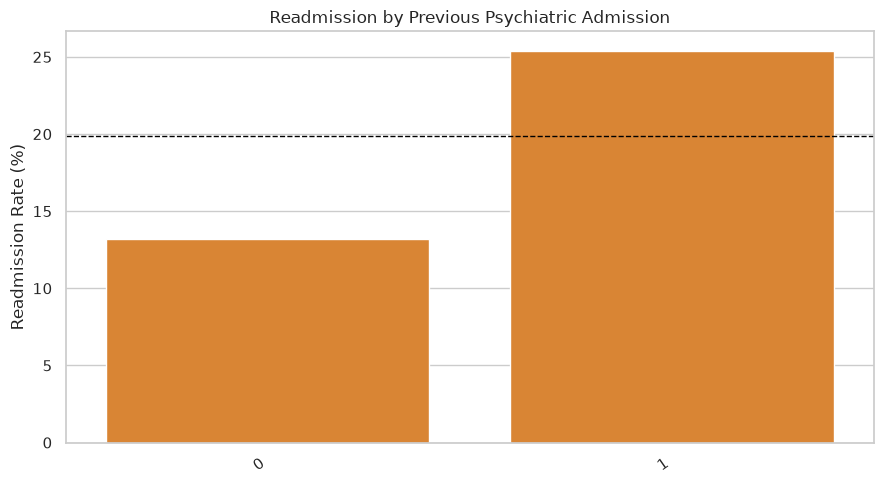

In [32]:
#build readmission summary tables for later use
readmission_summary_tables = {}

#table for readmission by previous psychiatric admission
if "has_previous_psych_admission" in df.columns:
    has_previous_psych_admission_readmission_table = readmission_summary(df, "has_previous_psych_admission")
    readmission_summary_tables["has_previous_psych_admission"] = has_previous_psych_admission_readmission_table
    print("Readmission by Previous Psychiatric Admission:")
    display(has_previous_psych_admission_readmission_table)
    save_table(has_previous_psych_admission_readmission_table, "t2_4_readmission_by_previous_psychiatric_admission")

    #plot readmission by previous psychiatric admission
    plot_rate_bar(readmission_summary_tables["has_previous_psych_admission"], display_name("has_previous_psych_admission"), "Readmission by Previous Psychiatric Admission")


Readmission by Previous Psychiatric Admission Recency:


,Time Since Previous Psychiatric Admission,Admissions,Readmissions,Readmission Rate (%)
0,0-30 days,47674,16025,33.61
2,31-90 days,23135,6452,27.89
4,91-180 days,14902,3375,22.65
1,181-365 days,14815,2739,18.49
3,365+ days,30039,4558,15.17
5,No previous psychiatric admission,107926,14209,13.17


Added table to workbook sheet: t2_4_readmission_by_previous__2


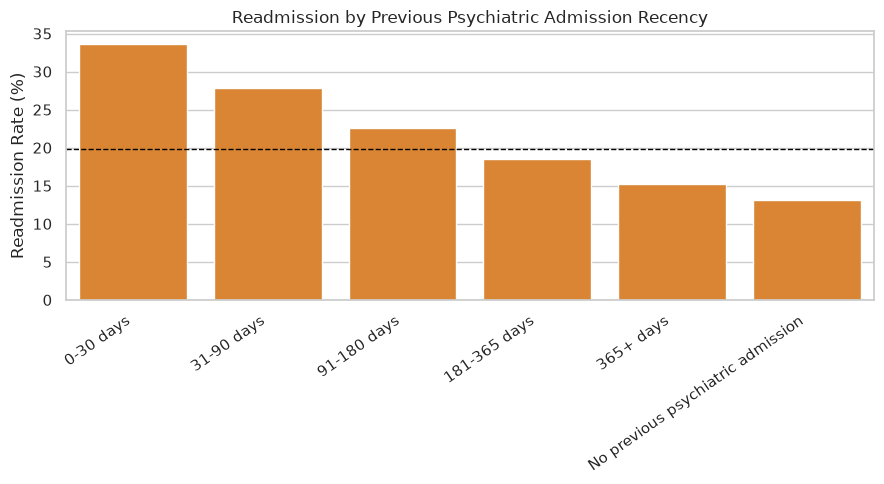

In [33]:
#table for readmission by previous psychiatric admission recency
if "time_since_previous_psych_category" in df.columns:
    time_since_previous_psych_category_readmission_table = readmission_summary(df, "time_since_previous_psych_category")
    readmission_summary_tables["time_since_previous_psych_category"] = time_since_previous_psych_category_readmission_table
    print("Readmission by Previous Psychiatric Admission Recency:")
    display(time_since_previous_psych_category_readmission_table)
    save_table(time_since_previous_psych_category_readmission_table, "t2_4_readmission_by_previous_psychiatric_admission_recency")

    #plot readmission by previous psychiatric admission recency
    plot_rate_bar(readmission_summary_tables["time_since_previous_psych_category"], display_name("time_since_previous_psych_category"), "Readmission by Previous Psychiatric Admission Recency")


Readmission by Age Group:


,Age Group,Admissions,Readmissions,Readmission Rate (%)
2,40-49,36256,8608,23.74
1,30-39,25907,6013,23.21
3,50-59,48511,10756,22.17
0,18-29,30700,6650,21.66
4,60-69,42536,7859,18.48
5,70-79,28381,4229,14.90
6,80+,26200,3243,12.38


Added table to workbook sheet: t2_4_readmission_by_age_group


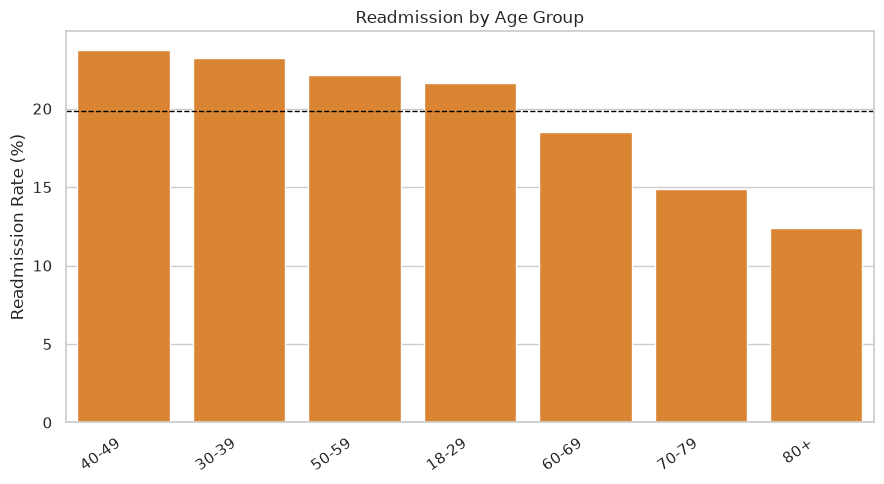

In [34]:
#table for readmission by age group
if "age_group" in df.columns:
    age_group_readmission_table = readmission_summary(df, "age_group")
    readmission_summary_tables["age_group"] = age_group_readmission_table
    print("Readmission by Age Group:")
    display(age_group_readmission_table)
    save_table(age_group_readmission_table, "t2_4_readmission_by_age_group")

    #plot readmission by age group
    plot_rate_bar(readmission_summary_tables["age_group"], display_name("age_group"), "Readmission by Age Group")


Readmission by Night Admission:


,Night Admission,Admissions,Readmissions,Readmission Rate (%)
0,0,149384,29870,20.00
1,1,89107,17488,19.63


Added table to workbook sheet: t2_4_readmission_by_night_admis


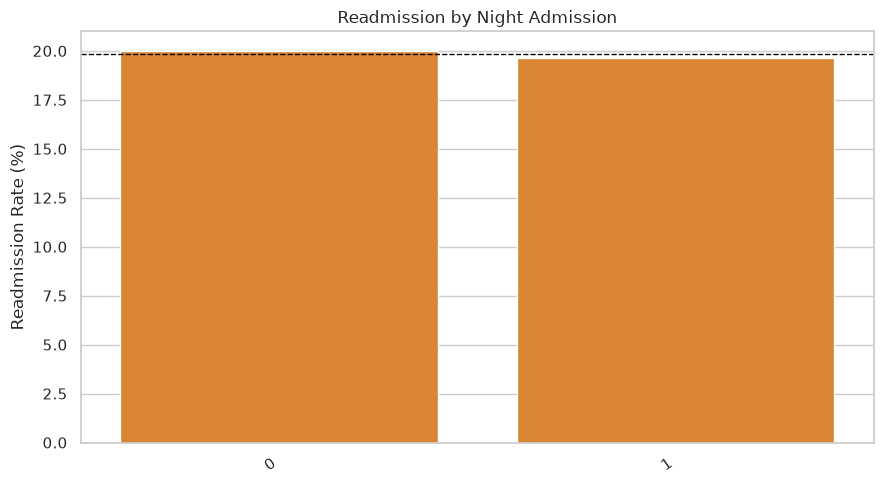

In [35]:
#table for readmission by night admission
if "night_admission" in df.columns:
    night_admission_readmission_table = readmission_summary(df, "night_admission")
    readmission_summary_tables["night_admission"] = night_admission_readmission_table
    print("Readmission by Night Admission:")
    display(night_admission_readmission_table)
    save_table(night_admission_readmission_table, "t2_4_readmission_by_night_admission")

    #plot readmission by night admission
    plot_rate_bar(readmission_summary_tables["night_admission"], display_name("night_admission"), "Readmission by Night Admission")


Readmission by Weekend Admission:


,Weekend Admission,Admissions,Readmissions,Readmission Rate (%)
1,1,69020,13879,20.11
0,0,169471,33479,19.76


Added table to workbook sheet: t2_4_readmission_by_weekend_adm


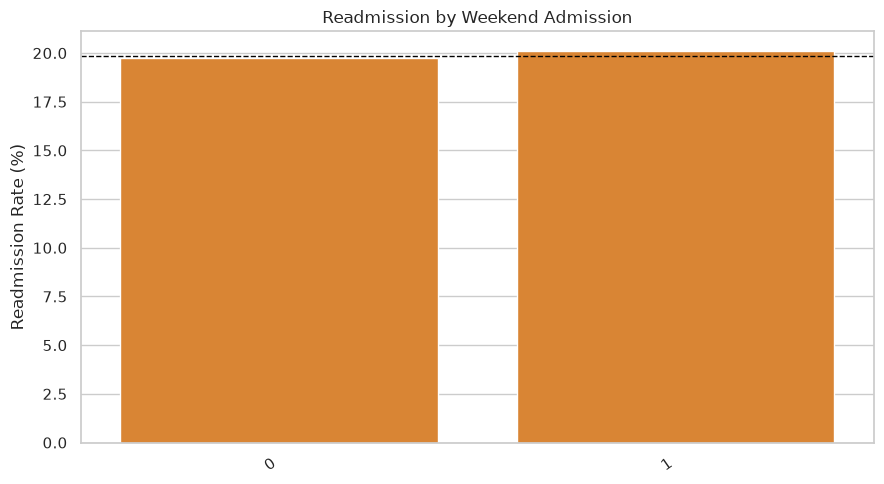

In [36]:
#table for readmission by weekend admission
if "weekend_admission" in df.columns:
    weekend_admission_readmission_table = readmission_summary(df, "weekend_admission")
    readmission_summary_tables["weekend_admission"] = weekend_admission_readmission_table
    print("Readmission by Weekend Admission:")
    display(weekend_admission_readmission_table)
    save_table(weekend_admission_readmission_table, "t2_4_readmission_by_weekend_admission")

    #plot readmission by weekend admission
    plot_rate_bar(readmission_summary_tables["weekend_admission"], display_name("weekend_admission"), "Readmission by Weekend Admission")


Readmission by Discharge Destination:


,Discharge Destination,Admissions,Readmissions,Readmission Rate (%)
4,Psych facility,2933,1516,51.69
3,Other,5568,1661,29.83
5,Unknown / not modelled,77769,17895,23.01
2,Home health care,41194,8499,20.63
0,Facility / rehab / long-term care,38534,6236,16.18
1,Home,72493,11551,15.93


Added table to workbook sheet: t2_4_readmission_by_discharge_d


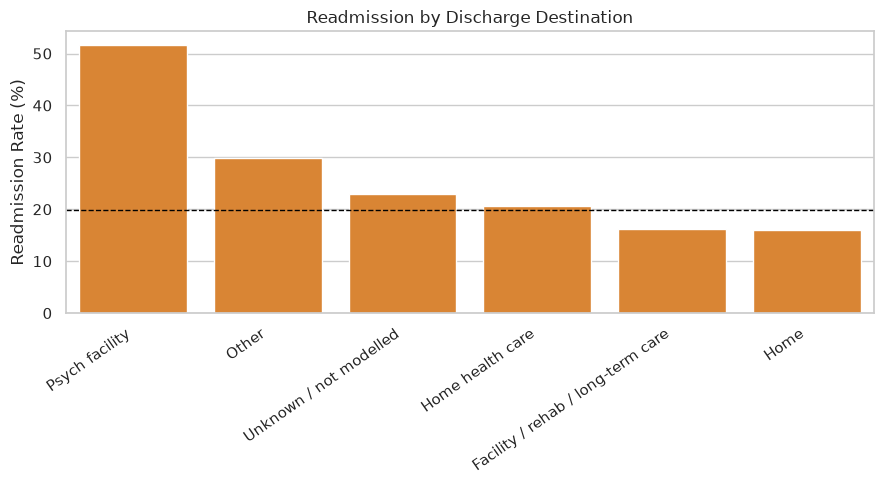

In [37]:
#table for readmission by discharge destination
if "discharge_location_grouped" in df.columns:
    discharge_location_grouped_readmission_table = readmission_summary(df, "discharge_location_grouped")
    readmission_summary_tables["discharge_location_grouped"] = discharge_location_grouped_readmission_table
    print("Readmission by Discharge Destination:")
    display(discharge_location_grouped_readmission_table)
    save_table(discharge_location_grouped_readmission_table, "t2_4_readmission_by_discharge_destination")

    #plot readmission by discharge destination
    plot_rate_bar(readmission_summary_tables["discharge_location_grouped"], display_name("discharge_location_grouped"), "Readmission by Discharge Destination")


Readmission by Admission Source:


,Admission Source,Admissions,Readmissions,Readmission Rate (%)
0,Emergency room,113811,24714,21.71
2,Other,24519,5089,20.76
3,Physician / clinic referral,63572,12114,19.06
5,Transfer from skilled nursing facility,3830,686,17.91
1,Internal transfer involving psych,5825,1013,17.39
6,Unknown,213,32,15.02
4,Transfer from hospital,26721,3710,13.88


Added table to workbook sheet: t2_4_readmission_by_admission_s


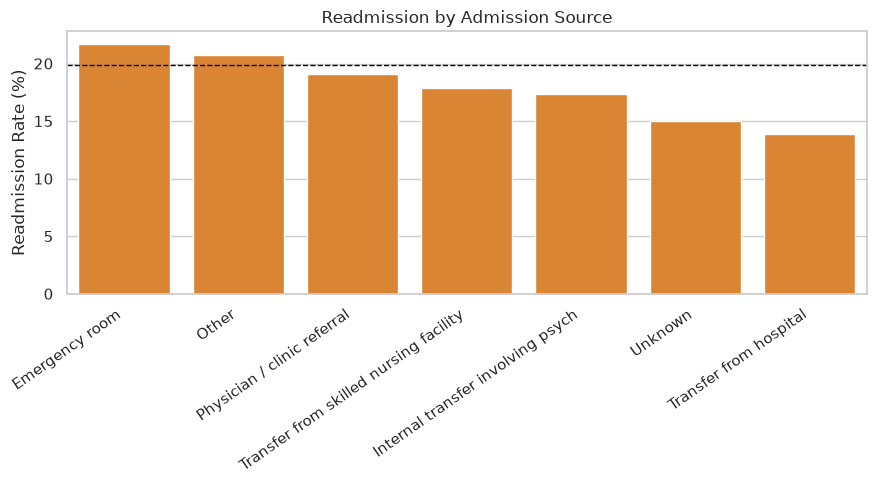

In [38]:
#table for readmission by admission source
if "admission_location_grouped" in df.columns:
    admission_location_grouped_readmission_table = readmission_summary(df, "admission_location_grouped")
    readmission_summary_tables["admission_location_grouped"] = admission_location_grouped_readmission_table
    print("Readmission by Admission Source:")
    display(admission_location_grouped_readmission_table)
    save_table(admission_location_grouped_readmission_table, "t2_4_readmission_by_admission_source")

    #plot readmission by admission source
    plot_rate_bar(readmission_summary_tables["admission_location_grouped"], display_name("admission_location_grouped"), "Readmission by Admission Source")


Readmission by DRG Severity:


,DRG Severity,Admissions,Readmissions,Readmission Rate (%)
4,No DRG record,79838,19724,24.71
1,Major,57893,11851,20.47
0,Extreme,26154,4632,17.71
3,Moderate,53318,8705,16.33
2,Minor,21288,2446,11.49


Added table to workbook sheet: t2_4_readmission_by_drg_severit


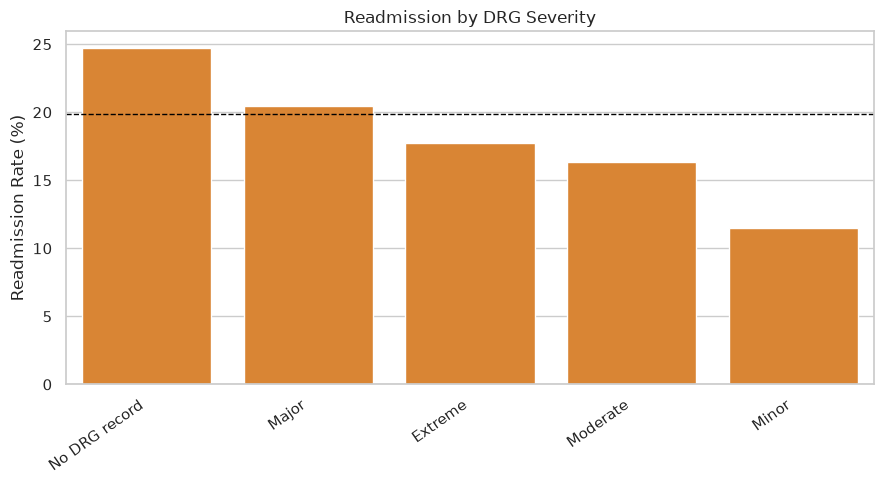

In [39]:
#table for readmission by drg severity
if "drg_severity_category" in df.columns:
    drg_severity_category_readmission_table = readmission_summary(df, "drg_severity_category")
    readmission_summary_tables["drg_severity_category"] = drg_severity_category_readmission_table
    print("Readmission by DRG Severity:")
    display(drg_severity_category_readmission_table)
    save_table(drg_severity_category_readmission_table, "t2_4_readmission_by_drg_severity")

    #plot readmission by drg severity
    plot_rate_bar(readmission_summary_tables["drg_severity_category"], display_name("drg_severity_category"), "Readmission by DRG Severity")


Readmission by DRG Mortality Risk:


,DRG Mortality Risk,Admissions,Readmissions,Readmission Rate (%)
4,No DRG record,79838,19724,24.71
3,Moderate,44944,8954,19.92
1,Major,38870,7725,19.87
0,Extreme,20699,3109,15.02
2,Minor,54140,7846,14.49


Added table to workbook sheet: t2_4_readmission_by_drg_mortali


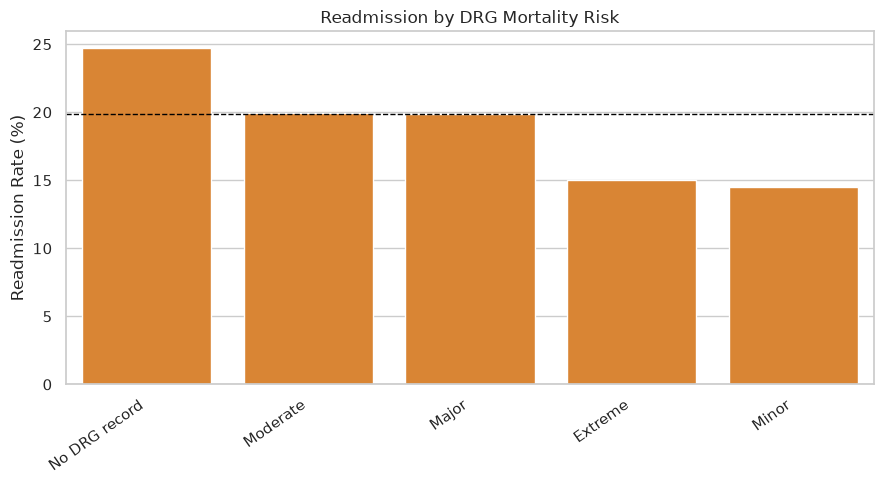

In [40]:
#table for readmission by drg mortality risk
if "drg_mortality_category" in df.columns:
    drg_mortality_category_readmission_table = readmission_summary(df, "drg_mortality_category")
    readmission_summary_tables["drg_mortality_category"] = drg_mortality_category_readmission_table
    print("Readmission by DRG Mortality Risk:")
    display(drg_mortality_category_readmission_table)
    save_table(drg_mortality_category_readmission_table, "t2_4_readmission_by_drg_mortality_risk")

    #plot readmission by drg mortality risk
    plot_rate_bar(readmission_summary_tables["drg_mortality_category"], display_name("drg_mortality_category"), "Readmission by DRG Mortality Risk")


Readmission by Service Transfer Count:


,Service Transfer Count,Admissions,Readmissions,Readmission Rate (%)
0,0 transfers,221640,44585,20.12
2,2+ transfers,3205,562,17.54
1,1 transfer,13646,2211,16.20


Added table to workbook sheet: t2_4_readmission_by_service_tra


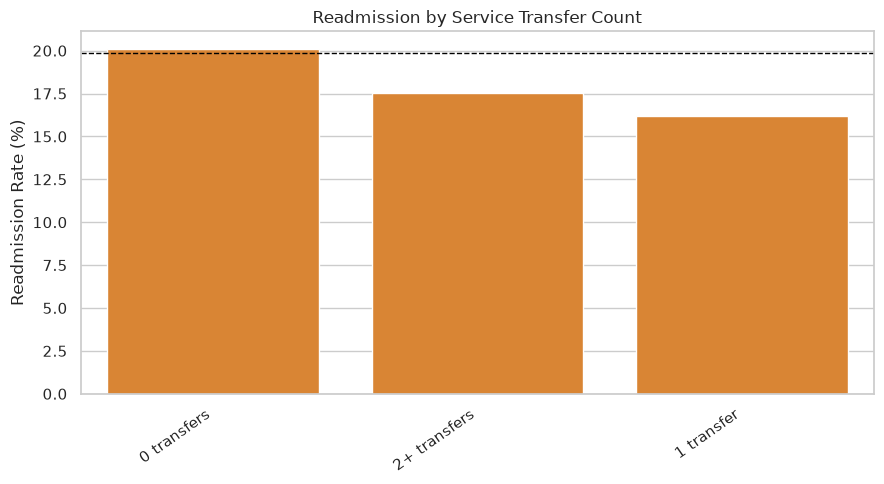

In [41]:
#table for readmission by service transfer count
if "service_transfer_category" in df.columns:
    service_transfer_category_readmission_table = readmission_summary(df, "service_transfer_category")
    readmission_summary_tables["service_transfer_category"] = service_transfer_category_readmission_table
    print("Readmission by Service Transfer Count:")
    display(service_transfer_category_readmission_table)
    save_table(service_transfer_category_readmission_table, "t2_4_readmission_by_service_transfer_count")

    #plot readmission by service transfer count
    plot_rate_bar(readmission_summary_tables["service_transfer_category"], display_name("service_transfer_category"), "Readmission by Service Transfer Count")


Readmission by Physical Transfer Events:


,Physical Transfer Category,Admissions,Readmissions,Readmission Rate (%)
0,0-2 transfer events,22649,4633,20.46
1,3-4 transfer events,166309,33963,20.42
2,5+ transfer events,49533,8762,17.69


Added table to workbook sheet: t2_4_readmission_by_physical_tr


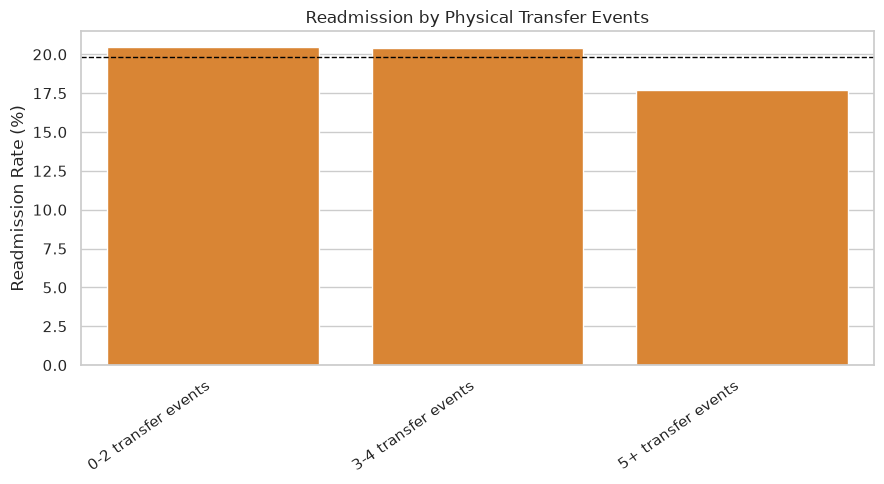

Readmission by Procedure Burden:


,Procedure Burden Category,Admissions,Readmissions,Readmission Rate (%)
0,0 procedures,129332,28142,21.76
1,1-2 procedures,62966,11612,18.44
2,3+ procedures,46193,7604,16.46


Added table to workbook sheet: t2_4_readmission_by_procedure_b


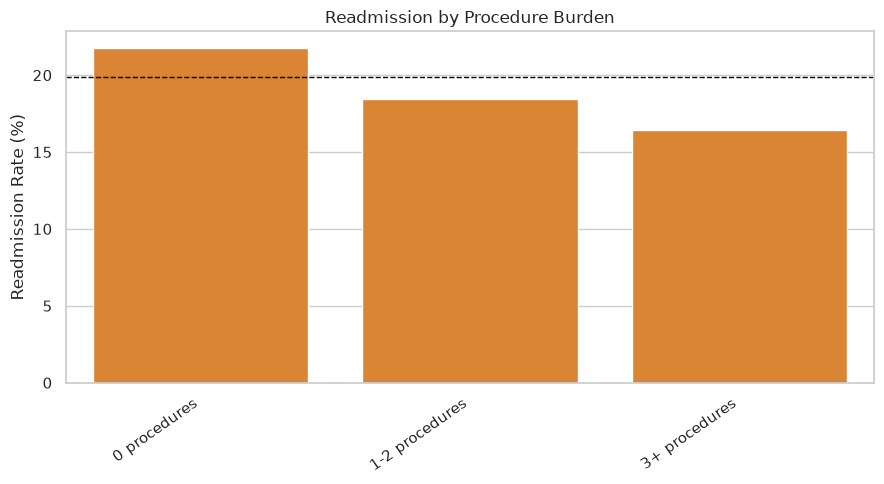

In [42]:
#tables for readmission by physical transfer and procedure burden
if "physical_transfer_category" in df.columns:
    physical_transfer_category_readmission_table = readmission_summary(df, "physical_transfer_category")
    readmission_summary_tables["physical_transfer_category"] = physical_transfer_category_readmission_table
    print("Readmission by Physical Transfer Events:")
    display(physical_transfer_category_readmission_table)
    save_table(physical_transfer_category_readmission_table, "t2_4_readmission_by_physical_transfer_events")

    #plot readmission by physical transfer events
    plot_rate_bar(readmission_summary_tables["physical_transfer_category"], display_name("physical_transfer_category"), "Readmission by Physical Transfer Events")

if "procedure_burden_category" in df.columns:
    procedure_burden_category_readmission_table = readmission_summary(df, "procedure_burden_category")
    readmission_summary_tables["procedure_burden_category"] = procedure_burden_category_readmission_table
    print("Readmission by Procedure Burden:")
    display(procedure_burden_category_readmission_table)
    save_table(procedure_burden_category_readmission_table, "t2_4_readmission_by_procedure_burden")

    #plot readmission by procedure burden
    plot_rate_bar(readmission_summary_tables["procedure_burden_category"], display_name("procedure_burden_category"), "Readmission by Procedure Burden")


Readmission by Psychiatric Diagnosis Burden:


,Psychiatric Diagnosis Burden,Admissions,Readmissions,Readmission Rate (%)
3,5+ diagnoses,8376,2416,28.84
2,3-4 diagnoses,36590,9285,25.38
1,2 diagnoses,61393,13014,21.20
0,1 diagnosis,132132,22643,17.14


Added table to workbook sheet: t2_4_readmission_by_psychiatric


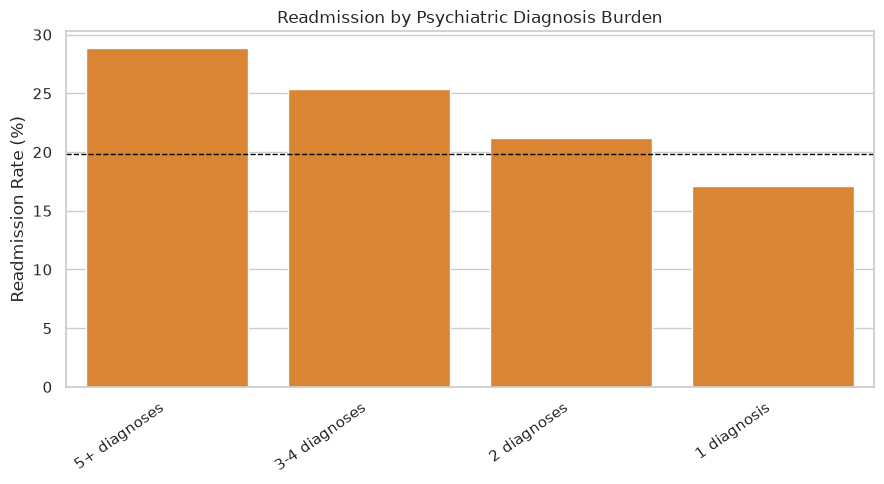

In [43]:
#table for readmission by psychiatric diagnosis burden
if "psych_diagnosis_burden_category" in df.columns:
    psych_diagnosis_burden_category_readmission_table = readmission_summary(df, "psych_diagnosis_burden_category")
    readmission_summary_tables["psych_diagnosis_burden_category"] = psych_diagnosis_burden_category_readmission_table
    print("Readmission by Psychiatric Diagnosis Burden:")
    display(psych_diagnosis_burden_category_readmission_table)
    save_table(psych_diagnosis_burden_category_readmission_table, "t2_4_readmission_by_psychiatric_diagnosis_burden")

    #plot readmission by psychiatric diagnosis burden
    plot_rate_bar(readmission_summary_tables["psych_diagnosis_burden_category"], display_name("psych_diagnosis_burden_category"), "Readmission by Psychiatric Diagnosis Burden")


Readmission by Psychiatric Medication Burden:


,Psychiatric Medication Burden,Admissions,Readmissions,Readmission Rate (%)
0,0 classes,79739,18038,22.62
3,3+ classes,38385,8518,22.19
2,2 classes,55982,10698,19.11
1,1 class,64385,10104,15.69


Added table to workbook sheet: t2_4_readmission_by_psychiatr_2


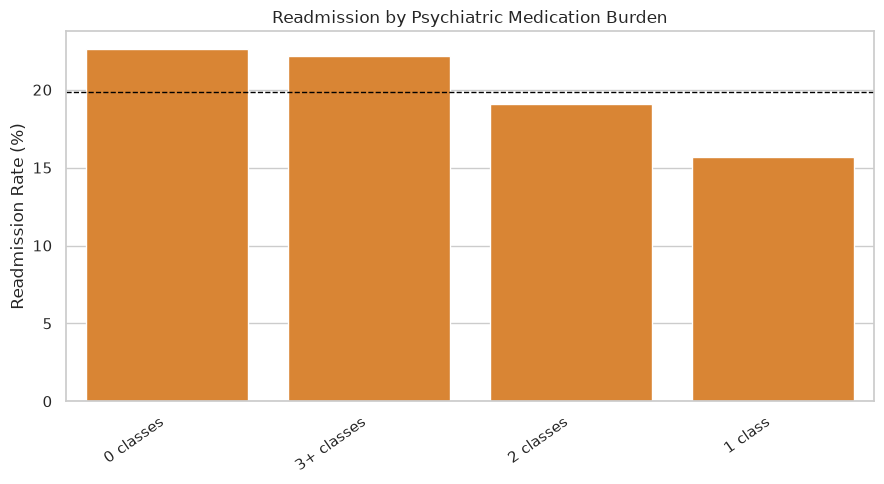

In [44]:
#table for readmission by psychiatric medication burden
if "psych_medication_burden_category" in df.columns:
    psych_medication_burden_category_readmission_table = readmission_summary(df, "psych_medication_burden_category")
    readmission_summary_tables["psych_medication_burden_category"] = psych_medication_burden_category_readmission_table
    print("Readmission by Psychiatric Medication Burden:")
    display(psych_medication_burden_category_readmission_table)
    save_table(psych_medication_burden_category_readmission_table, "t2_4_readmission_by_psychiatric_medication_burden")

    #plot readmission by psychiatric medication burden
    plot_rate_bar(readmission_summary_tables["psych_medication_burden_category"], display_name("psych_medication_burden_category"), "Readmission by Psychiatric Medication Burden")


Readmission by Laboratory Abnormality Burden:


,Laboratory Abnormality Burden,Admissions,Readmissions,Readmission Rate (%)
0,0 abnormal labs,68017,16468,24.21
3,3+ abnormal labs,124326,23855,19.19
2,2 abnormal labs,26886,4264,15.86
1,1 abnormal lab,19262,2771,14.39


Added table to workbook sheet: t2_4_readmission_by_laboratory_


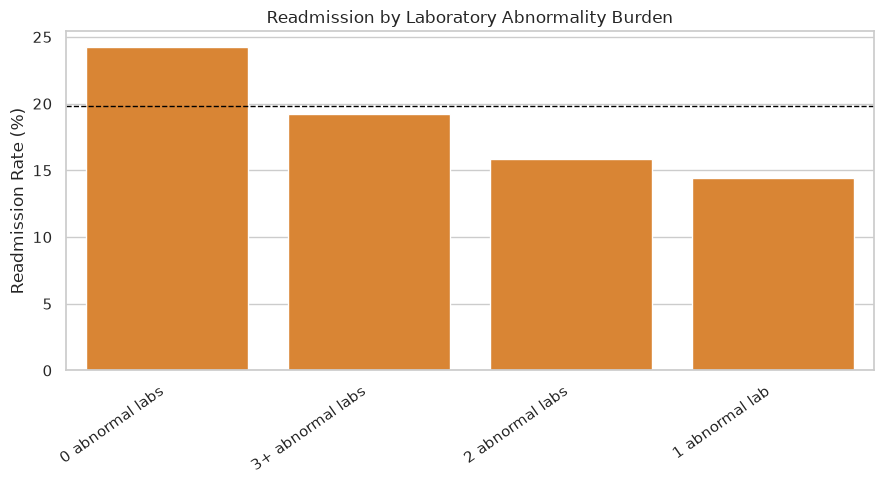

In [45]:
#table for readmission by laboratory abnormality burden
if "lab_abnormal_burden_category" in df.columns:
    lab_abnormal_burden_category_readmission_table = readmission_summary(df, "lab_abnormal_burden_category")
    readmission_summary_tables["lab_abnormal_burden_category"] = lab_abnormal_burden_category_readmission_table
    print("Readmission by Laboratory Abnormality Burden:")
    display(lab_abnormal_burden_category_readmission_table)
    save_table(lab_abnormal_burden_category_readmission_table, "t2_4_readmission_by_laboratory_abnormality_burden")

    #plot readmission by laboratory abnormality burden
    plot_rate_bar(readmission_summary_tables["lab_abnormal_burden_category"], display_name("lab_abnormal_burden_category"), "Readmission by Laboratory Abnormality Burden")


Readmission by Physiological Instability:


,Physiological Instability,Admissions,Readmissions,Readmission Rate (%)
0,0 indicators,198111,41401,20.90
3,3+ indicators,31782,4722,14.86
1,1 indicator,1658,239,14.41
2,2 indicators,6940,996,14.35


Added table to workbook sheet: t2_4_readmission_by_physiologic


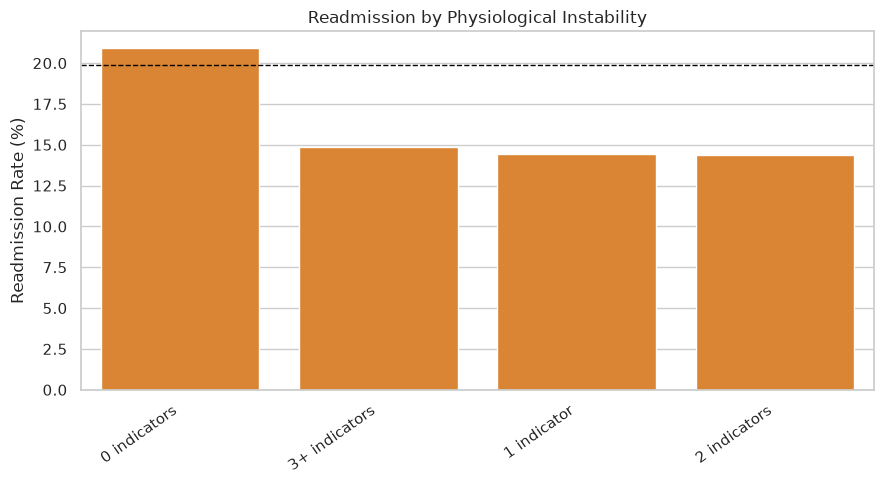

In [46]:
#table for readmission by physiological instability
if "physiological_instability_category" in df.columns:
    physiological_instability_category_readmission_table = readmission_summary(df, "physiological_instability_category")
    readmission_summary_tables["physiological_instability_category"] = physiological_instability_category_readmission_table
    print("Readmission by Physiological Instability:")
    display(physiological_instability_category_readmission_table)
    save_table(physiological_instability_category_readmission_table, "t2_4_readmission_by_physiological_instability")

    #plot readmission by physiological instability
    plot_rate_bar(readmission_summary_tables["physiological_instability_category"], display_name("physiological_instability_category"), "Readmission by Physiological Instability")


Readmission by ICU Type:


,ICU Type,Admissions,Readmissions,Readmission Rate (%)
3,No ICU,198005,41387,20.90
1,Medical ICU,10676,1846,17.29
5,Surgical/Trauma ICU,17103,2635,15.41
0,Cardiac ICU,8946,1145,12.80
2,Neuro ICU,3628,335,9.23
4,Other ICU,133,10,7.52


Added table to workbook sheet: t2_4_readmission_by_icu_type


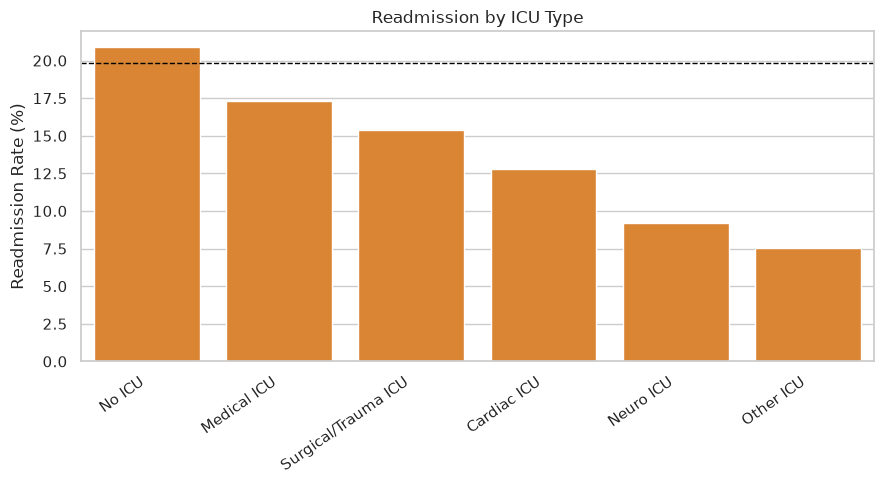

In [47]:
#table for readmission by icu type
if "icu_type" in df.columns:
    icu_type_readmission_table = readmission_summary(df, "icu_type")
    readmission_summary_tables["icu_type"] = icu_type_readmission_table
    print("Readmission by ICU Type:")
    display(icu_type_readmission_table)
    save_table(icu_type_readmission_table, "t2_4_readmission_by_icu_type")

    #plot readmission by icu type
    plot_rate_bar(readmission_summary_tables["icu_type"], display_name("icu_type"), "Readmission by ICU Type")


#### **T2.4.5 - Psychiatric diagnosis and medication class patterns**

Psychiatric diagnosis and medication class indicators were summarised to identify clinically interpretable subgroups with different observed readmission rates.

In [48]:
#diagnosis and medication class readmission summaries
diagnosis_flag_cols = ["has_depression", "has_bipolar_disorder", "has_psychotic_disorder", 
    "has_anxiety_ptsd", "has_substance_use", "has_cognitive_delirium", "has_personality_disorder",
    "has_eating_disorder", "has_neurodevelopmental_disorder", "has_other_psych_diagnosis"]
diagnosis_flag_cols = [col for col in diagnosis_flag_cols if col in df.columns]

medication_flag_cols = ["had_antidepressant", "had_antipsychotic", "had_mood_stabiliser",
    "had_benzodiazepine", "had_stimulant", "had_sedative_hypnotic"]
medication_flag_cols = [col for col in medication_flag_cols if col in df.columns]

#define binary feature summary
def binary_feature_summary(data, columns):
    rows = []
    for column in columns:
        exposed = data[data[column] == 1]
        rows.append({"Feature": display_name(column), "Admissions": len(exposed),
            "Percent of Cohort": round(len(exposed) / len(data) * 100, 2),
            "Readmission Rate (%)": round(exposed["readmitted_30d"].mean() * 100, 2)})
    return pd.DataFrame(rows).sort_values("Readmission Rate (%)", ascending=False)

diagnosis_summary = binary_feature_summary(df, diagnosis_flag_cols)
medication_summary = binary_feature_summary(df, medication_flag_cols)

print("Psychiatric diagnosis class summary:")
display(diagnosis_summary)
save_table(diagnosis_summary, "t2_4_psychiatric_diagnosis_class_summary")

print("Psychiatric medication class summary:")
display(medication_summary)
save_table(medication_summary, "t2_4_psychiatric_medication_class_summary")


Psychiatric diagnosis class summary:


,Feature,Admissions,Percent of Cohort,Readmission Rate (%)
6,Personality Disorder,5192,2.18,32.80
2,Psychotic Disorder,15437,6.47,31.55
7,Eating Disorder,1087,0.46,25.85
1,Bipolar Disorder,19353,8.11,25.84
9,Other Psychiatric Diagnosis,19130,8.02,22.84
0,Depression,96745,40.57,21.84
8,Neurodevelopmental Disorder,4648,1.95,21.43
4,Substance Use Disorder,100434,42.11,21.19
3,Anxiety or PTSD,75894,31.82,20.57
5,Cognitive Disorder or Delirium,31285,13.12,14.33


Added table to workbook sheet: t2_4_psychiatric_diagnosis_clas
Psychiatric medication class summary:


,Feature,Admissions,Percent of Cohort,Readmission Rate (%)
1,Antipsychotic,56445,23.67,21.09
4,Stimulant,3854,1.62,19.69
3,Benzodiazepine,94396,39.58,19.64
0,Antidepressant,100221,42.02,19.45
2,Mood Stabiliser,17531,7.35,18.94
5,Sedative or Hypnotic,29792,12.49,18.58


Added table to workbook sheet: t2_4_psychiatric_medication_cla


't2_4_psychiatric_medication_cla'

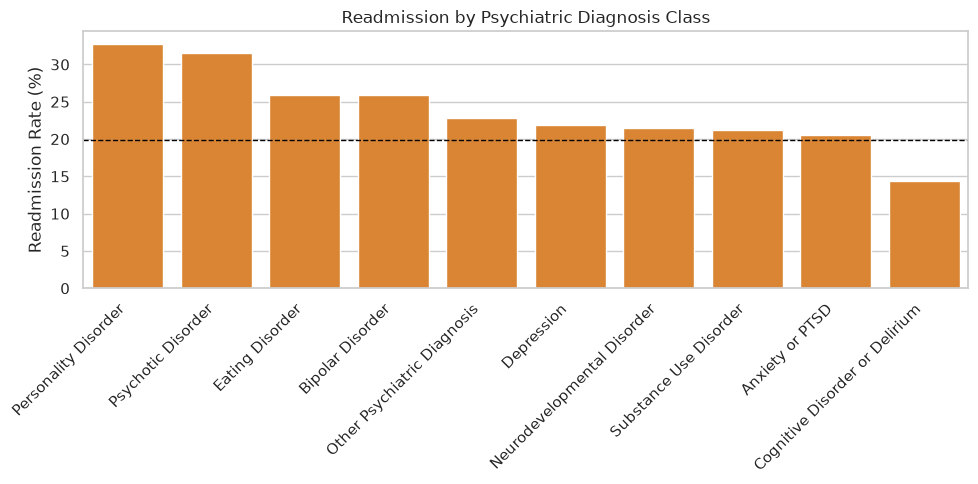

In [49]:
#plot readmission by psychiatric diagnosis class
plt.figure(figsize=(10, 5))
sns.barplot(data=diagnosis_summary, x="Feature", y="Readmission Rate (%)", color="#F58518")
plt.axhline(df["readmitted_30d"].mean() * 100, color="black", linestyle="--", linewidth=1)
plt.title("Readmission by Psychiatric Diagnosis Class")
plt.xlabel("")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


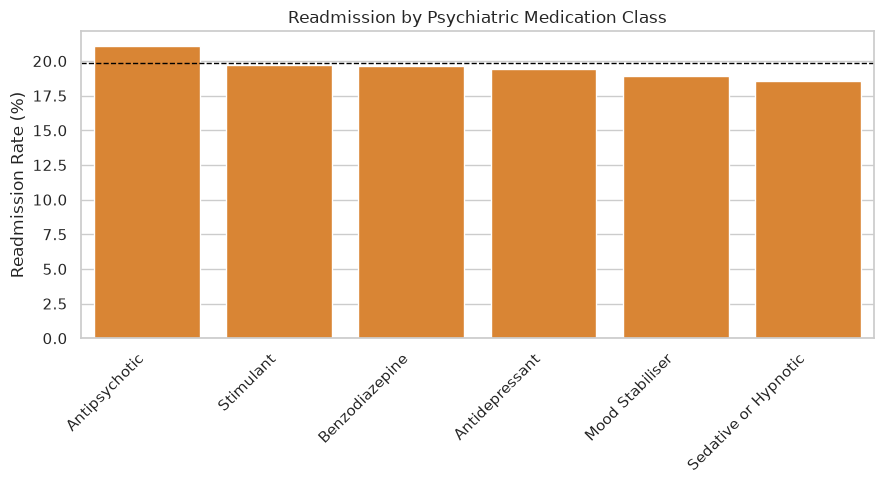

In [50]:
#plot readmission by psychiatric medication class
plt.figure(figsize=(9, 5))
sns.barplot(data=medication_summary, x="Feature", y="Readmission Rate (%)", color="#F58518")
plt.axhline(df["readmitted_30d"].mean() * 100, color="black", linestyle="--", linewidth=1)
plt.title("Readmission by Psychiatric Medication Class")
plt.xlabel("")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### **T2.4.6 - Continuous clinical feature summaries**

Selected continuous engineered features were summarised overall and by readmission outcome to describe differences in clinical burden and utilisation intensity.

In [51]:

#summary statistics for selected continuous features by outcome
#keep this curated so the eda is informative rather than a dump of all 600+ engineered variables
continuous_features = existing_columns([
    "anchor_age", "hospital_los_days", "admission_hour",
    "previous_psych_admissions", "previous_total_admissions", "previous_total_admissions_30d",
    "previous_total_admissions_90d", "previous_total_admissions_365d",
    "previous_nonpsych_admissions_30d", "previous_nonpsych_admissions_90d", "previous_nonpsych_admissions_365d",
    "days_since_previous_hospital_admission_filled", "previous_icu_admissions",
    "days_since_previous_icu_admission_filled", "previous_psych_to_total_admission_ratio",
    "charlson_comorbidity_index_simple", "elixhauser_group_count_simple",
    "psych_diagnosis_group_count", "num_nonpsych_diagnoses",
    "num_transfer_events", "num_unique_careunits", "num_procedures", "time_to_first_transfer_hours",
    "num_unique_drugs", "num_psych_med_classes", "administered_medication_count", "missed_dose_count",
    "iv_medication_administration_count", "microbiology_test_count", "distinct_organism_count",
    "num_labs_measured", "num_abnormal_labs", "physiological_instability_score", "total_icu_los_days",
    "ed_length_of_stay_hours", "ed_to_admission_hours", "ed_to_ward_delay_hours",
    "bmi", "weight_kg", "height_cm",
    "first_72h_abnormal_hour_percent", "first_72h_abnormal_hour_count", "first_72h_longest_abnormal_run_hours",
    "first_72h_hours_with_2plus_instability", "first_72h_hours_with_3plus_instability",
    "first_72h_max_instability_score", "first_72h_mean_instability_score",
    "heart_rate_72h_mean", "heart_rate_72h_max", "heart_rate_72h_std",
    "respiratory_rate_72h_mean", "respiratory_rate_72h_max", "spo2_72h_min",
    "spo2_72h_mean", "systolic_bp_noninvasive_72h_min", "mean_bp_noninvasive_72h_min"])

continuous_summary = (df.groupby("readmitted_30d")[continuous_features]
    .agg(["mean", "median", "std"]).round(2))

continuous_summary.index = continuous_summary.index.map(outcome_labels)
continuous_summary = continuous_summary.rename(columns=feature_display_names, level=0)
continuous_summary_for_csv = continuous_summary.copy()
continuous_summary_for_csv.columns = [f"{feature} - {stat}" for feature, stat in continuous_summary_for_csv.columns]
continuous_summary_for_csv = continuous_summary_for_csv.reset_index().rename(columns={"readmitted_30d": "Readmission Outcome"})

print("Continuous feature summary by readmission outcome:")
display(continuous_summary)
save_table(continuous_summary_for_csv, "t2_4_continuous_feature_summary_by_outcome")


Continuous feature summary by readmission outcome:


Age               Hospital Length of Stay              Admission Hour              Previous Psychiatric Admissions               Previous Hospital Admissions  \
                 mean median    std                    mean median   std           mean median   std                            mean median    std                         mean   
readmitted_30d                                                                                                                                                                    
Not Readmitted  55.14   56.0  19.15                    5.43   3.07  8.32          13.07   15.0  7.47                            2.48    1.0   6.37                         3.47   
Readmitted      51.31   52.0  17.64                    5.13   2.81  8.04          13.47   16.0  7.37                            7.58    2.0  16.85                         8.88   

                             Previous Hospital Admissions in 30 Days              Previous Hospital Admissions in 90 Days              Previous Hospital Admissions in 365 Days  \
               median    std                                    mean median   std                                    mean median   std                                     mean   
readmitted_30d                                                                                                                                                                    
Not Readmitted    1.0   7.52                                    0.24    0.0  0.55                                    0.49    0.0  0.97                                     1.18   
Readmitted        3.0  17.62                                    0.60    0.0  1.06                                    1.32    1.0  2.15                                     3.33   

                            Previous Non-Psychiatric Admissions in 30 Days              Previous Non-Psychiatric Admissions in 90 Days               \
               median   std                                           mean median   std                                           mean median   std   
readmitted_30d                                                                                                                                        
Not Readmitted    0.0  2.28                                           0.05    0.0  0.24                                           0.11    0.0  0.42   
Readmitted        1.0  5.68                                           0.06    0.0  0.26                                           0.14    0.0  0.50   

               Previous Non-Psychiatric Admissions in 365 Days              Days Since Previous Hospital Admission (Filled)                Previous ICU Admissions               \
                                                          mean median   std                                            mean median     std                    mean median   std   
readmitted_30d                                                                                                                                                                    
Not Readmitted                                            0.28    0.0  0.90                                          222.76   8.37  538.18                    0.37    0.0  1.18   
Readmitted                                                0.38    0.0  1.15                                          150.69  13.56  425.65                    0.73    0.0  2.00   

               Days Since Previous ICU Admission (Filled)                Psychiatric-to-Total Previous Admission Ratio              Psychiatric Diagnosis Groups               \
                                                     mean median     std                                          mean median   std                         mean median   std   
readmitted_30d                                                                                                                                                                  
Not Readmitted                             

Added table to workbook sheet: t2_4_continuous_feature_summary


't2_4_continuous_feature_summary'

In [52]:
#rank continuous variables by readmission/non-readmission separation instead of plotting one feature at a time
continuous_contrast_rows = []
for column in existing_columns(continuous_features):
    series = pd.to_numeric(df[column], errors="coerce")
    non_readmitted = series[df["readmitted_30d"] == 0].dropna()
    readmitted = series[df["readmitted_30d"] == 1].dropna()
    if non_readmitted.empty or readmitted.empty:
        continue
    pooled_std = series.std()
    median_difference = readmitted.median() - non_readmitted.median()
    mean_difference = readmitted.mean() - non_readmitted.mean()
    continuous_contrast_rows.append({"Feature": display_name(column),
        "Non-readmitted median": non_readmitted.median(),
        "Readmitted median": readmitted.median(),
        "Median difference": median_difference,
        "Non-readmitted mean": non_readmitted.mean(),
        "Readmitted mean": readmitted.mean(),
        "Mean difference": mean_difference,
        "Standardised mean difference": mean_difference / pooled_std if pooled_std and not pd.isna(pooled_std) else np.nan,
        "Missing percent": series.isna().mean() * 100,
        "Observed admissions": series.notna().sum(),})

continuous_contrast_df = pd.DataFrame(continuous_contrast_rows)
if not continuous_contrast_df.empty:
    continuous_contrast_df["Absolute standardised mean difference"] = continuous_contrast_df["Standardised mean difference"].abs()
    continuous_contrast_df = continuous_contrast_df.sort_values(
        ["Absolute standardised mean difference", "Observed admissions"], ascending=[False, False]).round(4)
    print("Continuous features with the largest readmission/non-readmission separation:")
    display(top_display(continuous_contrast_df))
    save_table(continuous_contrast_df, "t2_4_continuous_feature_outcome_contrast_ranked")
else:
    print("No continuous feature contrasts were available.")


Continuous features with the largest readmission/non-readmission separation:


,Feature,Non-readmitted median,Readmitted median,Median difference,Non-readmitted mean,Readmitted mean,Mean difference,Standardised mean difference,Missing percent,Observed admissions,Absolute standardised mean difference
7,Previous Hospital Admissions in 365 Days,0.0000,1.0000,1.0000,1.1757,3.3328,2.1571,0.6418,0.0000,238491,0.6418
6,Previous Hospital Admissions in 90 Days,0.0000,1.0000,1.0000,0.4857,1.3204,0.8347,0.6246,0.0000,238491,0.6246
3,Previous Psychiatric Admissions,1.0000,2.0000,1.0000,2.4770,7.5833,5.1063,0.5294,0.0000,238491,0.5294
4,Previous Hospital Admissions,1.0000,3.0000,2.0000,3.4728,8.8833,5.4105,0.5122,0.0000,238491,0.5122
5,Previous Hospital Admissions in 30 Days,0.0000,0.0000,0.0000,0.2397,0.5978,0.3580,0.5116,0.0000,238491,0.5116
14,Psychiatric-to-Total Previous Admission Ratio,0.1667,0.8125,0.6458,0.4168,0.5998,0.1830,0.4060,0.0000,238491,0.4060
12,Previous ICU Admissions,0.0000,0.0000,0.0000,0.3719,0.7281,0.3561,0.2562,0.0000,238491,0.2562
29,ED Length of Stay (Hours),7.9500,9.1583,1.2083,11.1817,13.9433,2.7616,0.2321,22.8524,183990,0.2321
15,Psychiatric Diagnosis Groups,1.0000,1.0000,0.0000,1.5145,1.6836,0.1690,0.2123,0.0000,238491,0.2123
0,Age,56.0000,52.0000,-4.0000,55.1436,51.3063,-3.8373,-0.2028,0.0000,238491,0.2028


Added table to workbook sheet: t2_4_continuous_feature_outcome


In [53]:
#summarise physiological instability score without a separate distribution plot
#most admissions have low scores, so the readmission-rate table is more informative than a boxplot
if "physiological_instability_score" in df.columns:
    physiology_score_table = (
        df.groupby("physiological_instability_score", observed=False)
        .agg(admissions=("readmitted_30d", "size"), readmission_rate=("readmitted_30d", "mean"))
        .reset_index()
    )
    physiology_score_table["readmission_rate_percent"] = (physiology_score_table["readmission_rate"] * 100).round(2)
    physiology_score_table = physiology_score_table.drop(columns="readmission_rate")
    physiology_score_table["Feature"] = "Physiological instability score"
    print("Readmission rate by physiological instability score:")
    display(physiology_score_table)
    save_table(physiology_score_table, "t2_4_physiological_instability_score_readmission_rate")
else:
    print("physiological_instability_score is not available in this dataset.")


Readmission rate by physiological instability score:


,physiological_instability_score,admissions,readmission_rate_percent,Feature
0,0,198111,20.90,Physiological instability score
1,1,1658,14.41,Physiological instability score
2,2,6940,14.35,Physiological instability score
3,3,11058,15.62,Physiological instability score
4,4,10735,15.48,Physiological instability score
5,5,9989,13.34,Physiological instability score


Added table to workbook sheet: t2_4_physiological_instabilit_2


#### **T2.4.7 - Laboratory, physiology, and ICU detail**

Laboratory abnormality, physiological instability, and ICU utilisation features were explored in more detail because these domains directly address clinical severity and dynamic physiological information highlighted during feature construction.

In [54]:

#summarise the highest-yield expanded clinical, utilisation, and physiology features
expanded_detail_features = existing_columns([
    "previous_total_admissions_30d", "previous_total_admissions_90d", "previous_total_admissions_365d",
    "previous_nonpsych_admissions_30d", "previous_nonpsych_admissions_90d", "previous_nonpsych_admissions_365d",
    "days_since_previous_hospital_admission_filled", "previous_icu_admissions", "days_since_previous_icu_admission_filled",
    "previous_psych_to_total_admission_ratio", "charlson_comorbidity_index_simple", "elixhauser_group_count_simple",
    "ed_length_of_stay_hours", "ed_to_admission_hours", "ed_to_ward_delay_hours",
    "microbiology_test_count", "distinct_organism_count", "administered_medication_count", "missed_dose_count",
    "iv_medication_administration_count", "bmi", "first_72h_abnormal_hour_percent", "first_72h_abnormal_hour_count",
    "first_72h_longest_abnormal_run_hours", "first_72h_hours_with_2plus_instability", "first_72h_hours_with_3plus_instability",
    "first_72h_max_instability_score", "first_72h_mean_instability_score"])

expanded_detail_summary = df[expanded_detail_features].describe().T.round(2)
expanded_detail_summary = expanded_detail_summary.rename(index=feature_display_names).reset_index().rename(columns={"index": "Feature"})

print("Expanded feature detail summary:")
display(expanded_detail_summary)
save_table(expanded_detail_summary, "t2_4_expanded_feature_detail_summary")
indicator_features = existing_columns(["has_previous_icu_admission", "high_utiliser_previous_year",
    "has_self_harm_or_suicidal_ideation", "has_alcohol_related_disorder", "has_opioid_related_disorder",
    "has_stimulant_related_disorder", "has_diabetes", "has_chronic_kidney_disease", "has_copd_or_asthma",
    "has_heart_failure", "has_liver_disease", "has_cancer", "has_dementia", "has_ed_timing",
    "positive_culture_flag", "blood_culture_positive", "urine_culture_positive", "respiratory_culture_positive",
    "suspected_infection_flag", "missed_dose_flag", "incomplete_dose_not_given_flag", "infusion_administration_flag",
    "had_antibiotic_exposure", "had_opioid_exposure", "had_steroid_exposure", "had_iv_prescription",
    "obesity_flag", "underweight_flag", "missing_bmi_flag", "medical_to_psych_transfer", "psych_to_medical_transfer",
    "same_service_admission_discharge", "has_first_72h_vital_burden_data", "recent_psych_admission_smi_interaction",
    "recent_psych_admission_substance_interaction", "smi_antipsychotic_interaction", "substance_benzodiazepine_interaction",
    "polypharmacy_age65_interaction", "icu_physiology_instability_interaction", "lab_abnormality_icu_interaction"])

indicator_summary = pd.DataFrame({"Feature": [display_name(col) for col in indicator_features],
    "Admissions": [int(pd.to_numeric(df[col], errors="coerce").fillna(0).sum()) for col in indicator_features],
    "Percent of Cohort": [round(pd.to_numeric(df[col], errors="coerce").fillna(0).mean() * 100, 2) for col in indicator_features]
}).sort_values("Admissions", ascending=False)

print("Expanded binary indicator prevalence:")
display(top_display(indicator_summary))
save_table(indicator_summary, "t2_4_expanded_binary_indicator_prevalence")


Expanded feature detail summary:


,Feature,count,mean,std,min,25%,50%,75%,max
0,Previous Hospital Admissions in 30 Days,238491.0,0.31,0.70,0.0,0.00,0.00,0.00,15.00
1,Previous Hospital Admissions in 90 Days,238491.0,0.65,1.34,0.0,0.00,0.00,1.00,31.00
2,Previous Hospital Admissions in 365 Days,238491.0,1.60,3.36,0.0,0.00,0.00,2.00,69.00
3,Previous Non-Psychiatric Admissions in 30 Days,238491.0,0.05,0.25,0.0,0.00,0.00,0.00,5.00
4,Previous Non-Psychiatric Admissions in 90 Days,238491.0,0.11,0.44,0.0,0.00,0.00,0.00,11.00
5,Previous Non-Psychiatric Admissions in 365 Days,238491.0,0.30,0.95,0.0,0.00,0.00,0.00,28.00
6,Days Since Previous Hospital Admission (Filled),238491.0,208.45,518.58,0.0,0.00,10.10,131.57,5295.48
7,Previous ICU Admissions,238491.0,0.44,1.39,0.0,0.00,0.00,0.00,41.00
8,Days Since Previous ICU Admission (Filled),238491.0,122.72,436.70,0.0,0.00,0.00,0.00,5112.11
9,Psychiatric-to-Total Previous Admission Ratio,238491.0,0.45,0.45,0.0,0.00,0.40,1.00,1.00


Added table to workbook sheet: t2_4_expanded_feature_detail_su
Expanded binary indicator prevalence:


,Feature,Admissions,Percent of Cohort
21,IV Prescription,185158,77.64
12,ED Timing Available,183991,77.15
19,Opioid Exposure,117701,49.35
24,Missing BMI,105237,44.13
18,Antibiotic Exposure,95719,40.14
17,Suspected Infection,63997,26.83
6,Diabetes,54993,23.06
22,Obesity,48858,20.49
0,Previous ICU Admission,48570,20.37
1,High Utiliser in Previous Year,45718,19.17


Added table to workbook sheet: t2_4_expanded_binary_indicator_


't2_4_expanded_binary_indicator_'

In [55]:
#individual laboratory marker abnormality associations with readmission
lab_marker_map = {"sodium": "Sodium", "potassium": "Potassium",
    "creatinine": "Creatinine", "urea_nitrogen": "Urea Nitrogen",
    "glucose": "Glucose", "hemoglobin": "Haemoglobin",
    "platelet": "Platelets", "wbc": "White Blood Cell Count"}

lab_marker_rows = []
for marker, marker_label in lab_marker_map.items():
    abnormal_col = f"{marker}_lab_abnormal"
    measured_col = f"{marker}_lab_measured"
    if abnormal_col not in df.columns or measured_col not in df.columns:
        continue

    measured_data = df[df[measured_col] == 1].copy()
    abnormal_data = measured_data[measured_data[abnormal_col] == 1]
    not_abnormal_data = measured_data[measured_data[abnormal_col] == 0]

    if len(measured_data) == 0:
        continue

    lab_marker_rows.append({"Laboratory Marker": marker_label, "Measured Admissions": len(measured_data),
        "Abnormal Admissions": len(abnormal_data),
        "Abnormal Among Measured (%)": round(len(abnormal_data) / len(measured_data) * 100, 2),
        "Readmission Rate if Abnormal (%)": round(abnormal_data["readmitted_30d"].mean() * 100, 2) if len(abnormal_data) else np.nan,
        "Readmission Rate if Not Abnormal (%)": round(not_abnormal_data["readmitted_30d"].mean() * 100, 2) if len(not_abnormal_data) else np.nan,
        "Rate Difference (%)": round((abnormal_data["readmitted_30d"].mean() - not_abnormal_data["readmitted_30d"].mean()) * 100, 2) if len(abnormal_data) and len(not_abnormal_data) else np.nan})

lab_marker_association_summary = pd.DataFrame(lab_marker_rows).sort_values("Rate Difference (%)", ascending=False)
print("Individual laboratory marker abnormality associations with readmission:")
display(lab_marker_association_summary)
save_table(lab_marker_association_summary, "t2_4_individual_laboratory_marker_readmission_associations")


Individual laboratory marker abnormality associations with readmission:


,Laboratory Marker,Measured Admissions,Abnormal Admissions,Abnormal Among Measured (%),Readmission Rate if Abnormal (%),Readmission Rate if Not Abnormal (%),Rate Difference (%)
5,Haemoglobin,174403,142713,81.83,18.93,13.22,5.72
6,Platelets,174589,66689,38.20,19.82,16.69,3.13
4,Glucose,172325,139509,80.96,18.58,16.21,2.37
0,Sodium,173170,45448,26.24,19.80,17.50,2.31
1,Potassium,173546,46742,26.93,19.54,17.55,1.99
3,Urea Nitrogen,173485,89069,51.34,18.92,17.19,1.72
7,White Blood Cell Count,174142,90233,51.82,18.71,17.05,1.67
2,Creatinine,174439,57681,33.07,18.96,17.57,1.39


Added table to workbook sheet: t2_4_individual_laboratory_mark


't2_4_individual_laboratory_mark'

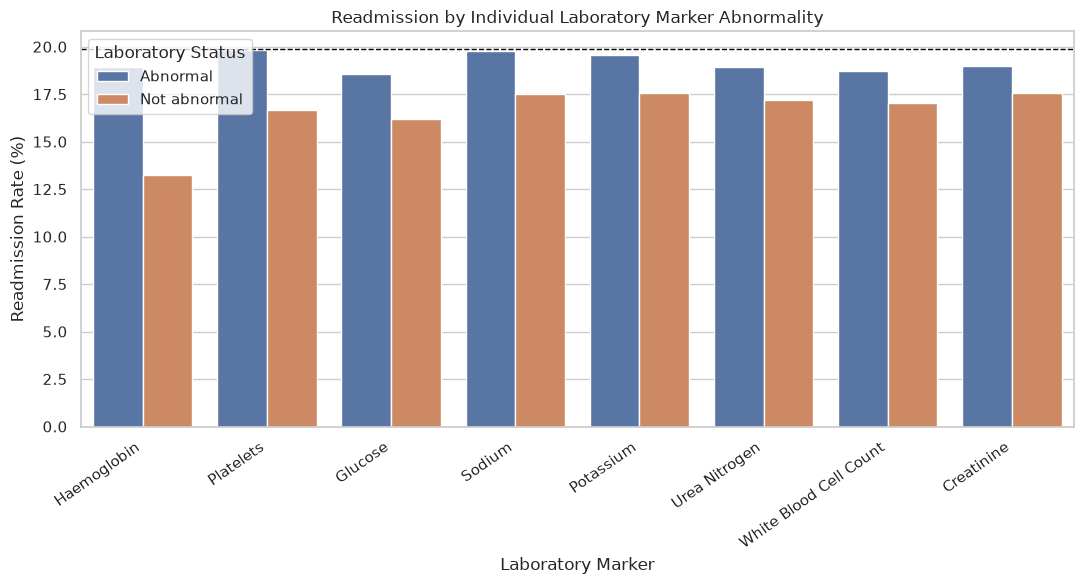

In [56]:
#plot individual laboratory marker abnormality associations with readmission
if len(lab_marker_association_summary):
    lab_marker_plot = lab_marker_association_summary.melt(
        id_vars="Laboratory Marker",
        value_vars=["Readmission Rate if Abnormal (%)", "Readmission Rate if Not Abnormal (%)"],
        var_name="Laboratory Status",
        value_name="Readmission Rate (%)")
    
    lab_marker_plot["Laboratory Status"] = lab_marker_plot["Laboratory Status"].replace({
        "Readmission Rate if Abnormal (%)": "Abnormal",
        "Readmission Rate if Not Abnormal (%)": "Not abnormal"})

    plt.figure(figsize=(11, 6))
    sns.barplot(data=lab_marker_plot, x="Laboratory Marker", y="Readmission Rate (%)", hue="Laboratory Status")
    plt.axhline(df["readmitted_30d"].mean() * 100, color="black", linestyle="--", linewidth=1)
    plt.title("Readmission by Individual Laboratory Marker Abnormality")
    plt.xlabel("Laboratory Marker")
    plt.ylabel("Readmission Rate (%)")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


In [57]:
#readmission by individual physiological instability indicator
physiology_indicator_cols = ["tachycardia_indicator", "severe_tachycardia_indicator",
    "tachypnoea_indicator", "hypoxia_indicator", "hypotension_indicator"]

physiology_indicator_cols = [col for col in physiology_indicator_cols if col in df.columns]
physiology_indicator_rows = []
for column in physiology_indicator_cols:
    present = df[df[column] == 1]
    absent = df[df[column] == 0]
    physiology_indicator_rows.append({
        "Physiological Indicator": display_name(column),
        "Admissions with Indicator": len(present),
        "Percent of Cohort": round(len(present) / len(df) * 100, 2),
        "Readmission Rate if Present (%)": round(present["readmitted_30d"].mean() * 100, 2) if len(present) else np.nan,
        "Readmission Rate if Absent (%)": round(absent["readmitted_30d"].mean() * 100, 2) if len(absent) else np.nan,
        "Rate Difference (%)": round((present["readmitted_30d"].mean() - absent["readmitted_30d"].mean()) * 100, 2) if len(present) and len(absent) else np.nan})

physiology_indicator_readmission_summary = pd.DataFrame(physiology_indicator_rows).sort_values("Rate Difference (%)", ascending=False)
print("Readmission by individual physiological instability indicator:")
display(physiology_indicator_readmission_summary)
save_table(physiology_indicator_readmission_summary, "t2_4_physiological_indicator_readmission_associations")


Readmission by individual physiological instability indicator:


,Physiological Indicator,Admissions with Indicator,Percent of Cohort,Readmission Rate if Present (%),Readmission Rate if Absent (%),Rate Difference (%)
0,Tachycardia,27251,11.43,14.98,20.49,-5.50
1,Severe Tachycardia,13604,5.70,14.44,20.18,-5.74
4,Hypotension,38955,16.33,14.83,20.84,-6.01
2,Tachypnoea,37638,15.78,14.63,20.84,-6.21
3,Hypoxia,24149,10.13,14.05,20.51,-6.46


Added table to workbook sheet: t2_4_physiological_indicator_re


't2_4_physiological_indicator_re'

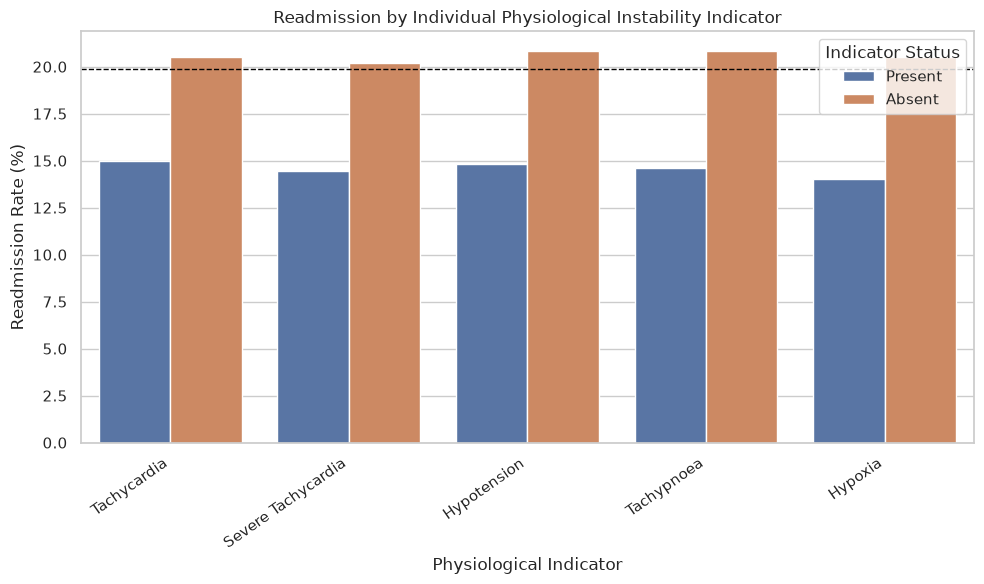

In [58]:
#plot readmission by individual physiological instability indicator
if len(physiology_indicator_readmission_summary):
    physiology_indicator_plot = physiology_indicator_readmission_summary.melt(
        id_vars="Physiological Indicator",
        value_vars=["Readmission Rate if Present (%)", "Readmission Rate if Absent (%)"],
        var_name="Indicator Status",
        value_name="Readmission Rate (%)")
    
    physiology_indicator_plot["Indicator Status"] = physiology_indicator_plot["Indicator Status"].replace({
        "Readmission Rate if Present (%)": "Present",
        "Readmission Rate if Absent (%)": "Absent"})

    plt.figure(figsize=(10, 6))
    sns.barplot(data=physiology_indicator_plot, x="Physiological Indicator", y="Readmission Rate (%)", hue="Indicator Status")
    plt.axhline(df["readmitted_30d"].mean() * 100, color="black", linestyle="--", linewidth=1)
    plt.title("Readmission by Individual Physiological Instability Indicator")
    plt.xlabel("Physiological Indicator")
    plt.ylabel("Readmission Rate (%)")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


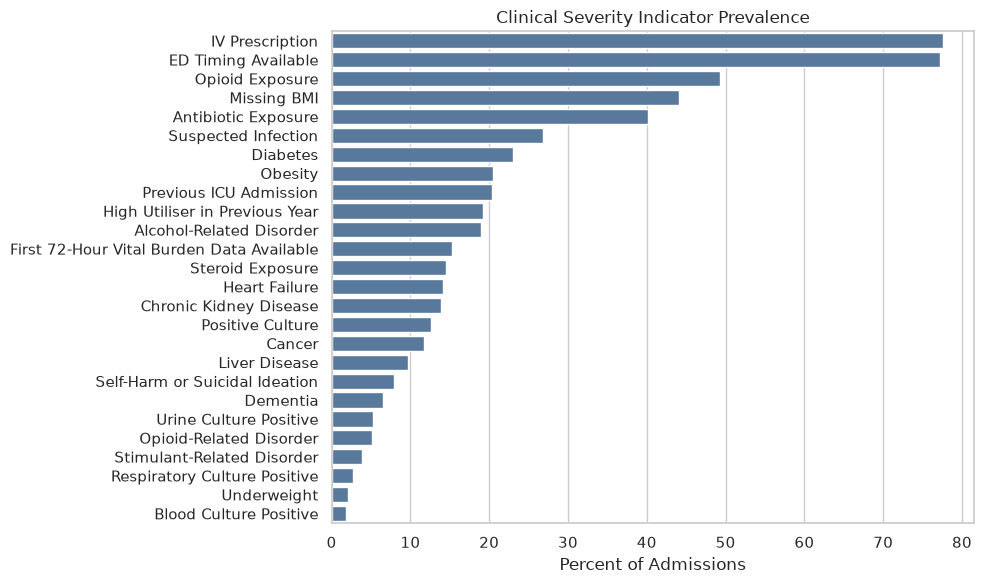

In [59]:
#plot clinical severity indicator prevalence
plt.figure(figsize=(10, 6))
sns.barplot(data=indicator_summary, y="Feature", x="Percent of Cohort", color="#4C78A8")
plt.title("Clinical Severity Indicator Prevalence")
plt.xlabel("Percent of Admissions")
plt.ylabel("")
plt.tight_layout()
plt.show()


Laboratory and vital-sign measurement availability:


,Feature Type,Feature,Admissions with Measurement,Measurement Availability (%)
3,Laboratory,Platelet,174589,73.21
0,Laboratory,Creatinine,174439,73.14
2,Laboratory,Hemoglobin,174403,73.13
7,Laboratory,Wbc,174142,73.02
4,Laboratory,Potassium,173546,72.77
6,Laboratory,Urea Nitrogen,173485,72.74
5,Laboratory,Sodium,173170,72.61
1,Laboratory,Glucose,172325,72.26
8,Vital Sign,Heart Rate,40466,16.97
11,Vital Sign,Respiratory Rate,40429,16.95


Added table to workbook sheet: t2_4_laboratory_and_vital_measu


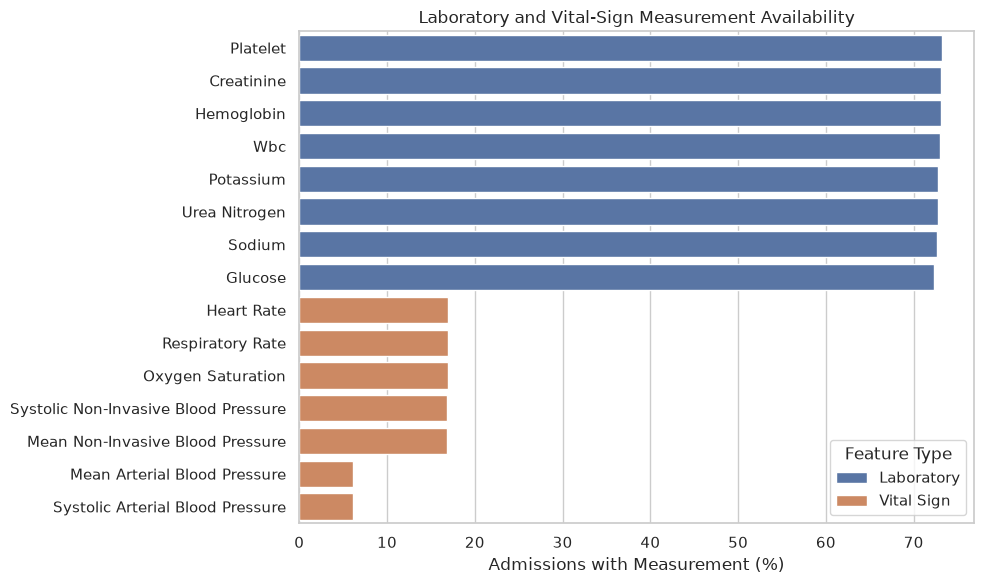

In [60]:
#summarise laboratory and vital-sign data availability at admission level
lab_measured_cols = [col for col in df.columns if col.endswith("_lab_measured")]
vital_measured_cols = [col for col in df.columns if col.endswith("_vital_measured")]

availability_rows = []
for column in lab_measured_cols + vital_measured_cols:
    feature_label = display_name(column.replace("_lab_measured", "").replace("_vital_measured", ""))
    feature_type = "Laboratory" if column in lab_measured_cols else "Vital Sign"
    availability_rows.append({"Feature Type": feature_type, "Feature": feature_label,
        "Admissions with Measurement": int(df[column].sum()),
        "Measurement Availability (%)": round(df[column].mean() * 100, 2)})

measurement_availability_summary = pd.DataFrame(availability_rows).sort_values(["Feature Type", "Measurement Availability (%)"], ascending=[True, False])
print("Laboratory and vital-sign measurement availability:")
display(measurement_availability_summary)
save_table(measurement_availability_summary, "t2_4_laboratory_and_vital_measurement_availability")

plt.figure(figsize=(10, 6))
sns.barplot(data=measurement_availability_summary, y="Feature", x="Measurement Availability (%)", hue="Feature Type")
plt.title("Laboratory and Vital-Sign Measurement Availability")
plt.xlabel("Admissions with Measurement (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Explore first-72-hour temporal vital-sign summaries**

The first-72-hour temporal summary features created in WP2.3 are explored at admission level. These features flatten early dynamic vital-sign data into mean, minimum, maximum, standard deviation, and observed-hour summaries for use in standard machine learning models.




In [61]:
#summarise availability of first-72-hour temporal vital-sign features
observed_72h_cols = [col for col in df.columns if col.endswith('_72h_observed_hours')]
selected_temporal_feature_cols = ['heart_rate_72h_mean', 'heart_rate_72h_max', 'heart_rate_72h_std',
    'respiratory_rate_72h_mean', 'respiratory_rate_72h_max', 'spo2_72h_min', 'spo2_72h_mean',
    'systolic_bp_noninvasive_72h_min', 'mean_bp_noninvasive_72h_min']
selected_temporal_feature_cols = [col for col in selected_temporal_feature_cols if col in df.columns]

df['has_first_72h_vital_data'] = (df[observed_72h_cols].max(axis=1) > 0).astype(int) if observed_72h_cols else 0

first_72h_coverage_summary = pd.DataFrame({'Metric': ['Admissions with first-72-hour hourly vital data',
        'Percentage of admission-level dataset with first-72-hour hourly vital data'],
    'Value': [int(df['has_first_72h_vital_data'].sum()),
        round(df['has_first_72h_vital_data'].mean() * 100, 2)]})

print('First-72-hour temporal vital-sign data coverage:')
display(first_72h_coverage_summary)
save_table(first_72h_coverage_summary, 't2_4_first_72h_temporal_vital_coverage')

first_72h_availability_by_outcome = distribution_readmission_table(df, 'has_first_72h_vital_data')
print('First-72-hour temporal vital-sign availability by readmission outcome:')
display(first_72h_availability_by_outcome)
save_table(first_72h_availability_by_outcome, 't2_4_first_72h_vital_availability_by_readmission')


First-72-hour temporal vital-sign data coverage:


/tmp/ipykernel_81400/1445585581.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_first_72h_vital_data'] = (df[observed_72h_cols].max(axis=1) > 0).astype(int) if observed_72h_cols else 0


,Metric,Value
0,Admissions with first-72-hour hourly vital data,36443.00
1,Percentage of admission-level dataset with fir...,15.28


Added table to workbook sheet: t2_4_first_72h_temporal_vital_c
First-72-hour temporal vital-sign availability by readmission outcome:


,First 72-Hour Vital Data Available,Admissions,Readmissions,Percent,Readmission Rate (%)
0,0,202048,41992,84.72,20.78
1,1,36443,5366,15.28,14.72


Added table to workbook sheet: t2_4_first_72h_vital_availabili


't2_4_first_72h_vital_availabili'

First-72-hour temporal vital observed-hour summary:


,Feature,Mean Observed Hours,Median Observed Hours,Maximum Observed Hours
0,Heart Rate Observed Hours (72 h),6.43,0.0,72.0
1,Mean Bp Arterial 72-Hour Observed Hours,1.64,0.0,72.0
2,Mean BP Observed Hours (72 h),4.61,0.0,72.0
3,Respiratory Rate Observed Hours (72 h),6.34,0.0,72.0
4,Oxygen Saturation Observed Hours (72 h),6.29,0.0,72.0
5,Systolic Bp Arterial 72-Hour Observed Hours,1.64,0.0,72.0
6,Systolic BP Observed Hours (72 h),4.61,0.0,72.0


Added table to workbook sheet: t2_4_first_72h_temporal_vital_o


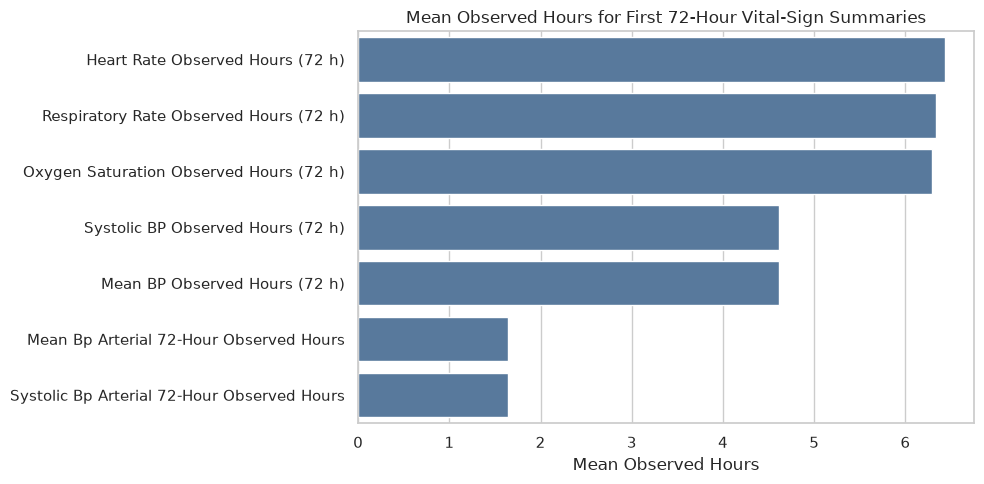

In [62]:
#summarise observed-hour coverage for each first-72-hour temporal vital-sign feature
observed_hour_summary = df[observed_72h_cols].describe().T[['mean', '50%', 'max']].round(2)
observed_hour_summary = observed_hour_summary.reset_index().rename(columns={
    'index': 'Feature', 'mean': 'Mean Observed Hours', '50%': 'Median Observed Hours', 'max': 'Maximum Observed Hours'})
observed_hour_summary['Feature'] = observed_hour_summary['Feature'].map(display_name)

print('First-72-hour temporal vital observed-hour summary:')
display(observed_hour_summary)
save_table(observed_hour_summary, 't2_4_first_72h_temporal_vital_observed_hour_summary')

plt.figure(figsize=(10, 5))
sns.barplot(data=observed_hour_summary.sort_values('Mean Observed Hours', ascending=False),
    x='Mean Observed Hours', y='Feature', color='#4C78A8')
plt.title('Mean Observed Hours for First 72-Hour Vital-Sign Summaries')
plt.xlabel('Mean Observed Hours')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [63]:
#summarise selected first-72-hour temporal vital features by readmission outcome
#value summaries are restricted to admissions with at least one first-72-hour hourly vital observation
first_72h_observed_df = df[df['has_first_72h_vital_data'] == 1].copy()

temporal_summary_by_outcome = (first_72h_observed_df.groupby('readmitted_30d')[selected_temporal_feature_cols]
    .agg(['mean', 'median', 'std']).round(2))

temporal_summary_by_outcome.index = temporal_summary_by_outcome.index.map(outcome_labels)
temporal_summary_by_outcome = temporal_summary_by_outcome.rename(columns=feature_display_names, level=0)
temporal_summary_for_csv = temporal_summary_by_outcome.copy()
temporal_summary_for_csv.columns = [f'{feature} - {stat}' for feature, stat in temporal_summary_for_csv.columns]
temporal_summary_for_csv = temporal_summary_for_csv.reset_index().rename(columns={'readmitted_30d': 'Readmission Outcome'})

print('Selected first-72-hour temporal vital summaries by readmission outcome:')
display(temporal_summary_by_outcome)
save_table(temporal_summary_for_csv, 't2_4_first_72h_temporal_vital_summary_by_outcome')


Selected first-72-hour temporal vital summaries by readmission outcome:


Mean Heart Rate (72 h)               Maximum Heart Rate (72 h)               Heart Rate Variability (72 h)              Mean Respiratory Rate (72 h)               \
                                 mean median    std                      mean median    std                          mean median   std                         mean median   std   
readmitted_30d                                                                                                                                                                     
Not Readmitted                  84.43  83.33  15.04                    106.24  105.0  20.41                          9.37   8.63  4.40                        19.23  18.71  3.72   
Readmitted                      85.26  84.50  14.67                    106.95  106.0  20.28                          9.21   8.39  4.39                        18.93  18.46  3.59   

               Maximum Respiratory Rate (72 h)              Minimum Oxygen Saturation (72 h)              Mean Oxygen Saturation (72 h)              Minimum Systolic BP (72 h)  \
                                          mean median   std                             mean median   std                          mean median   std                       mean   
readmitted_30d                                                                                                                                                                    
Not Readmitted                           28.97   28.0  7.03                            90.64   92.0  5.71                         96.47  96.64  2.11                      94.83   
Readmitted                               28.80   28.0  7.05                            91.10   92.0  4.80                         96.64  96.76  1.76                      95.24   

                             Minimum Mean BP (72 h)                
               median    std                   mean median    std  
readmitted_30d                                                     
Not Readmitted   93.0  16.45                  62.08   61.0  12.78  
Readmitted       93.0  16.47                  62.45   61.0  12.95

Added table to workbook sheet: t2_4_first_72h_temporal_vital_s


't2_4_first_72h_temporal_vital_s'

First-72-hour temporal vital features with the largest outcome separation:


,Feature,Non-readmitted median,Readmitted median,Median difference,Non-readmitted mean,Readmitted mean,Mean difference,Standardised mean difference,Observed admissions,Absolute standardised mean difference
5,Minimum Oxygen Saturation (72 h),92.0000,92.0000,0.0000,90.6417,91.1043,0.4625,0.0828,36443,0.0828
3,Mean Respiratory Rate (72 h),18.7093,18.4615,-0.2478,19.2345,18.9320,-0.3025,-0.0818,36443,0.0818
6,Mean Oxygen Saturation (72 h),96.6410,96.7557,0.1146,96.4716,96.6401,0.1685,0.0817,36443,0.0817
0,Mean Heart Rate (72 h),83.3333,84.5030,1.1697,84.4342,85.2583,0.8240,0.0550,36443,0.0550
2,Heart Rate Variability (72 h),8.6253,8.3882,-0.2371,9.3728,9.2076,-0.1652,-0.0375,36443,0.0375
1,Maximum Heart Rate (72 h),105.0000,106.0000,1.0000,106.2433,106.9470,0.7038,0.0345,36443,0.0345
8,Minimum Mean BP (72 h),61.0000,61.0000,0.0000,62.0827,62.4506,0.3679,0.0287,36443,0.0287
7,Minimum Systolic BP (72 h),93.0000,93.0000,0.0000,94.8329,95.2399,0.4070,0.0247,36443,0.0247
4,Maximum Respiratory Rate (72 h),28.0000,28.0000,0.0000,28.9726,28.8002,-0.1724,-0.0245,36443,0.0245


Added table to workbook sheet: t2_4_first_72h_temporal_vital_2


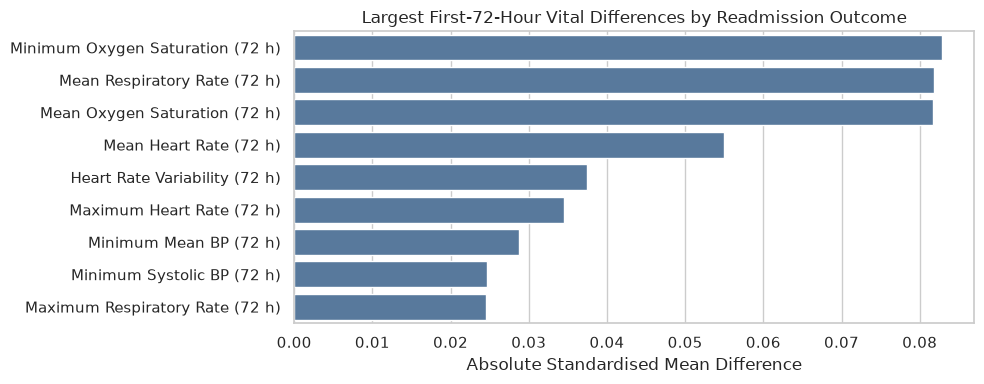

In [64]:
#rank first-72-hour temporal vital features by readmission/non-readmission separation
if len(first_72h_observed_df) and selected_temporal_feature_cols:
    temporal_contrast_rows = []
    #loop through each item in this feature block
    for column in selected_temporal_feature_cols:
        series = pd.to_numeric(first_72h_observed_df[column], errors="coerce")
        non_readmitted = series[first_72h_observed_df["readmitted_30d"] == 0].dropna()
        readmitted = series[first_72h_observed_df["readmitted_30d"] == 1].dropna()
        if non_readmitted.empty or readmitted.empty:
            continue
        pooled_std = series.std()
        mean_difference = readmitted.mean() - non_readmitted.mean()
        temporal_contrast_rows.append({"Feature": display_name(column),
            "Non-readmitted median": non_readmitted.median(),
            "Readmitted median": readmitted.median(),
            "Median difference": readmitted.median() - non_readmitted.median(),
            "Non-readmitted mean": non_readmitted.mean(),
            "Readmitted mean": readmitted.mean(),
            "Mean difference": mean_difference,
            "Standardised mean difference": mean_difference / pooled_std if pooled_std and not pd.isna(pooled_std) else np.nan,
            "Observed admissions": series.notna().sum(),})
    temporal_contrast_df = pd.DataFrame(temporal_contrast_rows)

    if not temporal_contrast_df.empty:
        temporal_contrast_df["Absolute standardised mean difference"] = temporal_contrast_df["Standardised mean difference"].abs()
        temporal_contrast_df = temporal_contrast_df.sort_values(
            ["Absolute standardised mean difference", "Observed admissions"], ascending=[False, False]).round(4)
        print("First-72-hour temporal vital features with the largest outcome separation:")
        display(top_display(temporal_contrast_df))
        save_table(temporal_contrast_df, "t2_4_first_72h_temporal_vital_outcome_contrast_ranked")

        plot_df = top_display(temporal_contrast_df, n=min(10, MAX_PLOT_FEATURES)).copy()
        if len(plot_df):
            plt.figure(figsize=(10, max(4, len(plot_df) * 0.35)))
            sns.barplot(data=plot_df, x="Absolute standardised mean difference", y="Feature", color="#4C78A8")
            plt.title("Largest First-72-Hour Vital Differences by Readmission Outcome")
            plt.xlabel("Absolute Standardised Mean Difference")
            plt.ylabel("")
            plt.tight_layout()
            plt.show()
    else:
        print("No first-72-hour temporal vital contrasts were available.")
else:
    print("No first-72-hour temporal vital observations were available for contrast ranking.")


_Consolidated into the first-72-hour temporal vital contrast ranking above._




_Consolidated into the first-72-hour temporal vital contrast ranking above._




_Consolidated into the first-72-hour temporal vital contrast ranking above._




#### **T2.4.8 - Hourly clinical sequence EDA**

The hourly clinical sequence dataset is explored separately because each row represents one admission-hour rather than one admission. The vital-sign channels are summarised first, followed by the broader clinical activity channels from orders, laboratory events, EMAR, and ICU event tables.

The first 72 admission hours were selected because this interval captures early physiological and care-activity trajectories while limiting the progressive reduction in observations that occurs during longer hospital stays.




In [65]:
#summarise hourly vital-sign dataset coverage and missingness
vital_columns = ["heart_rate", "respiratory_rate", "spo2", "mean_bp_noninvasive",
    "systolic_bp_noninvasive", "mean_bp_arterial", "systolic_bp_arterial"]
vital_columns = [col for col in vital_columns if col in hourly_vitals.columns]

hourly_summary = pd.DataFrame({"Metric": ["Rows", "Columns", "Unique Patients",
            "Unique Admissions", "Minimum Hour", "Median Hour", "Maximum Hour"],
    "Value": [len(hourly_vitals), hourly_vitals.shape[1], hourly_vitals["subject_id"].nunique(),
        hourly_vitals["hadm_id"].nunique(), hourly_vitals["hour_window"].min(),
        hourly_vitals["hour_window"].median(), hourly_vitals["hour_window"].max()]})

print("Hourly vital-sign time-series dataset summary:")
display(hourly_summary)
save_table(hourly_summary, "t2_4_hourly_vital_dataset_summary")

vital_missing_summary = pd.DataFrame({"Vital Sign": [display_name(col) for col in vital_columns],
    "Observed Admission-Hour Windows": [hourly_vitals[col].notna().sum() for col in vital_columns],
    "Missing Admission-Hour Windows": [hourly_vitals[col].isna().sum() for col in vital_columns],
    "Observed Percent": [(hourly_vitals[col].notna().mean() * 100).round(2) for col in vital_columns]
}).sort_values("Observed Admission-Hour Windows", ascending=False)

print("Hourly vital-sign observation coverage:")
display(vital_missing_summary)
save_table(vital_missing_summary, "t2_4_hourly_vital_observation_coverage")

windows_per_admission = hourly_vitals.groupby("hadm_id")["hour_window"].nunique()
windows_per_admission_summary = windows_per_admission.describe().round(2).to_frame("Admission-Hour Windows").reset_index().rename(columns={"index": "Statistic"})
print("Admission-hour windows per admission:")
display(windows_per_admission_summary)
save_table(windows_per_admission_summary, "t2_4_hourly_windows_per_admission_summary")


Hourly vital-sign time-series dataset summary:


,Metric,Value
0,Rows,1550947.0
1,Columns,11.0
2,Unique Patients,29349.0
3,Unique Admissions,36494.0
4,Minimum Hour,1.0
5,Median Hour,30.0
6,Maximum Hour,72.0


Added table to workbook sheet: t2_4_hourly_vital_dataset_summa
Hourly vital-sign observation coverage:


,Vital Sign,Observed Admission-Hour Windows,Missing Admission-Hour Windows,Observed Percent
0,Heart Rate,1540935,10012,99.35
1,Respiratory Rate,1519706,31241,97.99
2,Oxygen Saturation,1507653,43294,97.21
3,Mean Non-Invasive Blood Pressure,1103619,447328,71.16
4,Systolic Non-Invasive Blood Pressure,1102768,448179,71.10
5,Mean Arterial Blood Pressure,395282,1155665,25.49
6,Systolic Arterial Blood Pressure,395182,1155765,25.48


Added table to workbook sheet: t2_4_hourly_vital_observation_c
Admission-hour windows per admission:


,Statistic,Admission-Hour Windows
0,count,36494.00
1,mean,42.50
2,std,21.46
3,min,1.00
4,25%,23.00
5,50%,42.00
6,75%,66.00
7,max,72.00


Added table to workbook sheet: t2_4_hourly_windows_per_admissi


't2_4_hourly_windows_per_admissi'

In [66]:
#report median and interquartile range for admission-hour windows
hourly_window_iqr_summary = pd.DataFrame({
    "Metric": ["Median admission-hour windows", "25th percentile", "75th percentile", "Interquartile range"],
    "Value": [windows_per_admission.median(), windows_per_admission.quantile(0.25),
        windows_per_admission.quantile(0.75),
        windows_per_admission.quantile(0.75) - windows_per_admission.quantile(0.25)]})
hourly_window_iqr_summary["Value"] = hourly_window_iqr_summary["Value"].round(2)
print("Median and interquartile range for admission-hour windows:")
display(hourly_window_iqr_summary)
save_table(hourly_window_iqr_summary, "t2_4_hourly_window_median_iqr_summary")


Median and interquartile range for admission-hour windows:


,Metric,Value
0,Median admission-hour windows,42.0
1,25th percentile,23.0
2,75th percentile,66.0
3,Interquartile range,43.0


Added table to workbook sheet: t2_4_hourly_window_median_iqr_s


't2_4_hourly_window_median_iqr_s'

**Clinical-timeline sequence EDA**

The richer hourly sequence file uses the same admission-hour unit as the vital-sign file, but adds compact clinical activity channels from orders, laboratory events, EMAR medication administration, and ICU event tables. This summary checks coverage and channel density without plotting every event feature individually.




In [67]:
#summarise richer hourly clinical sequence coverage if the optional wp2.3 file exists
clinical_sequence_summary = pd.DataFrame()
clinical_sequence_feature_coverage = pd.DataFrame()
clinical_sequence_family_coverage = pd.DataFrame()

if clinical_sequence_available:
    sequence_key_columns = ["subject_id", "hadm_id", "readmitted_30d", "hour_window"]
    sequence_feature_columns_for_eda = [col for col in clinical_sequence_columns if col not in sequence_key_columns]
    sequence_feature_nonmissing = pd.Series(0, index=sequence_feature_columns_for_eda, dtype="int64")
    sequence_feature_nonzero = pd.Series(0, index=sequence_feature_columns_for_eda, dtype="int64")
    unique_sequence_patients = set()
    unique_sequence_admissions = set()
    sequence_hour_values = []
    sequence_rows = 0
    sequence_chunksize = 500_000

    #loop through each item in this feature block
    for chunk in pd.read_csv(clinical_sequence_file, chunksize=sequence_chunksize):
        sequence_rows += len(chunk)
        unique_sequence_patients.update(chunk["subject_id"].dropna().astype(int).unique().tolist())
        unique_sequence_admissions.update(chunk["hadm_id"].dropna().astype(int).unique().tolist())
        sequence_hour_values.append(chunk["hour_window"].dropna())
        #loop through each item in this feature block
        for col in sequence_feature_columns_for_eda:
            numeric_col = pd.to_numeric(chunk[col], errors="coerce")
            sequence_feature_nonmissing[col] += int(numeric_col.notna().sum())
            sequence_feature_nonzero[col] += int((numeric_col.fillna(0) != 0).sum())

    all_sequence_hours = pd.concat(sequence_hour_values, ignore_index=True) if sequence_hour_values else pd.Series(dtype=float)
    clinical_sequence_summary = pd.DataFrame({"Metric": ["Rows", "Columns", "Unique Patients", "Unique Admissions",
                "Minimum Hour", "Median Hour", "Maximum Hour", "Sequence Feature Channels"],
        "Value": [sequence_rows, len(clinical_sequence_columns), len(unique_sequence_patients), len(unique_sequence_admissions),
            all_sequence_hours.min(), all_sequence_hours.median(), all_sequence_hours.max(), len(sequence_feature_columns_for_eda)]})

    clinical_sequence_feature_coverage = pd.DataFrame({"Sequence Feature": sequence_feature_columns_for_eda,
        "Readable Feature": [display_name(col) for col in sequence_feature_columns_for_eda],
        "Non-Missing Admission-Hour Windows": [sequence_feature_nonmissing[col] for col in sequence_feature_columns_for_eda],
        "Non-Zero Admission-Hour Windows": [sequence_feature_nonzero[col] for col in sequence_feature_columns_for_eda]})
    clinical_sequence_feature_coverage["Non-Zero Percent"] = (clinical_sequence_feature_coverage["Non-Zero Admission-Hour Windows"] / max(sequence_rows, 1) * 100).round(2)
    clinical_sequence_feature_coverage = clinical_sequence_feature_coverage.sort_values("Non-Zero Admission-Hour Windows", ascending=False)

    #define sequence family name
    def sequence_family_name(col):
        if col in vital_columns or col.endswith("_vital"):
            return "Vital signs"
        if col.startswith("num_poe"):
            return "POE/order activity"
        if col.startswith("num_lab") or "lab" in col:
            return "Laboratory activity"
        if col.startswith("num_emar") or "emar" in col:
            return "EMAR medication administration"
        if col.startswith("num_icu"):
            return "ICU event burden"
        if "instability" in col:
            return "Composite instability/process activity"
        if "care_activity" in col or "clinical_events" in col:
            return "Composite care activity"
        return "Other sequence channel"

    family_rows = []
    for family, family_df in clinical_sequence_feature_coverage.assign(Family=lambda x: x["Sequence Feature"].map(sequence_family_name)).groupby("Family"):
        family_rows.append({"Sequence Family": family, "Feature Channels": len(family_df),
            "Total Non-Zero Admission-Hour Windows": int(family_df["Non-Zero Admission-Hour Windows"].sum()),
            "Most Frequent Channel": family_df.iloc[0]["Readable Feature"],
            "Most Frequent Channel Non-Zero Percent": family_df.iloc[0]["Non-Zero Percent"]})
    clinical_sequence_family_coverage = pd.DataFrame(family_rows).sort_values("Total Non-Zero Admission-Hour Windows", ascending=False)

    print("Hourly clinical sequence dataset summary:")
    display(clinical_sequence_summary)
    print("Highest-coverage hourly clinical sequence channels:")
    display(clinical_sequence_feature_coverage.head(20))
    print("Hourly clinical sequence feature-family coverage:")
    display(clinical_sequence_family_coverage)

    save_table(clinical_sequence_summary, "t2_4_hourly_clinical_sequence_summary")
    save_table(clinical_sequence_feature_coverage, "t2_4_hourly_clinical_sequence_channel_coverage")
    save_table(clinical_sequence_family_coverage, "t2_4_hourly_clinical_sequence_family_coverage")
else:
    print("Hourly clinical sequence file not found yet, so this EDA section is skipped until WP2.3 creates it:")
    print(clinical_sequence_file)


Hourly clinical sequence dataset summary:


,Metric,Value
0,Rows,1550947.0
1,Columns,39.0
2,Unique Patients,29349.0
3,Unique Admissions,36494.0
4,Minimum Hour,1.0
5,Median Hour,30.0
6,Maximum Hour,72.0
7,Sequence Feature Channels,35.0


Highest-coverage hourly clinical sequence channels:


,Sequence Feature,Readable Feature,Non-Missing Admission-Hour Windows,Non-Zero Admission-Hour Windows,Non-Zero Percent
0,heart_rate,Heart Rate,1540935,1540935,99.35
3,respiratory_rate,Respiratory Rate,1519706,1519706,97.99
4,spo2,Oxygen Saturation,1507653,1507653,97.21
2,mean_bp_noninvasive,Mean Non-Invasive Blood Pressure,1103619,1103619,71.16
6,systolic_bp_noninvasive,Systolic Non-Invasive Blood Pressure,1102768,1102768,71.10
1,mean_bp_arterial,Mean Arterial Blood Pressure,395282,395282,25.49
5,systolic_bp_arterial,Systolic Arterial Blood Pressure,395182,395182,25.48
7,num_poe_orders,Num POE Orders,1550947,0,0.00
8,num_poe_medication_orders,Num POE Medication Orders,1550947,0,0.00
9,num_poe_lab_orders,Num POE Lab Orders,1550947,0,0.00


Hourly clinical sequence feature-family coverage:


,Sequence Family,Feature Channels,Total Non-Zero Admission-Hour Windows,Most Frequent Channel,Most Frequent Channel Non-Zero Percent
7,Vital signs,7,7565145,Heart Rate,99.35
0,Composite care activity,2,0,Num Total Clinical Events,0.00
2,EMAR medication administration,6,0,Num EMAR Events,0.00
1,Composite instability/process activity,1,0,Num Instability Process Events,0.00
3,ICU event burden,4,0,Num ICU Input Events,0.00
4,Laboratory activity,5,0,Num Lab Events,0.00
5,Other sequence channel,1,0,Num Unique POE Order Types Hourly,0.00
6,POE/order activity,9,0,Num POE Orders,0.00


Added table to workbook sheet: t2_4_hourly_clinical_sequence_s
Added table to workbook sheet: t2_4_hourly_clinical_sequence_c
Added table to workbook sheet: t2_4_hourly_clinical_sequence_f


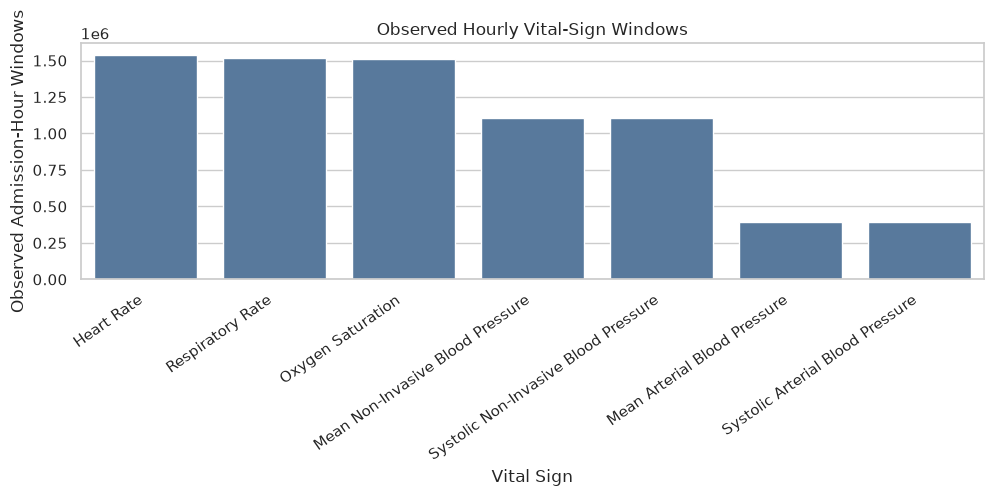

In [68]:
#plot hourly vital-sign observation coverage
plt.figure(figsize=(10, 5))
sns.barplot(data=vital_missing_summary, x="Vital Sign", y="Observed Admission-Hour Windows", color="#4C78A8")
plt.title("Observed Hourly Vital-Sign Windows")
plt.xlabel("Vital Sign")
plt.ylabel("Observed Admission-Hour Windows")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


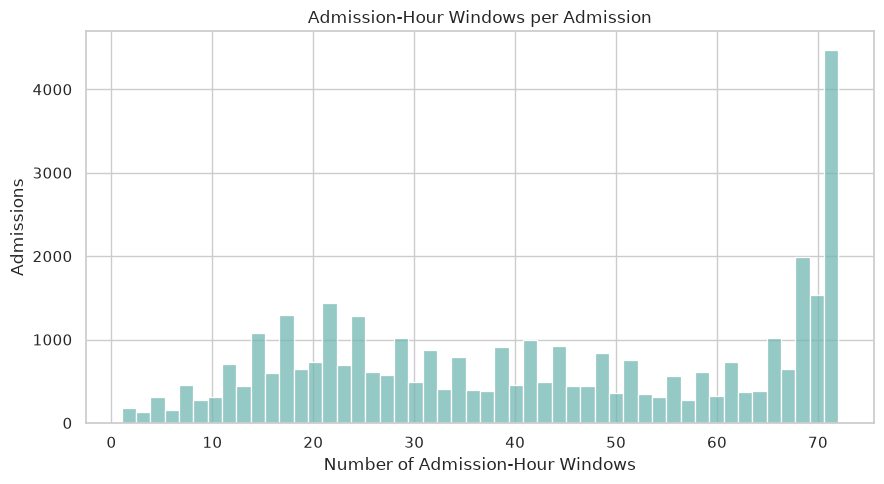

In [69]:
#plot admission-hour windows per admission
plt.figure(figsize=(9, 5))
sns.histplot(windows_per_admission, bins=50, color="#72B7B2")
plt.title("Admission-Hour Windows per Admission")
plt.xlabel("Number of Admission-Hour Windows")
plt.ylabel("Admissions")
plt.tight_layout()
plt.show()


In [70]:
#prepare average vital-sign trajectories over the first 72 admission hours by readmission outcome
trajectory_hours = 72
trajectory_vitals = ["heart_rate", "respiratory_rate", "spo2", "mean_bp_noninvasive"]
trajectory_vitals = [col for col in trajectory_vitals if col in hourly_vitals.columns]

trajectory_df = hourly_vitals[hourly_vitals["hour_window"].between(0, trajectory_hours)].copy()
trajectory_df["Readmission Outcome"] = trajectory_df["readmitted_30d"].map(outcome_labels)

trajectory_summary_frames = []
for column in trajectory_vitals:
    column_summary = (trajectory_df.groupby(["hour_window", "Readmission Outcome"],
        observed=False)[column].mean().reset_index().rename(columns={column: "Mean value"}))
    column_summary["Vital Sign"] = display_name(column)
    trajectory_summary_frames.append(column_summary)

trajectory_summary = pd.concat(trajectory_summary_frames, ignore_index=True) if trajectory_summary_frames else pd.DataFrame()
print("Average first 72-hour vital-sign trajectory table:")
display(trajectory_summary.head(20))
save_table(trajectory_summary, "t2_4_first_72_hour_vital_trajectory_summary")


Average first 72-hour vital-sign trajectory table:


,hour_window,Readmission Outcome,Mean value,Vital Sign
0,1,Not Readmitted,87.707325,Heart Rate
1,1,Readmitted,89.892036,Heart Rate
2,2,Not Readmitted,87.012080,Heart Rate
3,2,Readmitted,88.641927,Heart Rate
4,3,Not Readmitted,86.376267,Heart Rate
5,3,Readmitted,87.724809,Heart Rate
6,4,Not Readmitted,85.937577,Heart Rate
7,4,Readmitted,87.207541,Heart Rate
8,5,Not Readmitted,85.541397,Heart Rate
9,5,Readmitted,87.066307,Heart Rate


Added table to workbook sheet: t2_4_first_72_hour_vital_trajec


't2_4_first_72_hour_vital_trajec'

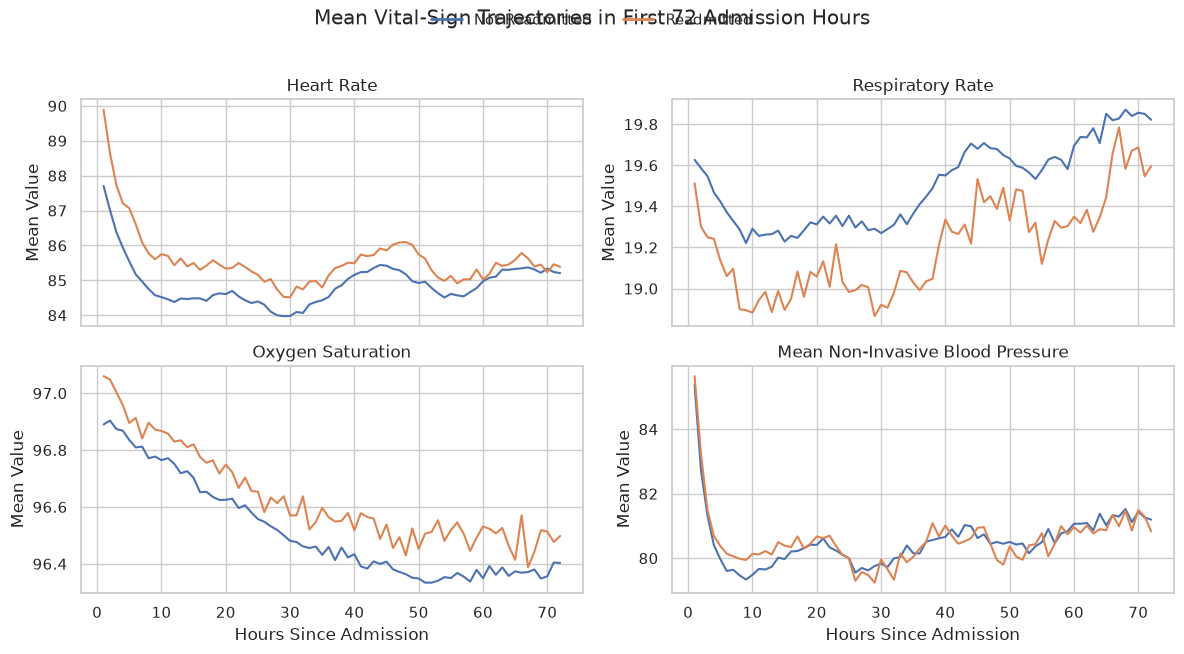

In [71]:
#plot selected first-72-hour vital-sign trajectories in one compact panel
if not trajectory_summary.empty:
    vital_order = trajectory_summary["Vital Sign"].drop_duplicates().tolist()
    n_panels = len(vital_order)
    n_cols = 2
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, max(4, 3.2 * n_rows)), sharex=True)
    axes = np.array(axes).reshape(-1)
    for ax, vital in zip(axes, vital_order):
        plot_df = trajectory_summary[trajectory_summary["Vital Sign"] == vital]
        sns.lineplot(data=plot_df, x="hour_window", y="Mean value", hue="Readmission Outcome", ax=ax, legend=False)
        ax.set_title(vital)
        ax.set_xlabel("Hours Since Admission")
        ax.set_ylabel("Mean Value")
    for ax in axes[n_panels:]:
        ax.axis("off")
    handles = [Line2D([0], [0], color=color, lw=2) for color in sns.color_palette(n_colors=len(outcome_labels))]
    labels = list(outcome_labels.values())
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)
    fig.suptitle("Mean Vital-Sign Trajectories in First 72 Admission Hours", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("No first-72-hour vital trajectories were available to plot.")


_Consolidated into the compact first-72-hour trajectory panel above._




_Consolidated into the compact first-72-hour trajectory panel above._




_Consolidated into the compact first-72-hour trajectory panel above._




#### **T2.4.9 - Association screening**

Associations with 30-day psychiatric readmission were explored using complementary statistical summaries. Categorical predictors were assessed using chi-square tests and Cramer's V, selected binary predictors were summarised using odds ratios, selected continuous predictors were screened using univariate logistic regression, and selected numerical predictors were examined using correlation matrices and variance inflation factors. These analyses are exploratory screening steps rather than final predictive models.




In [72]:

#chi-square tests and cramer's v for categorical and binary variables
expanded_binary_cols = existing_columns([
    "night_admission", "weekend_admission", "has_first_72h_vital_data", "has_first_72h_vital_burden_data",
    "has_previous_psych_admission", "recent_psych_admission_30d", "recent_psych_admission_90d", "recent_psych_admission_365d",
    "has_previous_hospital_admission", "has_previous_nonpsych_admission", "has_previous_icu_admission", "high_utiliser_previous_year",
    "has_severe_mental_illness", "has_self_harm_or_suicidal_ideation", "has_alcohol_related_disorder", "has_opioid_related_disorder", "has_stimulant_related_disorder",
    "has_diabetes", "has_chronic_kidney_disease", "has_copd_or_asthma", "has_heart_failure", "has_liver_disease", "has_cancer", "has_dementia",
    "had_icu_stay", "high_drg_severity", "high_drg_mortality", "multiple_services", "polypharmacy_5plus", "polypharmacy_10plus",
    "any_electrolyte_abnormality", "renal_lab_abnormality", "hematology_lab_abnormality", "tachycardia_indicator", "tachypnoea_indicator", "hypoxia_indicator", "hypotension_indicator",
    "positive_culture_flag", "blood_culture_positive", "urine_culture_positive", "respiratory_culture_positive", "suspected_infection_flag",
    "missed_dose_flag", "incomplete_dose_not_given_flag", "infusion_administration_flag", "had_antibiotic_exposure", "had_opioid_exposure", "had_steroid_exposure", "had_iv_prescription",
    "obesity_flag", "underweight_flag", "missing_bmi_flag", "medical_to_psych_transfer", "psych_to_medical_transfer", "same_service_admission_discharge",
    "recent_psych_admission_smi_interaction", "recent_psych_admission_substance_interaction", "smi_antipsychotic_interaction", "substance_benzodiazepine_interaction", "polypharmacy_age65_interaction", "icu_physiology_instability_interaction", "lab_abnormality_icu_interaction"])

categorical_variables = existing_columns([
    "gender", "age_group", "admission_location_grouped", "discharge_location_grouped", "insurance_grouped",
    "hospital_los_category", "time_since_previous_psych_category", "psych_diagnosis_burden_category",
    "nonpsych_diagnosis_burden_category", "total_diagnosis_burden_category", "drg_severity_category", "drg_mortality_category",
    "service_transfer_category", "physical_transfer_category", "procedure_burden_category", "psych_medication_burden_category",
    "unique_drug_burden_category", "lab_abnormal_burden_category", "physiological_instability_category", "icu_type", "icu_utilisation_category",
    "infection_burden_category", "bmi_category", "last_careunit_before_discharge"
]) + diagnosis_flag_cols + medication_flag_cols + expanded_binary_cols
categorical_variables = list(dict.fromkeys(existing_columns(categorical_variables)))

chi_square_results = []
#loop through each item in this feature block
for column in categorical_variables:
    contingency_table = pd.crosstab(df[column].fillna("Missing"), df["readmitted_30d"])
    if contingency_table.shape[0] <= 1 or contingency_table.shape[1] <= 1:
        continue
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    chi_square_results.append({"Feature": display_name(column), "Original Feature": column, "Chi-Square": chi2,
        "Degrees of Freedom": dof, "p-value": p_value, "Cramer's V": cramers_v})

chi_square_results_df = pd.DataFrame(chi_square_results).sort_values("Cramer's V", ascending=False)
chi_square_results_df["Chi-Square"] = chi_square_results_df["Chi-Square"].round(2)
chi_square_results_df["Cramer's V"] = chi_square_results_df["Cramer's V"].round(3)
chi_square_results_df["p-value"] = chi_square_results_df["p-value"].apply(lambda p: "<0.001" if p < 0.001 else round(p, 3))

print("Categorical association screening results, ranked by Cramer's V:")
display(top_display(chi_square_results_df.drop(columns="Original Feature")))
save_table(chi_square_results_df.drop(columns="Original Feature"), "t2_4_categorical_association_screening")


Categorical association screening results, ranked by Cramer's V:


,Feature,Chi-Square,Degrees of Freedom,p-value,Cramer's V
51,High Utiliser in Previous Year,11453.40,1,<0.001,0.219
6,Time Since Previous Psychiatric Admission,10147.98,5,<0.001,0.206
46,Previous Psychiatric Admission Within 90 Days,8939.09,1,<0.001,0.194
47,Previous Psychiatric Admission Within 365 Days,8045.07,1,<0.001,0.184
45,Previous Psychiatric Admission Within 30 Days,7084.22,1,<0.001,0.172
44,Previous Psychiatric Admission,5546.50,1,<0.001,0.153
16,Unique Drug Burden,4471.93,3,<0.001,0.137
3,Discharge Destination,3744.77,5,<0.001,0.125
67,Polypharmacy: 5+ Drugs,3662.85,1,<0.001,0.124
48,Previous Hospital Admission,3340.16,1,<0.001,0.118


Added table to workbook sheet: t2_4_categorical_association_sc


't2_4_categorical_association_sc'

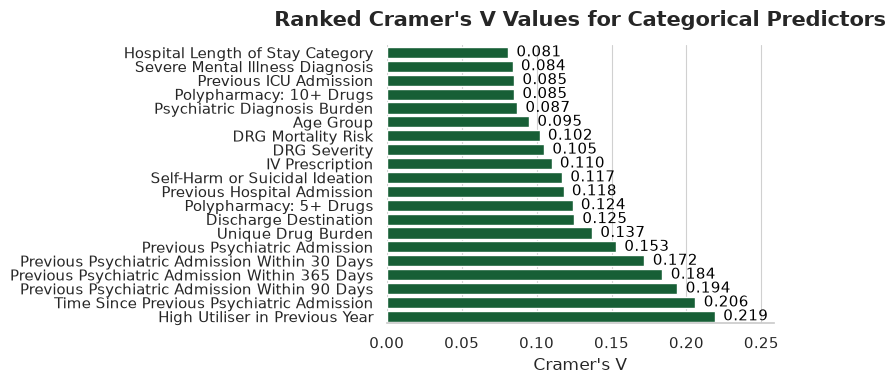

In [73]:
#plot ranked cramer's v values for categorical predictors
plot_df = chi_square_results_df.copy()
plot_df = plot_df.dropna(subset=["Cramer's V"])
plot_df = plot_df.sort_values("Cramer's V", ascending=False).head(20)
plot_df = plot_df.sort_values("Cramer's V", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x="Cramer's V", y="Feature", color="#0B6B34", ax=ax)

#add the cramer's v value at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", padding=6, fontsize=11, color="black")

#style the plot for report-friendly display
ax.set_title("Ranked Cramer's V Values for Categorical Predictors", fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Cramer's V")
ax.set_ylabel("")
ax.set_xlim(0, plot_df["Cramer's V"].max() * 1.18)
ax.grid(axis="x", color="#d0d0d0", linewidth=0.8)
ax.grid(axis="y", visible=False)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

In [74]:
#correlation matrix for selected numerical features using readable labels
correlation_features = existing_columns([
    "anchor_age", "hospital_los_days", "admission_hour", "previous_psych_admissions",
    "previous_total_admissions", "previous_total_admissions_30d", "previous_total_admissions_90d", "previous_total_admissions_365d",
    "previous_nonpsych_admissions_365d", "days_since_previous_hospital_admission_filled",
    "previous_icu_admissions", "days_since_previous_icu_admission_filled", "previous_psych_to_total_admission_ratio",
    "psych_diagnosis_group_count", "num_nonpsych_diagnoses", "charlson_comorbidity_index_simple", "elixhauser_group_count_simple",
    "num_transfer_events", "num_unique_careunits", "num_procedures", "time_to_first_transfer_hours",
    "num_unique_drugs", "num_psych_med_classes", "administered_medication_count", "missed_dose_count",
    "microbiology_test_count", "distinct_organism_count", "num_abnormal_labs", "physiological_instability_score",
    "first_72h_abnormal_hour_percent", "first_72h_max_instability_score", "first_72h_mean_instability_score",
    "total_icu_los_days", "ed_length_of_stay_hours", "bmi", "readmitted_30d"])

corr_matrix = df[correlation_features].corr()
corr_matrix_labeled = corr_matrix.rename(index=feature_display_names, columns=feature_display_names)
corr_matrix_for_csv = corr_matrix_labeled.reset_index().rename(columns={"index": "Feature"})

print("Correlation matrix for selected numerical features:")
display(corr_matrix_labeled)
save_table(corr_matrix_for_csv, "t2_4_selected_numerical_feature_correlation_matrix")


Correlation matrix for selected numerical features:


,Age,Hospital Length of Stay,Admission Hour,Previous Psychiatric Admissions,Previous Hospital Admissions,Previous Hospital Admissions in 30 Days,Previous Hospital Admissions in 90 Days,Previous Hospital Admissions in 365 Days,Previous Non-Psychiatric Admissions in 365 Days,Days Since Previous Hospital Admission (Filled),Previous ICU Admissions,Days Since Previous ICU Admission (Filled),Psychiatric-to-Total Previous Admission Ratio,Psychiatric Diagnosis Groups,Non-Psychiatric Diagnoses,Transfer Events,Unique Care Units,Procedures,Time to First Transfer (Hours),Unique Drugs Prescribed,Psychiatric Medication Classes,Microbiology Test Count,Distinct Organism Count,Abnormal Laboratory Tests,Physiological Instability Score,Total ICU Length of Stay,ED Length of Stay (Hours),30-Day Psychiatric Readmission
Age,1.000000,0.104282,0.050330,-0.074013,-0.053196,-0.047075,-0.043418,-0.047945,0.057916,0.021466,0.001558,0.033816,-0.079735,-0.212659,0.426482,0.143393,0.132101,0.102399,0.022309,0.284285,0.085097,0.071551,0.088081,0.361979,0.140583,0.074273,-0.174610,-0.080887
Hospital Length of Stay,0.104282,1.000000,0.028938,-0.041831,-0.027938,0.031019,0.008028,-0.020204,0.046746,-0.020403,0.047466,0.018810,-0.008496,0.048307,0.457568,0.443216,0.250570,0.549043,-0.016290,0.647217,0.370887,0.593155,0.448438,0.476877,0.350501,0.521231,-0.074136,-0.014435
Admission Hour,0.050330,0.028938,1.000000,0.008042,0.014653,0.018628,0.014709,0.015585,0.021018,-0.009585,0.026030,0.011074,0.033807,0.017956,0.059805,-0.006656,-0.048559,-0.035723,-0.151092,0.000912,0.025140,0.021090,0.017586,0.033587,-0.020644,-0.005060,0.023857,0.021343
Previous Psychiatric Admissions,-0.074013,-0.041831,0.008042,1.000000,0.965317,0.383360,0.525590,0.717606,0.057775,-0.048306,0.378280,0.167504,0.342170,0.071879,0.000797,-0.039274,-0.027110,-0.088422,-0.000268,-0.056950,-0.005203,-0.034164,-0.024213,-0.048423,-0.064242,-0.044823,0.040812,0.211194
Previous Hospital Admissions,-0.053196,-0.027938,0.014653,0.965317,1.000000,0.382555,0.532635,0.732577,0.210615,-0.039561,0.434441,0.214779,0.300595,0.044603,0.064676,-0.027482,-0.017763,-0.083893,0.002288,-0.020068,0.005439,-0.023122,-0.013123,-0.006268,-0.063269,-0.043444,0.029649,0.204319
Previous Hospital Admissions in 30 Days,-0.047075,0.031019,0.018628,0.383360,0.382555,1.000000,0.793376,0.580896,0.215342,-0.170881,0.183141,0.005777,0.330807,0.043247,-0.003612,-0.046330,-0.090903,-0.056805,-0.019539,-0.023053,0.057950,-0.008220,-0.004861,-0.017963,-0.062283,-0.038217,-0.007988,0.204094
Previous Hospital Admissions in 90 Days,-0.043418,0.008028,0.014709,0.525590,0.532635,0.793376,1.000000,0.790320,0.316686,-0.177236,0.257610,0.022967,0.354652,0.032262,0.020736,-0.043006,-0.069921,-0.059920,-0.012093,-0.012858,0.039515,-0.003717,0.000570,0.004133,-0.064392,-0.042279,-0.002487,0.249170
Previous Hospital Admissions in 365 Days,-0.047945,-0.020204,0.015585,0.717606,0.732577,0.580896,0.790320,1.000000,0.388717,-0.146901,0.358076,0.058470,0.346667,0.028553,0.026423,-0.039386,-0.045338,-0.075338,-0.010375,-0.024737,0.012757,-0.011914,-0.006552,-0.001553,-0.067325,-0.045494,0.000533,0.256048
Previous Non-Psychiatric Admissions in 365 Days,0.057916,0.046746,0.021018,0.057775,0.210615,0.215342,0.316686,0.388717,1.000000,-0.091371,0.202228,0.041639,-0.073966,-0.104372,0.160756,0.021568,0.000329,0.014875,-0.002445,0.104202,0.031831,0.047087,0.040905,0.136216,-0.007079,-0.001155,-0.062415,0.043851
Days Since Previous Hospital Admission (Filled),0.021466,-0.020403,-0.009585,-0.048306,-0.039561,-0.170881,-0.177236,-0.146901,-0.091371,1.000000,-0.028339,0.182791,0.127893,0.001524,0.056499,0.001345,0.016108,-0.018025,0.020661,0.000860,-0.003356,-0.024815,-0.021806,-0.000215,-0.017459,-0.013285,0.057999,-0.055445


Added table to workbook sheet: t2_4_selected_numerical_feature


't2_4_selected_numerical_feature'

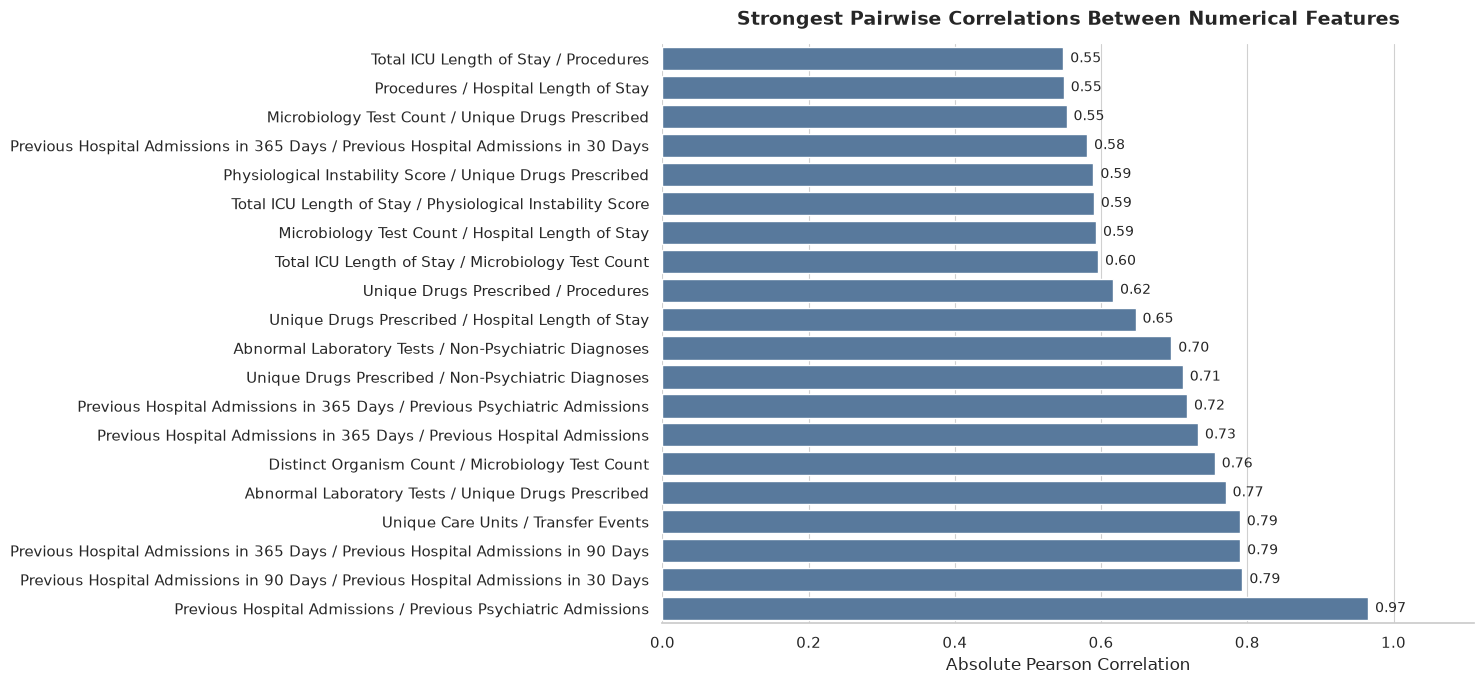

In [75]:
#plot strongest absolute numerical correlations as a readable ranked bar chart
corr_pairs = []
corr_matrix = corr_matrix_labeled.copy()

#extract the lower triangle so each feature pair appears once
for row_position, row_name in enumerate(corr_matrix.index):
    for column_position, column_name in enumerate(corr_matrix.columns):
        if column_position >= row_position:
            continue
        corr_value = corr_matrix.loc[row_name, column_name]
        if pd.notna(corr_value):
            corr_pairs.append({"Feature Pair": f"{row_name} / {column_name}",
                "Correlation": corr_value,
                "Absolute Correlation": abs(corr_value)})

corr_pairs_df = pd.DataFrame(corr_pairs)
plot_df = (corr_pairs_df.sort_values("Absolute Correlation", ascending=False)
    .head(20)
    .sort_values("Absolute Correlation", ascending=True))

fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(data=plot_df, x="Absolute Correlation", y="Feature Pair", color="#4C78A8", ax=ax)

#add correlation values at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=5, fontsize=10)

#style the chart for report-friendly display
ax.set_title("Strongest Pairwise Correlations Between Numerical Features", fontsize=14, weight="bold", pad=14)
ax.set_xlabel("Absolute Pearson Correlation")
ax.set_ylabel("")
ax.set_xlim(0, plot_df["Absolute Correlation"].max() * 1.15)
ax.grid(axis="x", color="#d0d0d0", linewidth=0.8)
ax.grid(axis="y", visible=False)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()


In [76]:
#correlations between numerical features and readmission outcome
numeric_association_features = [col for col in correlation_features if col != "readmitted_30d"]
numeric_associations = []
for column in numeric_association_features:
    series = pd.to_numeric(df[column], errors="coerce")
    numeric_associations.append({"Feature": display_name(column), "Original Feature": column,
        "Correlation with Readmission": series.corr(df["readmitted_30d"]),
        "Mean if Not Readmitted": series[df["readmitted_30d"] == 0].mean(),
        "Mean if Readmitted": series[df["readmitted_30d"] == 1].mean(),
        "Missing (%)": series.isna().mean() * 100})

numeric_associations_df = pd.DataFrame(numeric_associations)
numeric_associations_df["Absolute Correlation"] = numeric_associations_df["Correlation with Readmission"].abs()
numeric_associations_df = numeric_associations_df.sort_values("Absolute Correlation", ascending=False)
for column in ["Correlation with Readmission", "Mean if Not Readmitted", "Mean if Readmitted", "Absolute Correlation", "Missing (%)"]:
    numeric_associations_df[column] = numeric_associations_df[column].round(3)

numeric_associations_for_display = numeric_associations_df.drop(columns="Original Feature")
print("Numerical association screening results, ranked by absolute correlation:")
display(top_display(numeric_associations_for_display))
save_table(numeric_associations_for_display, "t2_4_numerical_association_screening")


Numerical association screening results, ranked by absolute correlation:


,Feature,Correlation with Readmission,Mean if Not Readmitted,Mean if Readmitted,Missing (%),Absolute Correlation
7,Previous Hospital Admissions in 365 Days,0.256,1.176,3.333,0.000,0.256
6,Previous Hospital Admissions in 90 Days,0.249,0.486,1.320,0.000,0.249
3,Previous Psychiatric Admissions,0.211,2.477,7.583,0.000,0.211
4,Previous Hospital Admissions,0.204,3.473,8.883,0.000,0.204
5,Previous Hospital Admissions in 30 Days,0.204,0.240,0.598,0.000,0.204
12,Psychiatric-to-Total Previous Admission Ratio,0.162,0.417,0.600,0.000,0.162
10,Previous ICU Admissions,0.102,0.372,0.728,0.000,0.102
26,ED Length of Stay (Hours),0.094,11.182,13.943,22.852,0.094
13,Psychiatric Diagnosis Groups,0.085,1.515,1.684,0.000,0.085
0,Age,-0.081,55.144,51.306,0.000,0.081


Added table to workbook sheet: t2_4_numerical_association_scre


't2_4_numerical_association_scre'

Top variables ranked by exploratory association with readmission:


,Feature,Association Strength,Association Measure
88,Previous Hospital Admissions in 365 Days,0.256,Absolute correlation with readmission
89,Previous Hospital Admissions in 90 Days,0.249,Absolute correlation with readmission
0,High Utiliser in Previous Year,0.219,Cramer's V
90,Previous Psychiatric Admissions,0.211,Absolute correlation with readmission
1,Time Since Previous Psychiatric Admission,0.206,Cramer's V
91,Previous Hospital Admissions,0.204,Absolute correlation with readmission
92,Previous Hospital Admissions in 30 Days,0.204,Absolute correlation with readmission
2,Previous Psychiatric Admission Within 90 Days,0.194,Cramer's V
3,Previous Psychiatric Admission Within 365 Days,0.184,Cramer's V
4,Previous Psychiatric Admission Within 30 Days,0.172,Cramer's V


Added table to workbook sheet: t2_4_top_variables_ranked_by_ex


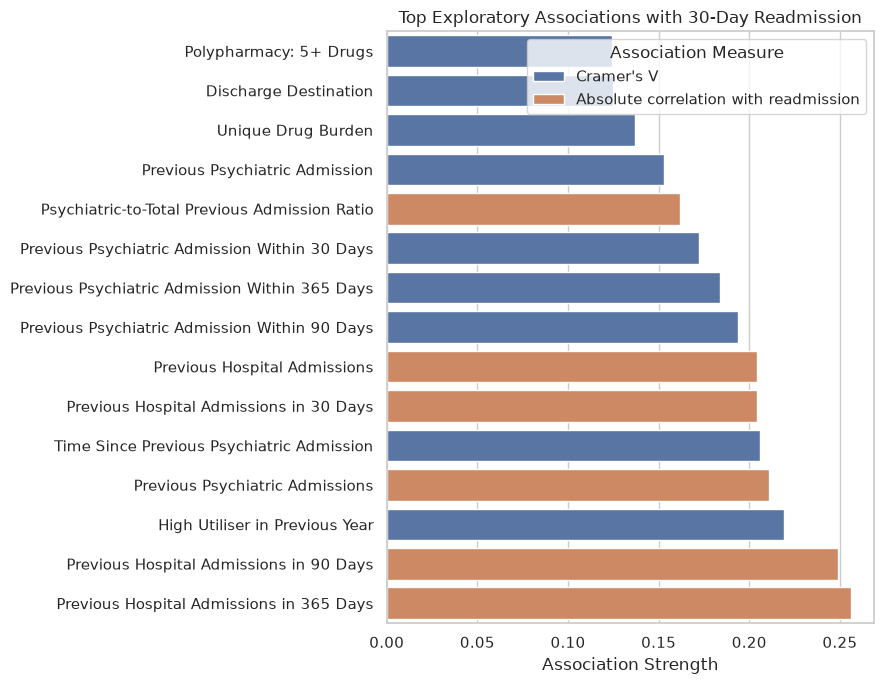

In [77]:
#combined top association screening table for transition into modelling
categorical_ranking = chi_square_results_df[["Feature", "Cramer's V"]].copy()
categorical_ranking = categorical_ranking.rename(columns={"Cramer's V": "Association Strength"})
categorical_ranking["Association Measure"] = "Cramer's V"

numerical_ranking = numeric_associations_df[["Feature", "Absolute Correlation"]].copy()
numerical_ranking = numerical_ranking.rename(columns={"Absolute Correlation": "Association Strength"})
numerical_ranking["Association Measure"] = "Absolute correlation with readmission"

combined_association_ranking = pd.concat([categorical_ranking, numerical_ranking], ignore_index=True)
combined_association_ranking = combined_association_ranking.sort_values("Association Strength", ascending=False).head(MAX_TABLE_ROWS)
combined_association_ranking["Association Strength"] = combined_association_ranking["Association Strength"].round(3)

print("Top variables ranked by exploratory association with readmission:")
display(combined_association_ranking)
save_table(combined_association_ranking, "t2_4_top_variables_ranked_by_exploratory_association")

plot_df = combined_association_ranking.head(MAX_PLOT_FEATURES).sort_values("Association Strength", ascending=True)
plt.figure(figsize=(9, 7))
sns.barplot(data=plot_df, x="Association Strength", y="Feature", hue="Association Measure")
plt.title("Top Exploratory Associations with 30-Day Readmission")
plt.xlabel("Association Strength")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [78]:
#odds ratios for selected binary predictors
binary_odds_ratio_features = existing_columns([
    "has_previous_psych_admission", "recent_psych_admission_30d", "recent_psych_admission_90d", "recent_psych_admission_365d",
    "has_previous_hospital_admission", "has_previous_nonpsych_admission", "has_previous_icu_admission", "high_utiliser_previous_year",
    "night_admission", "weekend_admission", "has_severe_mental_illness", "has_self_harm_or_suicidal_ideation",
    "has_alcohol_related_disorder", "has_opioid_related_disorder", "has_stimulant_related_disorder",
    "has_diabetes", "has_chronic_kidney_disease", "has_copd_or_asthma", "has_heart_failure", "has_liver_disease", "has_cancer", "has_dementia",
    "high_drg_severity", "high_drg_mortality", "multiple_services", "had_icu_stay", "prolonged_icu_stay_3plus_days",
    "polypharmacy_5plus", "polypharmacy_10plus", "had_antibiotic_exposure", "had_opioid_exposure", "had_steroid_exposure", "had_iv_prescription",
    "positive_culture_flag", "blood_culture_positive", "urine_culture_positive", "respiratory_culture_positive", "suspected_infection_flag",
    "missed_dose_flag", "incomplete_dose_not_given_flag", "infusion_administration_flag", "obesity_flag", "underweight_flag", "missing_bmi_flag",
    "any_electrolyte_abnormality", "renal_lab_abnormality", "hematology_lab_abnormality", "tachycardia_indicator", "tachypnoea_indicator", "hypoxia_indicator", "hypotension_indicator",
    "has_first_72h_vital_data", "has_first_72h_vital_burden_data", "medical_to_psych_transfer", "psych_to_medical_transfer", "same_service_admission_discharge",
    "recent_psych_admission_smi_interaction", "recent_psych_admission_substance_interaction", "smi_antipsychotic_interaction", "substance_benzodiazepine_interaction",
    "polypharmacy_age65_interaction", "icu_physiology_instability_interaction", "lab_abnormality_icu_interaction"])

odds_ratio_rows = []
#loop through each item in this feature block
for column in binary_odds_ratio_features:
    values = pd.to_numeric(df[column], errors="coerce").fillna(0)
    exposed = df[values == 1]
    unexposed = df[values == 0]
    if len(exposed) == 0 or len(unexposed) == 0:
        continue

    a = ((values == 1) & (df["readmitted_30d"] == 1)).sum()
    b = ((values == 1) & (df["readmitted_30d"] == 0)).sum()
    c = ((values == 0) & (df["readmitted_30d"] == 1)).sum()
    d = ((values == 0) & (df["readmitted_30d"] == 0)).sum()

    if min(a, b, c, d) == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    odds_ratio = (a * d) / (b * c)
    log_or = np.log(odds_ratio)
    se_log_or = np.sqrt((1 / a) + (1 / b) + (1 / c) + (1 / d))
    ci_low = np.exp(log_or - 1.96 * se_log_or)
    ci_high = np.exp(log_or + 1.96 * se_log_or)
    p_value = 2 * norm.sf(abs(log_or / se_log_or))

    odds_ratio_rows.append({"Predictor": display_name(column), "Original Feature": column, "Reference Group": "No",
        "Comparison Group": "Yes", "Admissions with Feature": int((values == 1).sum()),
        "Readmission Rate if Feature Present (%)": round(exposed["readmitted_30d"].mean() * 100, 2),
        "Readmission Rate if Feature Absent (%)": round(unexposed["readmitted_30d"].mean() * 100, 2),
        "Risk Difference (percentage points)": round((exposed["readmitted_30d"].mean() - unexposed["readmitted_30d"].mean()) * 100, 2),
        "Odds Ratio": odds_ratio, "95% CI Lower": ci_low, "95% CI Upper": ci_high, "p-value": p_value})

odds_ratio_results = pd.DataFrame(odds_ratio_rows)
if not odds_ratio_results.empty:
    odds_ratio_results["Absolute log(OR)"] = np.log(odds_ratio_results["Odds Ratio"]).abs()
    odds_ratio_results = odds_ratio_results.sort_values("Absolute log(OR)", ascending=False)
    #loop through each item in this feature block
    for col in ["Odds Ratio", "95% CI Lower", "95% CI Upper"]:
        odds_ratio_results[col] = odds_ratio_results[col].round(3)
    odds_ratio_results["p-value"] = odds_ratio_results["p-value"].apply(lambda p: "<0.001" if p < 0.001 else round(p, 3))
    odds_ratio_results_for_display = odds_ratio_results.drop(columns=["Absolute log(OR)", "Original Feature"])
else:
    odds_ratio_results_for_display = odds_ratio_results

print("Odds ratios for selected binary predictors, ranked by absolute log odds ratio:")
display(top_display(odds_ratio_results_for_display))
save_table(odds_ratio_results_for_display, "t2_4_selected_binary_predictor_odds_ratios")


Odds ratios for selected binary predictors, ranked by absolute log odds ratio:


,Predictor,Reference Group,Comparison Group,Admissions with Feature,Readmission Rate if Feature Present (%),Readmission Rate if Feature Absent (%),Risk Difference (percentage points),Odds Ratio,95% CI Lower,95% CI Upper,p-value
7,High Utiliser in Previous Year,No,Yes,45718,37.81,15.60,22.21,3.289,3.216,3.364,<0.001
2,Previous Psychiatric Admission Within 90 Days,No,Yes,70809,31.74,14.84,16.90,2.669,2.614,2.725,<0.001
1,Previous Psychiatric Admission Within 30 Days,No,Yes,47674,33.61,16.42,17.19,2.577,2.520,2.636,<0.001
3,Previous Psychiatric Admission Within 365 Days,No,Yes,100526,28.44,13.60,14.84,2.524,2.473,2.577,<0.001
11,Self-Harm or Suicidal Ideation,No,Yes,18927,35.70,18.49,17.20,2.447,2.371,2.525,<0.001
0,Previous Psychiatric Admission,No,Yes,130565,25.39,13.17,12.22,2.244,2.196,2.293,<0.001
26,Polypharmacy: 5+ Drugs,No,Yes,191997,17.42,29.90,-12.48,0.495,0.483,0.506,<0.001
4,Previous Hospital Admission,No,Yes,151445,23.44,13.63,9.81,1.940,1.896,1.984,<0.001
31,IV Prescription,No,Yes,185158,17.51,28.00,-10.49,0.546,0.534,0.558,<0.001
10,Severe Mental Illness Diagnosis,No,Yes,32817,28.28,18.51,9.76,1.735,1.690,1.782,<0.001


Added table to workbook sheet: t2_4_selected_binary_predictor_


't2_4_selected_binary_predictor_'

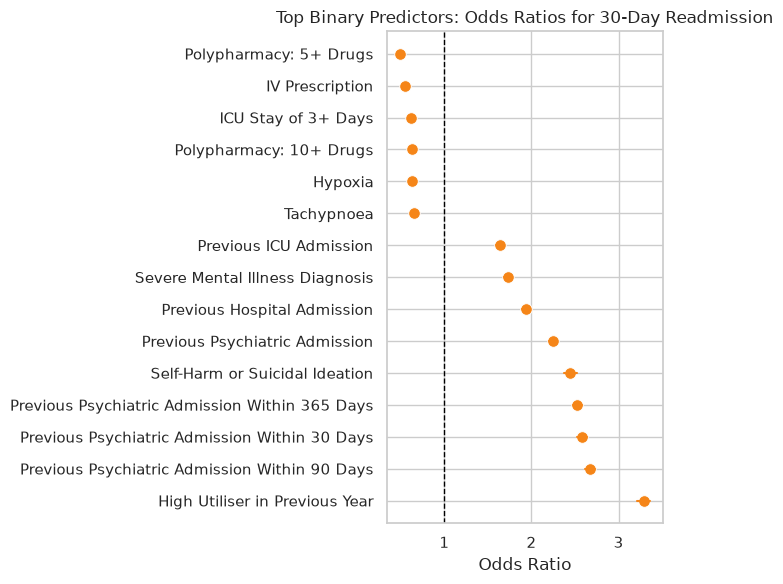

In [79]:
#plot the most informative significant binary predictor odds ratios only
if not odds_ratio_results.empty:
    plot_df = odds_ratio_results.copy()
    plot_df["p_value_numeric"] = pd.to_numeric(
        plot_df["p-value"].astype(str).str.replace("<", "", regex=False), errors="coerce")
    plot_df = (plot_df.loc[plot_df["p_value_numeric"] < 0.05]
        .sort_values("Absolute log(OR)", ascending=False)
        .head(MAX_PLOT_FEATURES)
        .sort_values("Odds Ratio", ascending=True))

    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=plot_df, x="Odds Ratio", y="Predictor", color="#F58518", s=70)
    for _, row in plot_df.iterrows():
        plt.plot([row["95% CI Lower"], row["95% CI Upper"]], [row["Predictor"], row["Predictor"]], color="#F58518", linewidth=1.5)

    plt.axvline(1, color="black", linestyle="--", linewidth=1)
    plt.title("Top Binary Predictors: Odds Ratios for 30-Day Readmission")
    plt.xlabel("Odds Ratio")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


In [80]:
#univariate logistic regression for selected continuous predictors
continuous_logistic_features = existing_columns([
    "anchor_age", "hospital_los_days", "admission_hour", "previous_psych_admissions", "previous_total_admissions",
    "previous_total_admissions_30d", "previous_total_admissions_90d", "previous_total_admissions_365d",
    "previous_nonpsych_admissions_365d", "days_since_previous_hospital_admission_filled",
    "previous_icu_admissions", "days_since_previous_icu_admission_filled", "previous_psych_to_total_admission_ratio",
    "psych_diagnosis_group_count", "num_nonpsych_diagnoses", "charlson_comorbidity_index_simple", "elixhauser_group_count_simple",
    "num_unique_drugs", "num_psych_med_classes", "administered_medication_count", "missed_dose_count", "iv_medication_administration_count",
    "microbiology_test_count", "distinct_organism_count", "num_labs_measured", "num_abnormal_labs", "electrolyte_abnormality_count",
    "physiological_instability_score", "first_72h_abnormal_hour_percent", "first_72h_abnormal_hour_count", "first_72h_max_instability_score", "first_72h_mean_instability_score",
    "total_icu_los_days", "ed_length_of_stay_hours", "ed_to_admission_hours", "ed_to_ward_delay_hours", "bmi",
    "heart_rate_72h_mean", "heart_rate_72h_std", "respiratory_rate_72h_mean", "spo2_72h_min", "systolic_bp_noninvasive_72h_min"])

#define fit univariate logistic
def fit_univariate_logistic(model_data, predictor_col, outcome_col="readmitted_30d", max_iter=50, tol=1e-8):
    x = model_data[predictor_col].astype(float).to_numpy()
    y = model_data[outcome_col].astype(float).to_numpy()
    X = np.column_stack([np.ones(len(x)), x])
    beta = np.zeros(X.shape[1])

    #loop through each item in this feature block
    for _ in range(max_iter):
        p_hat = np.clip(expit(X @ beta), 1e-8, 1 - 1e-8)
        weights = p_hat * (1 - p_hat)
        gradient = X.T @ (y - p_hat)
        information = (X.T * weights) @ X
        step = np.linalg.solve(information, gradient)
        beta = beta + step
        if np.max(np.abs(step)) < tol:
            break

    covariance = np.linalg.inv(information)
    se = np.sqrt(np.diag(covariance))
    coef = beta[1]
    se_coef = se[1]
    z_score = coef / se_coef
    p_value = 2 * norm.sf(abs(z_score))
    ci_low = coef - 1.96 * se_coef
    ci_high = coef + 1.96 * se_coef
    return coef, ci_low, ci_high, p_value

logistic_rows = []
#loop through each item in this feature block
for column in continuous_logistic_features:
    model_data = df[[column, "readmitted_30d"]].replace([np.inf, -np.inf], np.nan).dropna()
    if model_data[column].nunique() <= 1:
        continue
    try:
        coef, conf_low, conf_high, p_value = fit_univariate_logistic(model_data, column)
        logistic_rows.append({
            "Predictor": display_name(column),
            "Admissions Used": len(model_data),
            "Missing (%)": round((1 - len(model_data) / len(df)) * 100, 2),
            "Odds Ratio per Unit Increase": np.exp(coef),
            "95% CI Lower": np.exp(conf_low),
            "95% CI Upper": np.exp(conf_high),
            "p-value": p_value})
    except Exception:
        logistic_rows.append({"Predictor": display_name(column), "Admissions Used": len(model_data), "Missing (%)": round((1 - len(model_data) / len(df)) * 100, 2),
            "Odds Ratio per Unit Increase": np.nan, "95% CI Lower": np.nan, "95% CI Upper": np.nan, "p-value": np.nan})

univariate_logistic_results = pd.DataFrame(logistic_rows)
if not univariate_logistic_results.empty:
    univariate_logistic_results["Absolute log(OR)"] = np.log(univariate_logistic_results["Odds Ratio per Unit Increase"]).abs()
    univariate_logistic_results = univariate_logistic_results.sort_values("Absolute log(OR)", ascending=False)
    for col in ["Odds Ratio per Unit Increase", "95% CI Lower", "95% CI Upper"]:
        univariate_logistic_results[col] = univariate_logistic_results[col].round(4)
    univariate_logistic_results["p-value"] = univariate_logistic_results["p-value"].apply(lambda p: "<0.001" if pd.notna(p) and p < 0.001 else (round(p, 3) if pd.notna(p) else np.nan))
    univariate_logistic_display = univariate_logistic_results.drop(columns="Absolute log(OR)")
else:
    univariate_logistic_display = univariate_logistic_results

print("Univariate logistic regression for selected continuous predictors:")
display(top_display(univariate_logistic_display))
save_table(univariate_logistic_display, "t2_4_univariate_logistic_regression_continuous_predictors")


Univariate logistic regression for selected continuous predictors:


,Predictor,Admissions Used,Missing (%),Odds Ratio per Unit Increase,95% CI Lower,95% CI Upper,p-value
12,Psychiatric-to-Total Previous Admission Ratio,238491,0.00,2.4855,2.4292,2.5430,<0.001
5,Previous Hospital Admissions in 30 Days,238491,0.00,1.8685,1.8429,1.8945,<0.001
6,Previous Hospital Admissions in 90 Days,238491,0.00,1.5192,1.5074,1.5312,<0.001
13,Psychiatric Diagnosis Groups,238491,0.00,1.2801,1.2651,1.2953,<0.001
7,Previous Hospital Admissions in 365 Days,238491,0.00,1.1968,1.1927,1.2008,<0.001
10,Previous ICU Admissions,238491,0.00,1.1619,1.1543,1.1696,<0.001
22,Physiological Instability Score,238491,0.00,0.8949,0.8877,0.9022,<0.001
8,Previous Non-Psychiatric Admissions in 365 Days,238491,0.00,1.1046,1.0943,1.1150,<0.001
3,Previous Psychiatric Admissions,238491,0.00,1.0561,1.0547,1.0574,<0.001
19,Laboratory Tests Measured,238491,0.00,0.9483,0.9457,0.9510,<0.001


Added table to workbook sheet: t2_4_univariate_logistic_regres


't2_4_univariate_logistic_regres'

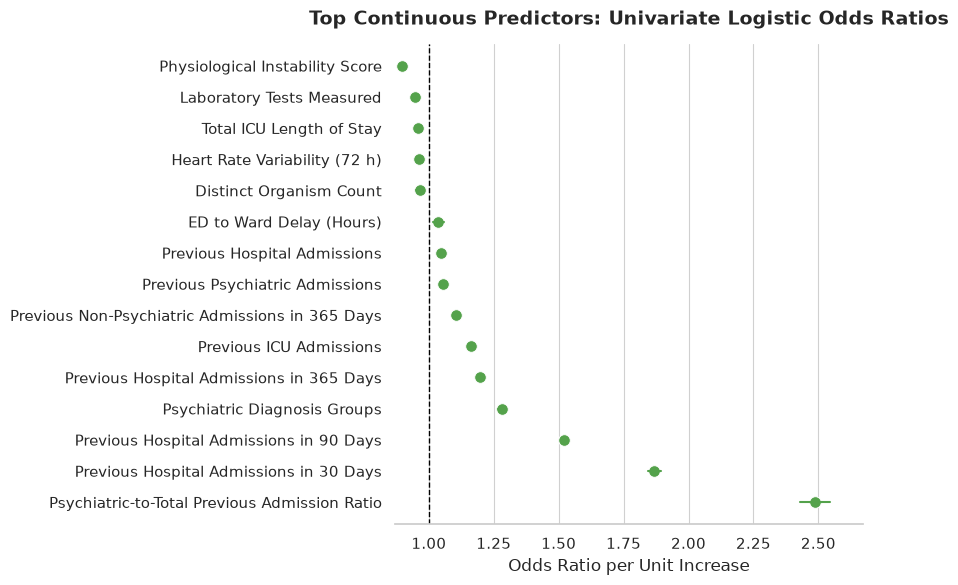

In [81]:
#plot significant continuous predictor odds ratios from univariate logistic screening
if not univariate_logistic_results.empty:
    plot_df = univariate_logistic_results.copy()
    plot_df["p_value_numeric"] = pd.to_numeric(
        plot_df["p-value"].astype(str).str.replace("<", "", regex=False), errors="coerce")

    plot_df = (plot_df.dropna(subset=["Odds Ratio per Unit Increase", "95% CI Lower", "95% CI Upper", "p_value_numeric"])
        .loc[lambda x: x["p_value_numeric"] < 0.05]
        .sort_values("Absolute log(OR)", ascending=False)
        .head(MAX_PLOT_FEATURES)
        .sort_values("Odds Ratio per Unit Increase", ascending=True))

    if plot_df.empty:
        print("No significant continuous predictors available for odds-ratio plotting.")
    else:
        fig, ax = plt.subplots(figsize=(8.5, 6))
        sns.scatterplot(data=plot_df, x="Odds Ratio per Unit Increase", y="Predictor",
            color="#54A24B", s=70, ax=ax)

        #draw the confidence interval for each odds ratio
        for _, row in plot_df.iterrows():
            ax.plot([row["95% CI Lower"], row["95% CI Upper"]], [row["Predictor"], row["Predictor"]],
                color="#54A24B", linewidth=1.5)

        #style the plot for report-friendly display
        ax.axvline(1, color="black", linestyle="--", linewidth=1)
        ax.set_title("Top Continuous Predictors: Univariate Logistic Odds Ratios", fontsize=14, weight="bold", pad=14)
        ax.set_xlabel("Odds Ratio per Unit Increase")
        ax.set_ylabel("")
        ax.set_xlim(max(0, plot_df["95% CI Lower"].min() * 0.98), plot_df["95% CI Upper"].max() * 1.05)
        ax.grid(axis="x", color="#d0d0d0", linewidth=0.8)
        ax.grid(axis="y", visible=False)
        sns.despine(left=True, bottom=False)
        plt.subplots_adjust(left=0.42, right=0.97, top=0.90, bottom=0.10)
        plt.show()
else:
    print("Univariate logistic regression results are empty, so no odds-ratio plot was produced.")


In [82]:
#summary of strongest results across the three association analyses
summary_rows = []
for _, row in chi_square_results_df.head(5).iterrows():
    summary_rows.append({"Predictor": row["Feature"], "Analysis": "Categorical association",
        "Statistic": "Cramer's V = {:.3f}".format(row["Cramer's V"])})

for _, row in odds_ratio_results_for_display.head(5).iterrows():
    summary_rows.append({"Predictor": row["Predictor"], "Analysis": "Binary odds ratio",
        "Statistic": "OR = {:.3f} (95% CI {:.3f}-{:.3f})".format(
            row["Odds Ratio"], row["95% CI Lower"], row["95% CI Upper"])})

for _, row in univariate_logistic_display.head(5).iterrows():
    summary_rows.append({"Predictor": row["Predictor"], "Analysis": "Univariate logistic regression",
        "Statistic": "OR = {:.4f} (95% CI {:.4f}-{:.4f})".format(
            row["Odds Ratio per Unit Increase"], row["95% CI Lower"], row["95% CI Upper"])})

exploratory_summary = pd.DataFrame(summary_rows)
print("Strongest results across association analyses:")
display(exploratory_summary)
save_table(exploratory_summary, "t2_4_exploratory_association_summary")


Strongest results across association analyses:


,Predictor,Analysis,Statistic
0,High Utiliser in Previous Year,Categorical association,Cramer's V = 0.219
1,Time Since Previous Psychiatric Admission,Categorical association,Cramer's V = 0.206
2,Previous Psychiatric Admission Within 90 Days,Categorical association,Cramer's V = 0.194
3,Previous Psychiatric Admission Within 365 Days,Categorical association,Cramer's V = 0.184
4,Previous Psychiatric Admission Within 30 Days,Categorical association,Cramer's V = 0.172
5,High Utiliser in Previous Year,Binary odds ratio,OR = 3.289 (95% CI 3.216-3.364)
6,Previous Psychiatric Admission Within 90 Days,Binary odds ratio,OR = 2.669 (95% CI 2.614-2.725)
7,Previous Psychiatric Admission Within 30 Days,Binary odds ratio,OR = 2.577 (95% CI 2.520-2.636)
8,Previous Psychiatric Admission Within 365 Days,Binary odds ratio,OR = 2.524 (95% CI 2.473-2.577)
9,Self-Harm or Suicidal Ideation,Binary odds ratio,OR = 2.447 (95% CI 2.371-2.525)


Added table to workbook sheet: t2_4_exploratory_association_su


't2_4_exploratory_association_su'

In [83]:
#concise strongest exploratory predictors table
strongest_predictor_rows = []
if "odds_ratio_results_for_display" in globals() and len(odds_ratio_results_for_display):
    for _, row in odds_ratio_results_for_display.head(5).iterrows():
        strongest_predictor_rows.append({"Variable": row["Predictor"],
            "Screening Method": "Odds ratio",
            "Result": f"OR {row['Odds Ratio']} ({row['95% CI Lower']}-{row['95% CI Upper']})"})

if "chi_square_results_df" in globals() and len(chi_square_results_df):
    for _, row in chi_square_results_df.head(5).iterrows():
        strongest_predictor_rows.append({"Variable": row["Feature"],
            "Screening Method": "Cramer's V", "Result": row["Cramer's V"]})

if "univariate_logistic_display" in globals() and len(univariate_logistic_display):
    for _, row in univariate_logistic_display.head(5).iterrows():
        strongest_predictor_rows.append({"Variable": row["Predictor"],
            "Screening Method": "Univariate logistic regression",
            "Result": f"OR {row['Odds Ratio per Unit Increase']}"})

strongest_exploratory_predictor_summary = pd.DataFrame(strongest_predictor_rows).drop_duplicates(subset=["Variable", "Screening Method"]).head(15)
print("Strongest exploratory predictors for transition into WP3:")
display(strongest_exploratory_predictor_summary)
save_table(strongest_exploratory_predictor_summary, "t2_4_strongest_exploratory_predictors_wp3_transition")


Strongest exploratory predictors for transition into WP3:


,Variable,Screening Method,Result
0,High Utiliser in Previous Year,Odds ratio,OR 3.289 (3.216-3.364)
1,Previous Psychiatric Admission Within 90 Days,Odds ratio,OR 2.669 (2.614-2.725)
2,Previous Psychiatric Admission Within 30 Days,Odds ratio,OR 2.577 (2.52-2.636)
3,Previous Psychiatric Admission Within 365 Days,Odds ratio,OR 2.524 (2.473-2.577)
4,Self-Harm or Suicidal Ideation,Odds ratio,OR 2.447 (2.371-2.525)
5,High Utiliser in Previous Year,Cramer's V,0.219
6,Time Since Previous Psychiatric Admission,Cramer's V,0.206
7,Previous Psychiatric Admission Within 90 Days,Cramer's V,0.194
8,Previous Psychiatric Admission Within 365 Days,Cramer's V,0.184
9,Previous Psychiatric Admission Within 30 Days,Cramer's V,0.172


Added table to workbook sheet: t2_4_strongest_exploratory_pred


't2_4_strongest_exploratory_pred'

In [84]:
#correlation matrix focused on clinical burden, utilisation, physiology, and body-measure features
clinical_correlation_features = existing_columns([
    "previous_total_admissions_365d", "previous_nonpsych_admissions_365d", "days_since_previous_hospital_admission_filled",
    "previous_icu_admissions", "psych_diagnosis_group_count", "num_nonpsych_diagnoses", "charlson_comorbidity_index_simple", "elixhauser_group_count_simple",
    "num_unique_drugs", "num_psych_med_classes", "administered_medication_count", "microbiology_test_count", "num_abnormal_labs",
    "physiological_instability_score", "first_72h_abnormal_hour_percent", "first_72h_max_instability_score",
    "total_icu_los_days", "ed_length_of_stay_hours", "bmi", "readmitted_30d"
])
clinical_corr_matrix = df[clinical_correlation_features].corr()
clinical_corr_matrix_labeled = clinical_corr_matrix.rename(index=feature_display_names, columns=feature_display_names)
clinical_corr_matrix_for_csv = clinical_corr_matrix_labeled.reset_index().rename(columns={"index": "Feature"})

print("Clinical burden, utilisation, physiology, and body-measure correlation matrix:")
display(clinical_corr_matrix_labeled)
save_table(clinical_corr_matrix_for_csv, "t2_4_clinical_burden_physiology_correlation_matrix")


Clinical burden, utilisation, physiology, and body-measure correlation matrix:


,Previous Hospital Admissions in 365 Days,Previous Non-Psychiatric Admissions in 365 Days,Days Since Previous Hospital Admission (Filled),Previous ICU Admissions,Psychiatric Diagnosis Groups,Non-Psychiatric Diagnoses,Unique Drugs Prescribed,Psychiatric Medication Classes,Microbiology Test Count,Abnormal Laboratory Tests,Physiological Instability Score,Total ICU Length of Stay,ED Length of Stay (Hours),30-Day Psychiatric Readmission
Previous Hospital Admissions in 365 Days,1.000000,0.388717,-0.146901,0.358076,0.028553,0.026423,-0.024737,0.012757,-0.011914,-0.001553,-0.067325,-0.045494,0.000533,0.256048
Previous Non-Psychiatric Admissions in 365 Days,0.388717,1.000000,-0.091371,0.202228,-0.104372,0.160756,0.104202,0.031831,0.047087,0.136216,-0.007079,-0.001155,-0.062415,0.043851
Days Since Previous Hospital Admission (Filled),-0.146901,-0.091371,1.000000,-0.028339,0.001524,0.056499,0.000860,-0.003356,-0.024815,-0.000215,-0.017459,-0.013285,0.057999,-0.055445
Previous ICU Admissions,0.358076,0.202228,-0.028339,1.000000,0.008318,0.211266,0.130068,0.067970,0.049477,0.160427,0.071409,0.033164,-0.036919,0.102188
Psychiatric Diagnosis Groups,0.028553,-0.104372,0.001524,0.008318,1.000000,-0.024008,-0.016830,0.214764,-0.014949,-0.079326,-0.012612,-0.008936,0.165820,0.084702
Non-Psychiatric Diagnoses,0.026423,0.160756,0.056499,0.211266,-0.024008,1.000000,0.711838,0.340639,0.383787,0.696117,0.396893,0.329002,-0.180717,-0.025295
Unique Drugs Prescribed,-0.024737,0.104202,0.000860,0.130068,-0.016830,0.711838,1.000000,0.511758,0.552797,0.770398,0.589584,0.538287,-0.291843,-0.045154
Psychiatric Medication Classes,0.012757,0.031831,-0.003356,0.067970,0.214764,0.340639,0.511758,1.000000,0.197200,0.354492,0.188885,0.172379,-0.178750,-0.004136
Microbiology Test Count,-0.011914,0.047087,-0.024815,0.049477,-0.014949,0.383787,0.552797,0.197200,1.000000,0.402533,0.369926,0.595903,-0.107858,-0.008981
Abnormal Laboratory Tests,-0.001553,0.136216,-0.000215,0.160427,-0.079326,0.696117,0.770398,0.354492,0.402533,1.000000,0.464926,0.334894,-0.287039,-0.024335


Added table to workbook sheet: t2_4_clinical_burden_physiology


't2_4_clinical_burden_physiology'

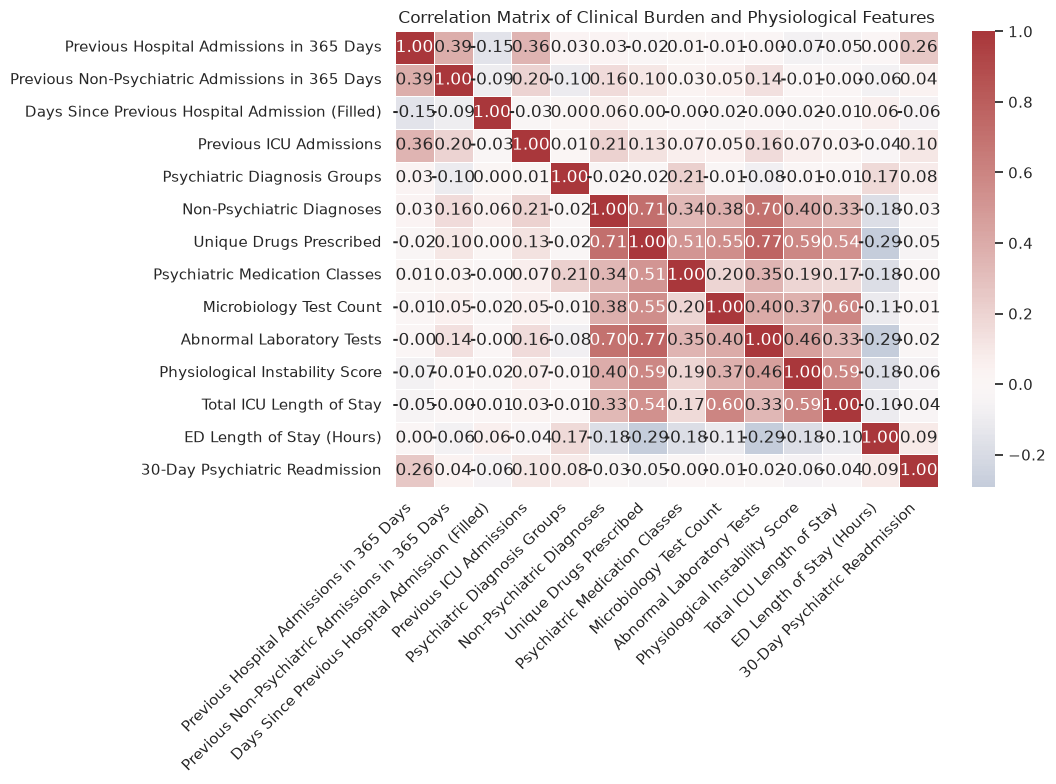

In [85]:
#plot clinical burden and physiological feature correlation matrix
plt.figure(figsize=(11, 8))
sns.heatmap(clinical_corr_matrix_labeled, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Clinical Burden and Physiological Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [86]:

#variance inflation factors for selected numerical predictors
#vif is applied to a curated numeric feature set to avoid ids, dates, categorical variables, and duplicate encodings.
#high-missingness variables are excluded from this diagnostic, and remaining missing values are median-imputed for stability.
vif_features = existing_columns([
    "anchor_age", "hospital_los_days", "previous_total_admissions_365d", "previous_nonpsych_admissions_365d",
    "days_since_previous_hospital_admission_filled", "previous_icu_admissions", "previous_psych_to_total_admission_ratio",
    "psych_diagnosis_group_count", "num_nonpsych_diagnoses", "charlson_comorbidity_index_simple", "elixhauser_group_count_simple",
    "num_unique_drugs", "num_psych_med_classes", "administered_medication_count", "microbiology_test_count", "num_abnormal_labs",
    "physiological_instability_score", "first_72h_abnormal_hour_percent", "first_72h_max_instability_score",
    "total_icu_los_days", "ed_length_of_stay_hours", "bmi"])

vif_data = df[vif_features].replace([np.inf, -np.inf], np.nan).copy()
minimum_non_missing_fraction = 0.20
vif_data = vif_data.loc[:, vif_data.notna().mean() >= minimum_non_missing_fraction]
vif_data = vif_data.fillna(vif_data.median(numeric_only=True))
vif_data = vif_data.loc[:, vif_data.std(ddof=0) > 0]

#standardise to improve numerical stability; vif is unchanged by linear scaling
vif_scaled = (vif_data - vif_data.mean()) / vif_data.std(ddof=0)

#calculate vif
def calculate_vif(matrix, target_index):
    y = matrix[:, target_index]
    X = np.delete(matrix, target_index, axis=1)
    X = np.column_stack([np.ones(X.shape[0]), X])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    return 1 / (1 - r_squared) if r_squared < 1 else np.inf

if vif_scaled.shape[1] >= 2:
    vif_matrix = vif_scaled.to_numpy()
    vif_results = pd.DataFrame({"Feature": [display_name(col) for col in vif_scaled.columns],
        "VIF": [calculate_vif(vif_matrix, i) for i in range(vif_matrix.shape[1])]
    }).sort_values("VIF", ascending=False)
    vif_results["VIF"] = vif_results["VIF"].round(2)
else:
    vif_results = pd.DataFrame(columns=["Feature", "VIF"])

print("Variance inflation factors for selected numerical predictors:")
display(vif_results)
save_table(vif_results, "t2_4_variance_inflation_factors_selected_numerical_predictors")


Variance inflation factors for selected numerical predictors:


,Feature,VIF
9,Unique Drugs Prescribed,5.36
12,Abnormal Laboratory Tests,2.94
8,Non-Psychiatric Diagnoses,2.63
14,Total ICU Length of Stay,2.22
1,Hospital Length of Stay,2.15
11,Microbiology Test Count,1.97
13,Physiological Instability Score,1.96
2,Previous Hospital Admissions in 365 Days,1.58
10,Psychiatric Medication Classes,1.57
0,Age,1.35


Added table to workbook sheet: t2_4_variance_inflation_factors


't2_4_variance_inflation_factors'

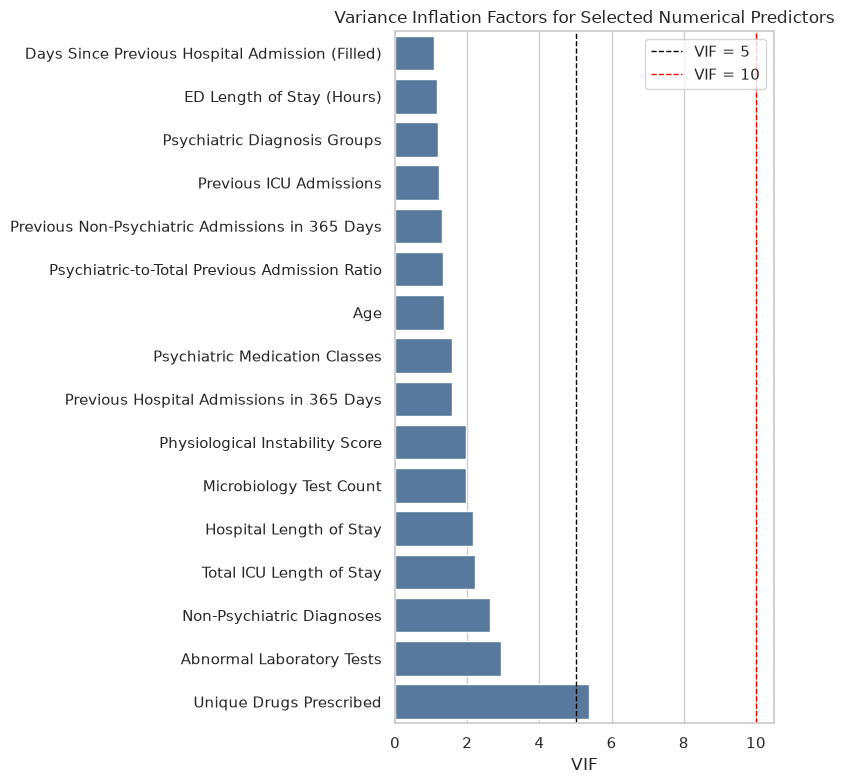

In [87]:
#plot variance inflation factors for selected numerical predictors
plt.figure(figsize=(8, 8))
sns.barplot(data=vif_results.sort_values("VIF", ascending=True), x="VIF", y="Feature", color="#4C78A8")
plt.axvline(5, color="black", linestyle="--", linewidth=1, label="VIF = 5")
plt.axvline(10, color="red", linestyle="--", linewidth=1, label="VIF = 10")

plt.title("Variance Inflation Factors for Selected Numerical Predictors")
plt.xlabel("VIF")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
#summarise numerical feature redundancy from correlation and vif screening
predictor_corr_matrix = corr_matrix_labeled.drop(index="30-Day Psychiatric Readmission", columns="30-Day Psychiatric Readmission", errors="ignore")
upper_corr = predictor_corr_matrix.where(np.triu(np.ones(predictor_corr_matrix.shape), k=1).astype(bool))
strong_corr_pairs = (upper_corr.abs().stack().reset_index())
strong_corr_pairs.columns = ["Feature 1", "Feature 2", "Absolute Correlation"]
strong_corr_pairs = strong_corr_pairs.sort_values("Absolute Correlation", ascending=False)
near_perfect_corr_pairs = strong_corr_pairs[strong_corr_pairs["Absolute Correlation"] >= 0.90]

redundancy_summary = pd.DataFrame({
    "Check": ["Highest absolute pairwise numerical correlation", "Pairs with absolute correlation >= 0.90", "Highest VIF", "Predictors with VIF >= 10"],
    "Value": [round(strong_corr_pairs["Absolute Correlation"].iloc[0], 3) if len(strong_corr_pairs) else np.nan,
        len(near_perfect_corr_pairs),
        round(vif_results["VIF"].max(), 2) if len(vif_results) else np.nan,
        int((vif_results["VIF"] >= 10).sum()) if len(vif_results) else 0]})

print("Numerical feature redundancy summary:")
display(redundancy_summary)
save_table(redundancy_summary, "t2_4_numerical_feature_redundancy_summary")

print("Strongest numerical feature correlations:")
display(strong_corr_pairs.head(10))
save_table(strong_corr_pairs.head(10), "t2_4_strongest_numerical_feature_correlations")


Numerical feature redundancy summary:


,Check,Value
0,Highest absolute pairwise numerical correlation,0.965
1,Pairs with absolute correlation >= 0.90,1.000
2,Highest VIF,5.360
3,Predictors with VIF >= 10,0.000


Added table to workbook sheet: t2_4_numerical_feature_redundan
Strongest numerical feature correlations:


,Feature 1,Feature 2,Absolute Correlation
85,Previous Psychiatric Admissions,Previous Hospital Admissions,0.965317
141,Previous Hospital Admissions in 30 Days,Previous Hospital Admissions in 90 Days,0.793376
169,Previous Hospital Admissions in 90 Days,Previous Hospital Admissions in 365 Days,0.790320
421,Transfer Events,Unique Care Units,0.789879
536,Unique Drugs Prescribed,Abnormal Laboratory Tests,0.770398
589,Microbiology Test Count,Distinct Organism Count,0.755578
115,Previous Hospital Admissions,Previous Hospital Admissions in 365 Days,0.732577
88,Previous Psychiatric Admissions,Previous Hospital Admissions in 365 Days,0.717606
397,Non-Psychiatric Diagnoses,Unique Drugs Prescribed,0.711838
401,Non-Psychiatric Diagnoses,Abnormal Laboratory Tests,0.696117


Added table to workbook sheet: t2_4_strongest_numerical_featur


't2_4_strongest_numerical_featur'

In [89]:
#interpret numerical feature redundancy screening
max_vif = vif_results["VIF"].max() if len(vif_results) else np.nan
near_perfect_pairs = len(near_perfect_corr_pairs) if "near_perfect_corr_pairs" in globals() else 0

if near_perfect_pairs == 0 and (pd.isna(max_vif) or max_vif < 10):
    redundancy_interpretation = "No evidence of problematic multicollinearity was observed among the selected engineered numerical variables."
else:
    redundancy_interpretation = "Some numerical predictors showed potential redundancy and should be reviewed during modelling."

redundancy_interpretation_table = pd.DataFrame({"Interpretation": [redundancy_interpretation]})
print("Numerical redundancy interpretation:")
display(redundancy_interpretation_table)
save_table(redundancy_interpretation_table, "t2_4_numerical_redundancy_interpretation")


Numerical redundancy interpretation:


,Interpretation
0,Some numerical predictors showed potential red...


Added table to workbook sheet: t2_4_numerical_redundancy_inter


't2_4_numerical_redundancy_inter'

#### **T2.4.10 - Engineered feature domains**

This section gives a concise descriptive audit of engineered predictor groups, focusing on coverage, prevalence, and simple readmission-rate contrasts. The aim is to understand what the variables represent before WP3 modelling, not to treat these univariate summaries as final model evidence.

In [90]:
#summarise engineered feature families represented in the admission-level dataset
engineered_feature_family_map = {
    "Prior utilisation and admission history": [
        *[f"previous_total_admissions_{days}d" for days in [7, 14, 30, 60, 90, 180, 365]],
        *[f"previous_psych_admissions_{days}d" for days in [7, 14, 30, 60, 90, 180, 365]],
        *[f"previous_nonpsych_admissions_{days}d" for days in [7, 14, 30, 60, 90, 180, 365]],
        *[f"previous_ed_visits_{days}d" for days in [7, 14, 30, 60, 90, 180, 365]],
        *[f"previous_icu_admissions_{days}d" for days in [7, 14, 30, 60, 90, 180, 365]],
        *[f"recent_icu_admission_{days}d_flag" for days in [7, 14, 30, 60, 90, 180, 365]],
        "days_since_previous_hospital_admission_filled", "days_since_previous_psych_admission_filled",
        "admissions_per_30d", "admissions_per_90d", "admissions_per_365d", "admission_frequency_acceleration",
        "frequent_ed_user_flag", "prior_ed_only_high_use_flag", "previous_psych_to_total_admission_ratio",
        "frequent_psych_admitter_flag"],
    "POE and near-discharge order activity": [
        "num_total_poe_orders", "num_orders_first_6h", "num_orders_first_12h", "num_orders_first_24h",
        "num_orders_first_72h", "orders_after_72h_count", "orders_last_24h_before_discharge",
        "orders_last_12h_before_discharge", "orders_last_6h_before_discharge", "new_orders_last_12h_before_discharge_flag",
        "last_order_close_to_discharge_hours", "order_activity_duration_hours", "late_order_activity_flag",
        "late_order_intensity_score_last_12h", "late_order_type_diversity_last_12h", "late_order_severity_score_last_12h"],
    "Aftercare and discharge planning": [
        "had_followup_or_outpatient_referral_order", "had_discharge_planning_order", "num_discharge_planning_orders",
        "discharge_planning_first_72h_flag", "late_discharge_planning_after_72h_flag", "had_psych_followup_order",
        "had_outpatient_followup_order", "had_case_management_order", "num_followup_related_orders",
        "followup_order_last_24h_before_discharge", "protective_aftercare_present_flag", "aftercare_quality_score",
        "low_aftercare_quality_flag", "home_discharge_without_followup_order_flag"],
    "Safety observation and psychiatric acuity orders": [
        "had_sitter_or_constant_observation_order", "had_suicide_precaution_order", "had_elopement_precaution_order",
        "had_restraint_order", "had_sitter_order", "had_constant_observation_order", "had_behavioral_observation_order",
        "num_safety_observation_orders", "safety_orders_first_24h", "safety_orders_first_72h", "safety_orders_last_24h_before_discharge",
        "safety_orders_last_12h_before_discharge", "safety_order_near_discharge_flag", "safety_order_density_per_day"],
    "Care-team and pathway complexity": [
        "num_unique_order_providers_first_24h", "num_unique_order_providers_first_72h", "num_order_provider_changes",
        "num_unique_services_during_admission", "service_change_count", "careunit_change_count", "service_or_careunit_change_flag",
        "care_team_touchpoints_last_24h_before_discharge", "care_team_touchpoints_last_12h_before_discharge",
        "care_team_touchpoints_last_6h_before_discharge", "care_team_touchpoints_per_hospital_day", "late_care_fragmentation_score"],
    "Medication, pharmacy, and EMAR process": [
        "num_pharmacy_records", "num_unique_pharmacy_medications", "num_iv_pharmacy_orders", "num_prn_pharmacy_orders",
        "num_scheduled_pharmacy_orders", "num_prn_psychotropic_orders", "num_scheduled_psychotropic_orders",
        "psychotropic_order_density_per_day", "psychotropic_medication_change_count", "late_psychotropic_change_flag",
        "psychotropic_orders_last_24h_before_discharge", "late_medication_change_intensity_score", "emar_not_given_rate"],
    "Laboratory and medical workup activity": [
        "num_lab_events_first_24h", "num_lab_events_first_72h", "num_lab_events_last_24h_before_discharge",
        "num_lab_events_last_48h_before_discharge", "num_abnormal_lab_flags", "num_abnormal_lab_flags_last_48h",
        "num_critical_or_priority_labs", "lab_activity_near_discharge_flag", "abnormal_lab_burden_score",
        "medical_workup_near_discharge_score", "late_lab_activity_without_followup_flag"],
    "Body measures and medical complexity": [
        "latest_bmi_before_admission", "latest_weight_kg_before_admission", "days_since_latest_body_measure_filled",
        "bmi_change_recent_filled", "weight_change_recent_filled", "underweight_or_weight_loss_flag", "medical_complexity_score",
        "older_medical_complexity_score", "medical_complexity_without_prior_psych_flag", "quiet_medical_frailty_low_psych_history_score"],
    "Targeted interaction and quiet-risk flags": [
        "low_order_activity_with_self_harm_flag", "low_order_activity_with_smi_flag", "low_order_activity_with_psychosis_flag",
        "low_order_activity_with_recent_psych_admission_flag", "no_late_orders_but_self_harm_flag", "self_harm_without_followup_order_flag",
        "psychosis_without_followup_order_flag", "late_orders_but_followup_present_flag", "late_orders_but_supervised_discharge_flag",
        "quiet_risk_summary_score", "quiet_risk_flag", "quiet_home_discharge_psych_risk_flag"],
    "Discharge continuity and mixed-risk phenotype": [
        "discharge_medication_continuity_score", "psychiatric_aftercare_planning_score",
        "unmanaged_psychiatric_discharge_risk_score", "psychosis_without_antipsychotic_continuity_flag",
        "bipolar_without_mood_stabiliser_continuity_flag", "depression_without_antidepressant_continuity_flag",
        "smi_without_psychotropic_continuity_flag", "self_harm_without_aftercare_or_safety_plan_flag",
        "substance_use_without_followup_or_withdrawal_plan_flag", "late_medication_change_without_discharge_med_plan_flag",
        "home_discharge_without_medication_or_followup_plan_flag", "psychotropic_change_with_aftercare_plan_flag",
        "psychotropic_change_without_aftercare_plan_flag", "prior_ed_only_use_with_current_self_harm_flag",
        "prior_ed_only_use_with_current_smi_flag", "prior_ed_only_use_with_current_psychosis_flag",
        "prior_ed_only_use_with_substance_use_flag", "ed_heavy_low_inpatient_psych_history_flag",
        "ed_heavy_home_discharge_no_followup_flag", "ed_only_crisis_pattern_score",
        "older_medical_complexity_home_discharge_flag", "medical_complexity_no_aftercare_flag",
        "medical_complexity_late_workup_home_discharge_flag", "low_psych_marker_medical_instability_flag",
        "icu_or_procedure_without_psych_marker_flag"]}

engineered_family_rows = []
engineered_feature_rows = []
engineered_missing_feature_rows = []
#loop through each item in this feature block
for family, features in engineered_feature_family_map.items():
    present_features = existing_columns(features)
    missing_features = [feature for feature in features if feature not in df.columns]
    engineered_family_rows.append({"Feature family": family,
        "Candidate features listed": len(features),
        "Features present in dataset": len(present_features),
        "Missing listed features": len(missing_features),
        "Example present features": ", ".join(present_features[:6]),
        "Example missing listed features": ", ".join(missing_features[:6])})
    #loop through each item in this feature block
    for feature in missing_features:
        engineered_missing_feature_rows.append({"Feature family": family, "Missing listed feature": feature,
            "Display label": display_name(feature)})
    for feature in present_features:
        series = pd.to_numeric(df[feature], errors="coerce") if pd.api.types.is_numeric_dtype(df[feature]) else df[feature]
        nonmissing = int(series.notna().sum())
        missing_percent = round(series.isna().mean() * 100, 2)
        if pd.api.types.is_numeric_dtype(series):
            nonzero_mask = series.fillna(0) != 0
            nonzero_percent = round(nonzero_mask.mean() * 100, 2)
            if nonzero_mask.sum() >= 30 and (~nonzero_mask).sum() >= 30:
                rate_nonzero = df.loc[nonzero_mask, "readmitted_30d"].mean() * 100
                rate_zero = df.loc[~nonzero_mask, "readmitted_30d"].mean() * 100
                rate_difference = rate_nonzero - rate_zero
            else:
                rate_nonzero = np.nan
                rate_zero = np.nan
                rate_difference = np.nan
            engineered_feature_rows.append({"Feature family": family, "Feature": display_name(feature), "Raw feature": feature,
                "Non-missing admissions": nonmissing, "Missing (%)": missing_percent,
                "Non-zero / true (%)": nonzero_percent, "Readmission rate when non-zero/true (%)": round(rate_nonzero, 2) if pd.notna(rate_nonzero) else np.nan,
                "Readmission rate when zero/false (%)": round(rate_zero, 2) if pd.notna(rate_zero) else np.nan,
                "Rate difference (percentage points)": round(rate_difference, 2) if pd.notna(rate_difference) else np.nan,
                "Mean": round(series.mean(), 4) if series.notna().any() else np.nan,
                "Median": round(series.median(), 4) if series.notna().any() else np.nan})
        else:
            engineered_feature_rows.append({"Feature family": family, "Feature": display_name(feature), "Raw feature": feature,
                "Non-missing admissions": nonmissing, "Missing (%)": missing_percent,
                "Non-zero / true (%)": np.nan, "Readmission rate when non-zero/true (%)": np.nan,
                "Readmission rate when zero/false (%)": np.nan, "Rate difference (percentage points)": np.nan,
                "Mean": np.nan, "Median": np.nan})

engineered_feature_family_summary = pd.DataFrame(engineered_family_rows)
engineered_feature_summary = (pd.DataFrame(engineered_feature_rows)
    .sort_values(["Feature family", "Rate difference (percentage points)"], ascending=[True, False])
    .reset_index(drop=True))
engineered_missing_feature_summary = pd.DataFrame(engineered_missing_feature_rows)

print("Engineered feature-family coverage:")
display(engineered_feature_family_summary)
print("Engineered feature prevalence and univariate readmission-rate contrasts:")
display(top_display(engineered_feature_summary.sort_values("Rate difference (percentage points)", ascending=False), 25))
save_table(engineered_feature_family_summary, "t2_4_engineered_feature_family_coverage")
save_table(engineered_feature_summary, "t2_4_engineered_feature_prevalence_and_readmission_rates")
save_table(engineered_missing_feature_summary, "t2_4_engineered_feature_family_missing_listed_features")


Engineered feature-family coverage:


,Feature family,Candidate features listed,Features present in dataset,Missing listed features,Example present features,Example missing listed features
0,Prior utilisation and admission history,52,52,0,"previous_total_admissions_7d, previous_total_a...",
1,POE and near-discharge order activity,16,16,0,"num_total_poe_orders, num_orders_first_6h, num...",
2,Aftercare and discharge planning,14,14,0,"had_followup_or_outpatient_referral_order, had...",
3,Safety observation and psychiatric acuity orders,14,14,0,"had_sitter_or_constant_observation_order, had_...",
4,Care-team and pathway complexity,12,12,0,"num_unique_order_providers_first_24h, num_uniq...",
5,"Medication, pharmacy, and EMAR process",13,13,0,"num_pharmacy_records, num_unique_pharmacy_medi...",
6,Laboratory and medical workup activity,11,11,0,"num_lab_events_first_24h, num_lab_events_first...",
7,Body measures and medical complexity,10,10,0,"latest_bmi_before_admission, latest_weight_kg_...",
8,Targeted interaction and quiet-risk flags,12,12,0,"low_order_activity_with_self_harm_flag, low_or...",
9,Discharge continuity and mixed-risk phenotype,25,25,0,"discharge_medication_continuity_score, psychia...",


Engineered feature prevalence and univariate readmission-rate contrasts:


,Feature family,Feature,Raw feature,Non-missing admissions,Missing (%),Non-zero / true (%),Readmission rate when non-zero/true (%),Readmission rate when zero/false (%),Rate difference (percentage points),Mean,Median
168,Targeted interaction and quiet-risk flags,No Late Orders But Self Harm,no_late_orders_but_self_harm_flag,238491,0.0,1.98,86.76,18.50,68.25,0.0198,0.0
167,Targeted interaction and quiet-risk flags,Low Order Activity With Self Harm,low_order_activity_with_self_harm_flag,238491,0.0,1.98,86.76,18.50,68.25,0.0198,0.0
169,Targeted interaction and quiet-risk flags,Low Order Activity With Psychosis,low_order_activity_with_psychosis_flag,238491,0.0,1.26,83.93,19.04,64.89,0.0126,0.0
170,Targeted interaction and quiet-risk flags,Low Order Activity With SMI,low_order_activity_with_smi_flag,238491,0.0,2.08,79.88,18.58,61.30,0.0208,0.0
171,Targeted interaction and quiet-risk flags,Low Order Activity With Recent Psych Admission,low_order_activity_with_recent_psych_admission...,238491,0.0,2.45,64.51,18.74,45.77,0.0245,0.0
172,Targeted interaction and quiet-risk flags,Quiet-Risk Flag,quiet_risk_flag,238491,0.0,8.89,50.61,16.86,33.75,0.0889,0.0
36,Discharge continuity and mixed-risk phenotype,Self Harm Without Aftercare Or Safety Plan,self_harm_without_aftercare_or_safety_plan_flag,238491,0.0,2.65,46.66,19.13,27.54,0.0265,0.0
37,Discharge continuity and mixed-risk phenotype,Psychosis Without Antipsychotic Continuity,psychosis_without_antipsychotic_continuity_flag,238491,0.0,3.22,39.30,19.21,20.09,0.0322,0.0
38,Discharge continuity and mixed-risk phenotype,SMI Without Psychotropic Continuity,smi_without_psychotropic_continuity_flag,238491,0.0,4.81,38.80,18.90,19.90,0.0481,0.0
101,Prior utilisation and admission history,Frequent ED User,frequent_ed_user_flag,238491,0.0,23.12,34.64,15.41,19.23,0.2312,0.0


Added table to workbook sheet: t2_4_engineered_feature_family_
Added table to workbook sheet: t2_4_engineered_feature_prevale
Added table to workbook sheet: t2_4_engineered_feature_famil_2


't2_4_engineered_feature_famil_2'

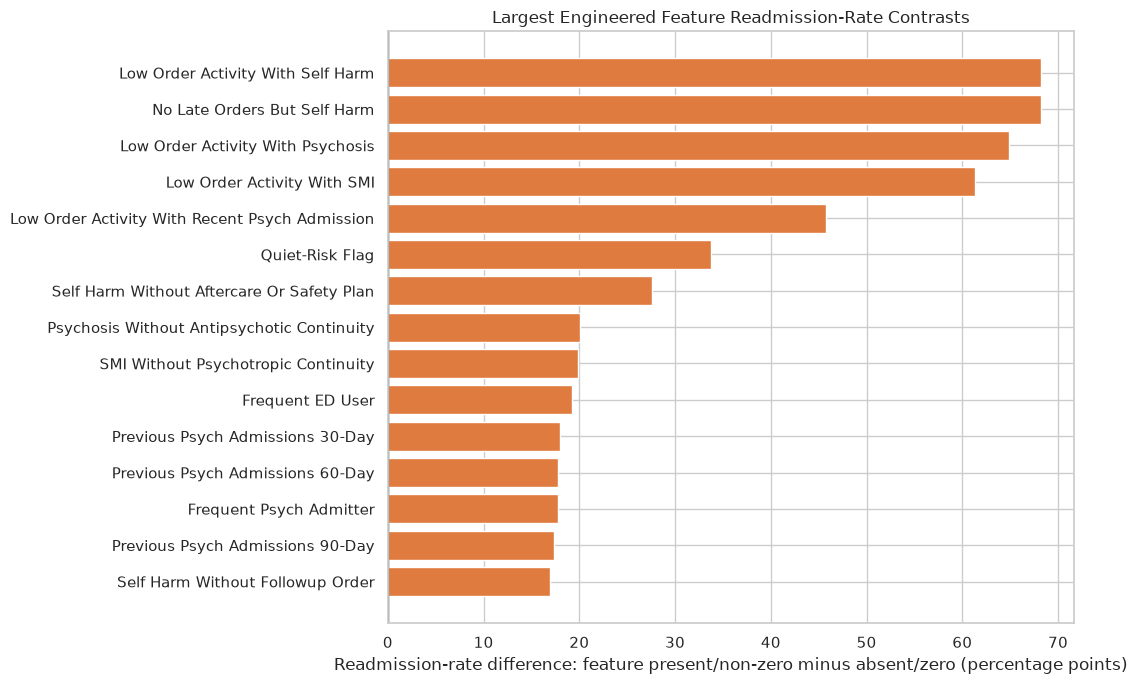

In [91]:
#plot strongest readmission-rate contrasts among binary or sparse engineered features
plot_engineered_binary_features = (engineered_feature_summary
    .dropna(subset=["Rate difference (percentage points)"])
    .loc[lambda x: x["Non-zero / true (%)"].between(0.5, 99.5)]
    .sort_values("Rate difference (percentage points)", ascending=False)
    .head(MAX_PLOT_FEATURES)
    .sort_values("Rate difference (percentage points)", ascending=True))

if plot_engineered_binary_features.empty:
    print("No eligible engineered binary/sparse features available for plotting.")
else:
    plt.figure(figsize=(11, 7))
    colours = np.where(plot_engineered_binary_features["Rate difference (percentage points)"] >= 0, "#E07B3F", "#3F6FB5")
    plt.barh(plot_engineered_binary_features["Feature"], plot_engineered_binary_features["Rate difference (percentage points)"], color=colours)
    plt.axvline(0, color="#555555", linewidth=1)
    plt.xlabel("Readmission-rate difference: feature present/non-zero minus absent/zero (percentage points)")
    plt.ylabel("")
    plt.title("Largest Engineered Feature Readmission-Rate Contrasts")
    plt.tight_layout()
    plt.show()


#### **T2.4.11 - Near-discharge activity and care-transition EDA**

Several variables describe whether orders, care-team activity, medication changes, laboratory activity, or aftercare planning are still occurring close to discharge. This section summarises those variables directly because they describe the care-transition period rather than the admission baseline alone.

In [92]:
#rank near-discharge and care-transition continuous features by outcome separation
near_discharge_features = existing_columns([
    "orders_last_24h_before_discharge", "orders_last_12h_before_discharge", "orders_last_6h_before_discharge",
    "last_order_close_to_discharge_hours", "order_activity_last_24h_to_total_ratio", "order_activity_last_12h_to_total_ratio",
    "late_order_intensity_score_last_12h", "late_order_severity_score_last_12h", "late_order_type_diversity_last_12h",
    "discontinued_orders_last_12h_before_discharge", "late_order_discontinuation_share",
    "care_team_touchpoints_last_24h_before_discharge", "care_team_touchpoints_last_12h_before_discharge",
    "care_team_touchpoints_last_6h_before_discharge", "late_care_fragmentation_score",
    "num_lab_events_last_24h_before_discharge", "num_lab_events_last_48h_before_discharge",
    "abnormal_labs_last_24h_before_discharge", "medical_workup_near_discharge_score",
    "psychotropic_orders_last_24h_before_discharge", "late_medication_change_intensity_score",
    "safety_orders_last_24h_before_discharge", "safety_orders_last_12h_before_discharge",
    "aftercare_quality_score", "quiet_risk_summary_score",
    "discharge_medication_continuity_score", "psychiatric_aftercare_planning_score",
    "unmanaged_psychiatric_discharge_risk_score", "late_medication_change_without_discharge_med_plan_flag",
    "home_discharge_without_medication_or_followup_plan_flag", "psychotropic_change_without_aftercare_plan_flag",
    "medical_complexity_late_workup_home_discharge_flag", "ed_only_crisis_pattern_score",])

near_discharge_rows = []
for feature in near_discharge_features:
    series = pd.to_numeric(df[feature], errors="coerce")
    non_readmitted = series[df["readmitted_30d"] == 0].dropna()
    readmitted = series[df["readmitted_30d"] == 1].dropna()
    if non_readmitted.empty or readmitted.empty:
        continue
    pooled_std = series.std()
    mean_difference = readmitted.mean() - non_readmitted.mean()
    near_discharge_rows.append({"Feature": display_name(feature), "Raw feature": feature,
        "Non-readmitted median": non_readmitted.median(), "Readmitted median": readmitted.median(),
        "Non-readmitted mean": non_readmitted.mean(), "Readmitted mean": readmitted.mean(),
        "Mean difference": mean_difference,
        "Standardised mean difference": mean_difference / pooled_std if pooled_std and pooled_std > 0 else np.nan,
        "Non-missing admissions": int(series.notna().sum()), "Missing (%)": series.isna().mean() * 100})

near_discharge_contrast = (pd.DataFrame(near_discharge_rows)
    .assign(**{"Absolute standardised mean difference": lambda x: x["Standardised mean difference"].abs()})
    .sort_values("Absolute standardised mean difference", ascending=False)
    .reset_index(drop=True))

print("Near-discharge and care-transition feature contrast by readmission outcome:")
display(top_display(near_discharge_contrast))
save_table(near_discharge_contrast.round(4), "t2_4_near_discharge_activity_contrast")


Near-discharge and care-transition feature contrast by readmission outcome:


,Feature,Raw feature,Non-readmitted median,Readmitted median,Non-readmitted mean,Readmitted mean,Mean difference,Standardised mean difference,Non-missing admissions,Missing (%),Absolute standardised mean difference
0,Quiet-Risk Summary Score,quiet_risk_summary_score,2.000000,2.000000,2.246111,3.425018,1.178907,0.607151,238491,0.0,0.607151
1,Final Order Discontinuation Share,late_order_discontinuation_share,1.000000,1.000000,0.963026,0.857325,-0.105701,-0.452411,238491,0.0,0.452411
2,Unmanaged Psychiatric Discharge Risk Score,unmanaged_psychiatric_discharge_risk_score,2.000000,3.000000,2.492212,2.936526,0.444314,0.380292,238491,0.0,0.380292
3,Late Care Fragmentation Score,late_care_fragmentation_score,3.966200,3.276355,4.405216,3.541066,-0.864150,-0.320144,238491,0.0,0.320144
4,Care-Team Touchpoints in Final 12 Hours,care_team_touchpoints_last_12h_before_discharge,1.000000,1.000000,1.293859,1.048410,-0.245449,-0.296673,238491,0.0,0.296673
5,Care-Team Touchpoints in Final 6 Hours,care_team_touchpoints_last_6h_before_discharge,0.857143,0.666667,0.898429,0.721556,-0.176873,-0.279825,238491,0.0,0.279825
6,Care-Team Touchpoints in Final 24 Hours,care_team_touchpoints_last_24h_before_discharge,2.000000,2.000000,2.013634,1.685903,-0.327731,-0.276738,238491,0.0,0.276738
7,Final 12-Hour Order Type Diversity,late_order_type_diversity_last_12h,2.000000,2.000000,2.348993,1.947654,-0.401339,-0.268852,238491,0.0,0.268852
8,Aftercare Quality Score,aftercare_quality_score,2.000000,2.000000,2.083905,1.814245,-0.269660,-0.241367,238491,0.0,0.241367
9,Final 12-Hour Order Intensity Score,late_order_intensity_score_last_12h,10.857143,9.000000,13.524306,10.758374,-2.765931,-0.224660,238491,0.0,0.224660


Added table to workbook sheet: t2_4_near_discharge_activity_co


't2_4_near_discharge_activity_co'

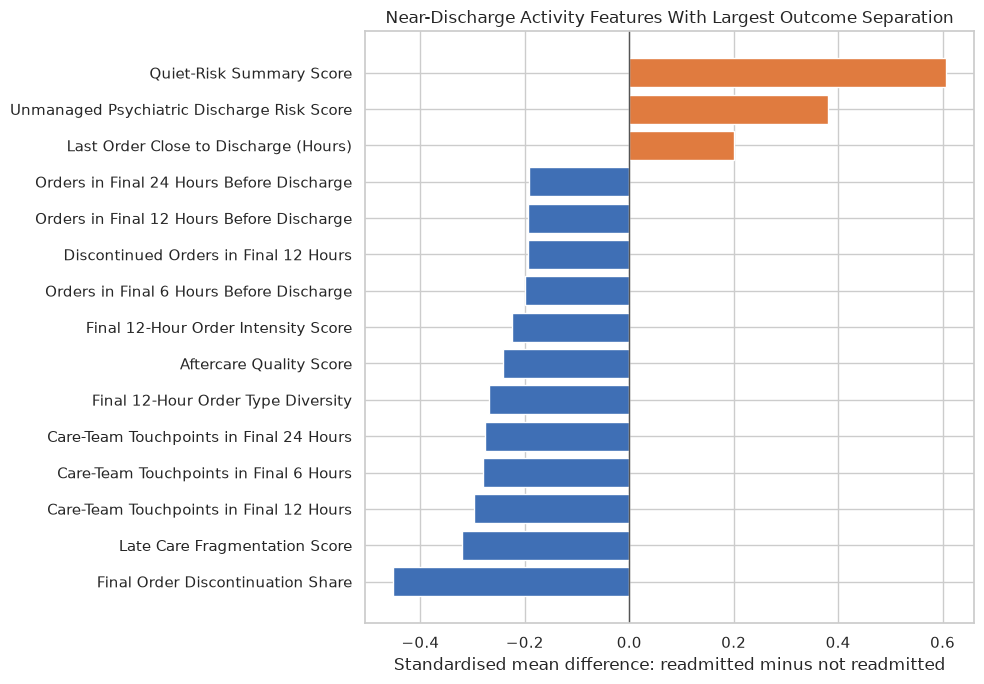

In [93]:
#plot near-discharge features with the clearest readmitted/non-readmitted separation
plot_near_discharge = near_discharge_contrast.head(MAX_PLOT_FEATURES).sort_values("Standardised mean difference", ascending=True)
if plot_near_discharge.empty:
    print("No eligible near-discharge features available for plotting.")
else:
    plt.figure(figsize=(10, 7))
    colours = np.where(plot_near_discharge["Standardised mean difference"] >= 0, "#E07B3F", "#3F6FB5")
    plt.barh(plot_near_discharge["Feature"], plot_near_discharge["Standardised mean difference"], color=colours)
    plt.axvline(0, color="#555555", linewidth=1)
    plt.xlabel("Standardised mean difference: readmitted minus not readmitted")
    plt.ylabel("")
    plt.title("Near-Discharge Activity Features With Largest Outcome Separation")
    plt.tight_layout()
    plt.show()


In [94]:
#readmission-rate summaries across binned near-discharge activity measures
near_discharge_bin_features = existing_columns([
    "orders_last_12h_before_discharge", "late_order_intensity_score_last_12h", "last_order_close_to_discharge_hours",
    "care_team_touchpoints_last_12h_before_discharge", "medical_workup_near_discharge_score", "aftercare_quality_score",
    "quiet_risk_summary_score"])

near_discharge_bin_tables = []
for feature in near_discharge_bin_features:
    temp = df[[feature, "readmitted_30d"]].copy()
    temp[feature] = pd.to_numeric(temp[feature], errors="coerce")
    temp = temp.dropna(subset=[feature])
    if temp[feature].nunique() < 3:
        continue
    try:
        temp["Feature band"] = pd.qcut(temp[feature], q=4, duplicates="drop")
    except ValueError:
        continue
    if temp["Feature band"].nunique() < 2:
        continue
    band_summary = (temp.groupby("Feature band", observed=False)
        .agg(Admissions=("readmitted_30d", "size"), Readmissions=("readmitted_30d", "sum"), Readmission_Rate=("readmitted_30d", "mean"))
        .reset_index())
    band_summary.insert(0, "Feature", display_name(feature))
    band_summary.insert(1, "Raw feature", feature)
    band_summary["Feature band"] = band_summary["Feature band"].astype(str)
    band_summary["Readmission Rate (%)"] = (band_summary["Readmission_Rate"] * 100).round(2)
    near_discharge_bin_tables.append(band_summary.drop(columns="Readmission_Rate"))

near_discharge_binned_readmission = (pd.concat(near_discharge_bin_tables, ignore_index=True)
    if near_discharge_bin_tables else pd.DataFrame())

print("Readmission rates across binned near-discharge activity measures:")
display(top_display(near_discharge_binned_readmission, 40))
save_table(near_discharge_binned_readmission, "t2_4_near_discharge_binned_readmission_rates")


Readmission rates across binned near-discharge activity measures:


,Feature,Raw feature,Feature band,Admissions,Readmissions,Readmission Rate (%)
0,Orders in Final 12 Hours Before Discharge,orders_last_12h_before_discharge,"(-0.001, 2.0]",63127,17260,27.34
1,Orders in Final 12 Hours Before Discharge,orders_last_12h_before_discharge,"(2.0, 5.0]",70195,11928,16.99
2,Orders in Final 12 Hours Before Discharge,orders_last_12h_before_discharge,"(5.0, 8.0]",50028,8657,17.30
3,Orders in Final 12 Hours Before Discharge,orders_last_12h_before_discharge,"(8.0, 228.0]",55141,9513,17.25
4,Final 12-Hour Order Intensity Score,late_order_intensity_score_last_12h,"(-0.001, 5.5]",61684,17242,27.95
5,Final 12-Hour Order Intensity Score,late_order_intensity_score_last_12h,"(5.5, 10.5]",58465,9792,16.75
6,Final 12-Hour Order Intensity Score,late_order_intensity_score_last_12h,"(10.5, 16.75]",58775,10109,17.20
7,Final 12-Hour Order Intensity Score,late_order_intensity_score_last_12h,"(16.75, 425.935]",59567,10215,17.15
8,Last Order Close to Discharge (Hours),last_order_close_to_discharge_hours,"(-0.001, 0.805]",59637,13748,23.05
9,Last Order Close to Discharge (Hours),last_order_close_to_discharge_hours,"(0.805, 1.593]",59620,9932,16.66


Added table to workbook sheet: t2_4_near_discharge_binned_read


't2_4_near_discharge_binned_read'

#### **T2.4.12 - Correlation matrices for engineered domains**

This section adds compact correlation views for utilisation, order-pathway, aftercare, care-team, and care-transition variables so their relationships can be reviewed alongside baseline clinical burden and physiology.

In [95]:
#correlation matrix for utilisation, order-pathway, aftercare, and care-transition features
engineered_correlation_features = existing_columns([
    "readmitted_30d", "previous_psych_admissions_180d", "previous_psych_admissions_365d", "previous_total_admissions_365d",
    "days_since_previous_psych_admission_filled", "previous_psych_to_total_admission_ratio",
    "orders_last_12h_before_discharge", "last_order_close_to_discharge_hours", "late_order_intensity_score_last_12h",
    "late_order_type_diversity_last_12h", "discontinued_orders_last_12h_before_discharge",
    "care_team_touchpoints_last_12h_before_discharge", "care_team_touchpoints_per_hospital_day",
    "aftercare_quality_score", "protective_aftercare_present_flag", "low_aftercare_quality_flag",
    "medical_workup_near_discharge_score", "quiet_risk_summary_score", "quiet_risk_flag",
    "num_safety_observation_orders", "safety_orders_last_12h_before_discharge", "emar_not_given_rate",
    "latest_bmi_before_admission_filled", "days_since_latest_body_measure_filled",
    "discharge_medication_continuity_score", "psychiatric_aftercare_planning_score",
    "unmanaged_psychiatric_discharge_risk_score", "ed_only_crisis_pattern_score",
    "medical_complexity_no_aftercare_flag", "low_psych_marker_medical_instability_flag"])

engineered_corr_df = df[engineered_correlation_features].apply(pd.to_numeric, errors="coerce")
engineered_corr_matrix = engineered_corr_df.corr()
engineered_corr_matrix_labeled = engineered_corr_matrix.rename(index=feature_display_names, columns=feature_display_names)
engineered_corr_matrix_for_csv = engineered_corr_matrix_labeled.reset_index().rename(columns={"index": "Feature"})

print("Utilisation, order-pathway, aftercare, and care-transition correlation matrix:")
display(engineered_corr_matrix_labeled.round(3))
save_table(engineered_corr_matrix_for_csv.round(4), "t2_4_utilisation_order_correlation_matrix")


Utilisation, order-pathway, aftercare, and care-transition correlation matrix:


,30-Day Psychiatric Readmission,Previous Psychiatric Admissions in 180 Days,Previous Psychiatric Admissions in 365 Days,Previous Hospital Admissions in 365 Days,Days Since Previous Psychiatric Admission,Psychiatric-to-Total Previous Admission Ratio,Orders in Final 12 Hours Before Discharge,Last Order Close to Discharge (Hours),Final 12-Hour Order Intensity Score,Final 12-Hour Order Type Diversity,Discontinued Orders in Final 12 Hours,Care-Team Touchpoints in Final 12 Hours,Care-Team Touchpoints per Hospital Day,Aftercare Quality Score,Protective Aftercare Present,Low Aftercare Quality,Near-Discharge Medical Workup Score,Quiet-Risk Summary Score,Quiet-Risk Flag,num_safety_observation_orders,Safety Orders in Final 12 Hours,EMAR Not-Given Rate,Latest BMI Before Admission,Days Since Latest Body Measurement,Discharge Medication Continuity Score,Psychiatric Aftercare Planning Score,Unmanaged Psychiatric Discharge Risk Score,ED-Only Crisis Pattern Score,Medical Complexity Without Aftercare,Low Psychiatric Marker With Medical Instability
30-Day Psychiatric Readmission,1.000,0.267,0.263,0.256,-0.039,0.162,-0.077,0.080,-0.090,-0.107,-0.077,-0.118,-0.119,-0.096,-0.113,0.138,-0.022,0.242,0.241,0.018,-0.022,-0.040,-0.002,-0.005,-0.017,-0.053,0.152,0.031,0.008,-0.193
Previous Psychiatric Admissions in 180 Days,0.267,1.000,0.916,0.881,-0.132,0.413,-0.023,0.002,-0.027,-0.051,-0.023,-0.036,-0.092,-0.074,-0.100,0.079,-0.008,0.079,0.065,-0.027,0.013,-0.045,0.000,-0.013,0.015,-0.090,0.251,-0.144,0.031,-0.367
Previous Psychiatric Admissions in 365 Days,0.263,0.916,1.000,0.960,-0.110,0.396,-0.023,0.000,-0.027,-0.047,-0.023,-0.038,-0.087,-0.076,-0.104,0.093,-0.012,0.087,0.074,-0.026,0.018,-0.043,-0.001,-0.000,-0.002,-0.098,0.233,-0.130,0.031,-0.353
Previous Hospital Admissions in 365 Days,0.256,0.881,0.960,1.000,-0.109,0.347,-0.011,-0.004,-0.016,-0.029,-0.011,-0.028,-0.089,-0.044,-0.066,0.062,0.022,0.061,0.051,-0.036,-0.000,-0.046,-0.000,-0.008,0.011,-0.072,0.208,-0.180,0.020,-0.344
Days Since Previous Psychiatric Admission,-0.039,-0.132,-0.110,-0.109,1.000,0.265,0.008,0.003,0.013,0.039,0.008,0.009,0.046,0.031,0.034,-0.006,0.011,-0.011,-0.008,0.002,-0.001,0.079,-0.000,0.236,0.001,0.007,-0.102,0.062,0.003,0.131
Psychiatric-to-Total Previous Admission Ratio,0.162,0.413,0.396,0.347,0.265,1.000,-0.033,0.004,-0.025,-0.034,-0.033,-0.024,-0.085,-0.044,-0.084,0.019,-0.021,0.044,0.014,-0.028,0.019,-0.002,-0.001,0.111,0.117,-0.083,0.434,-0.213,0.045,-0.548
Orders in Final 12 Hours Before Discharge,-0.077,-0.023,-0.023,-0.011,0.008,-0.033,1.000,-0.092,0.951,0.552,1.000,0.579,0.347,0.156,0.114,-0.235,0.461,-0.276,-0.263,0.017,0.020,0.075,-0.002,-0.008,0.074,0.092,-0.065,-0.112,0.046,0.111
Last Order Close to Discharge (Hours),0.080,0.002,0.000,-0.004,0.003,0.004,-0.092,1.000,-0.108,-0.147,-0.092,-0.131,-0.025,-0.107,-0.144,0.038,-0.070,0.169,0.193,0.056,-0.012,0.019,-0.001,0.018,-0.033,-0.036,0.045,0.076,0.079,-0.041
Final 12-Hour Order Intensity Score,-0.090,-0.027,-0.027,-0.016,0.013,-0.025,0.951,-0.108,1.000,0.609,0.951,0.624,0.364,0.172,0.102,-0.188,0.477,-0.270,-0.291,0.069,0.172,0.076,-0.001,-0.003,0.065,0.120,-0.044,-0.087,0.047,0.096
Final 12-Hour Order Type Diversity,-0.107,-0.051,-0.047,-0.029,0.039,-0.034,0.552,-0.147,0.609,1.000,0.552,0.495,0.315,0.508,0.419,-0.375,0.397,-0.456,-0.444,-0.041,-0.039,0.101,-0.001,-0.008,0.154,0.263,-0.174,-0.273,-0.126,0.187


Added table to workbook sheet: t2_4_utilisation_order_correlat


't2_4_utilisation_order_correlat'

#### **T2.4.13 - EDA findings summary**

The final table summarises the main exploratory findings from WP2.4 for later use in the dissertation write-up and to motivate WP3 modelling.

In [96]:

#create final summary table of key exploratory findings
first_72h_data_count = int(df["has_first_72h_vital_data"].sum()) if "has_first_72h_vital_data" in df.columns else 0
first_72h_data_percent = df["has_first_72h_vital_data"].mean() * 100 if "has_first_72h_vital_data" in df.columns else np.nan
first_72h_burden_count = int(df["has_first_72h_vital_burden_data"].sum()) if "has_first_72h_vital_burden_data" in df.columns else 0
first_72h_burden_percent = df["has_first_72h_vital_burden_data"].mean() * 100 if "has_first_72h_vital_burden_data" in df.columns else np.nan

if clinical_sequence_available and "clinical_sequence_summary" in globals() and isinstance(clinical_sequence_summary, pd.DataFrame) and not clinical_sequence_summary.empty:
    clinical_sequence_rows = int(clinical_sequence_summary.loc[clinical_sequence_summary["Metric"] == "Rows", "Value"].iloc[0])
    clinical_sequence_admissions = int(clinical_sequence_summary.loc[clinical_sequence_summary["Metric"] == "Unique Admissions", "Value"].iloc[0])
    clinical_sequence_channels = int(clinical_sequence_summary.loc[clinical_sequence_summary["Metric"] == "Sequence Feature Channels", "Value"].iloc[0])
    sequence_coverage_text = f"{clinical_sequence_rows:,} admission-hour rows across {clinical_sequence_admissions:,} admissions; {clinical_sequence_channels:,} vital, order, lab, EMAR, ICU, and composite sequence channels"
else:
    sequence_coverage_text = f"{hourly_vitals.shape[0]:,} admission-hour vital-sign rows across {hourly_vitals['hadm_id'].nunique():,} admissions; richer clinical sequence file not available in this EDA run"

summary_findings = pd.DataFrame({"Theme": ["Outcome balance", "Prior utilisation windows",
        "Psychiatric and physical comorbidity", "Admission, ED and care pathway context",
        "Near-discharge order and care-transition activity", "Aftercare, discharge planning, and safety orders",
        "Medication, pharmacy, and EMAR process", "Laboratory dynamics and medical workup",
        "Physiological and ICU information", "Older-patient descriptive risk", "Feature availability boundaries",
        "Engineered-domain screening", "Most informative feature screening", "Time-series coverage"],
    "Finding": ["Approximately one in five admissions had a 30-day psychiatric readmission.",
        "Expanded prior-use windows, ED-use history, previous ICU exposure, recency, high-utiliser status, and psychiatric-to-total admission ratio are included in EDA screening.",
        "Specific psychiatric ICD flags, substance-use subtypes, simplified Charlson/Elixhauser measures, physical comorbidity flags, and psychiatric-medical interaction flags are screened.",
        "ED timing, admission source, service/careunit transfer timing, ICU type, procedures, and provider/care-team features provide interpretable care-complexity context.",
        "Near-discharge order counts, order timing, late order type diversity, discontinued orders, late care-team touchpoints, and medical workup near discharge are summarised directly.",
        "Follow-up, outpatient referral, discharge planning, case-management, sitter/observation, suicide precaution, elopement, restraint, and behavioural observation flags are summarised as care-transition indicators.",
        "Medication order intensity, pharmacy route/frequency, PRN psychotropic orders, psychotropic changes near discharge, EMAR not-given rate, and infusion/process-complexity features are screened.",
        "Laboratory first/mean/min/max/std/range/change, first-window counts, near-discharge lab activity, abnormality burden, and medical-workup scores are retained with summary tables rather than excessive plots.",
        "First-72-hour vital burden features summarise abnormal-hour burden and instability, alongside ICU exposure and ICU event density.",
        "Older admissions are summarised by prior psychiatric history, physical complexity, cognitive/delirium flags, discharge destination, and aftercare indicators.",
        "Structured MIMIC-IV fields are separated from unavailable context such as discharge-note text, community follow-up, living situation, occupation, and post-discharge adherence.",
        "Engineered feature-family coverage, prevalence, readmission-rate contrasts, near-discharge contrasts, binned activity tables, and correlation matrices summarise the predictor set.",
        "Top Cramer's V, correlation, odds-ratio, logistic, VIF, readmission-rate-spread, and engineered-domain contrast tables identify the strongest candidates for WP3 modelling.",
        "Hourly vital-sign and clinical-timeline sequence files are summarised separately because they use admission-hour rows rather than admission-level rows."],
    "Evidence": [f"{df['readmitted_30d'].mean() * 100:.2f}% readmitted",
        "See prior-utilisation rows in engineered feature-family, association, numerical contrast, and odds-ratio tables",
        "See comorbidity, psychiatric ICD, and psychiatric-medical interaction rows in association screening and odds-ratio tables",
        "See ED/pathway, care-team, transfer, and admission-source rows in association screening, rate-spread, and VIF tables",
        "See near-discharge activity contrast, binned readmission-rate, and order-pathway correlation tables",
        "See engineered feature prevalence and readmission-rate contrast tables for aftercare and safety-order indicators",
        "See medication/pharmacy/EMAR rows in engineered feature summaries and association screening tables",
        "See laboratory availability, expanded feature detail, and near-discharge medical-workup tables",
        f"{first_72h_burden_count:,} admissions ({first_72h_burden_percent:.2f}%) had first-72-hour vital burden data",
        "See older-patient descriptive profile and older-patient interaction tables",
        "See feature availability and modelling exclusion tables",
        "See engineered feature-family coverage, prevalence, near-discharge contrast, binned readmission-rate, and correlation matrix tables",
        "See top exploratory association, strongest predictors, and readmission-rate-spread outputs",
        sequence_coverage_text]})

print("EDA findings summary:")
display(summary_findings)
save_table(summary_findings, "t2_4_eda_findings_summary")

EDA findings summary:


,Theme,Finding,Evidence
0,Outcome balance,Approximately one in five admissions had a 30-...,19.86% readmitted
1,Prior utilisation windows,"Expanded prior-use windows, ED-use history, pr...",See prior-utilisation rows in engineered featu...
2,Psychiatric and physical comorbidity,"Specific psychiatric ICD flags, substance-use ...","See comorbidity, psychiatric ICD, and psychiat..."
3,"Admission, ED and care pathway context","ED timing, admission source, service/careunit ...","See ED/pathway, care-team, transfer, and admis..."
4,Near-discharge order and care-transition activity,"Near-discharge order counts, order timing, lat...","See near-discharge activity contrast, binned r..."
5,"Aftercare, discharge planning, and safety orders","Follow-up, outpatient referral, discharge plan...",See engineered feature prevalence and readmiss...
6,"Medication, pharmacy, and EMAR process","Medication order intensity, pharmacy route/fre...",See medication/pharmacy/EMAR rows in engineere...
7,Laboratory dynamics and medical workup,Laboratory first/mean/min/max/std/range/change...,"See laboratory availability, expanded feature ..."
8,Physiological and ICU information,First-72-hour vital burden features summarise ...,"36,498 admissions (15.30%) had first-72-hour v..."
9,Older-patient descriptive risk,Older admissions are summarised by prior psych...,See older-patient descriptive profile and olde...


Added table to workbook sheet: t2_4_eda_findings_summary


't2_4_eda_findings_summary'

In [97]:

#dynamic readmission-rate spread across categorical and binary feature groups
#this replaces the previous hand-entered spread table and automatically reflects the current engineered dataset
spread_candidate_features = existing_columns([
    "time_since_previous_psych_category", "hospital_los_category", "age_group", "admission_type",
    "admission_location_grouped", "discharge_location_grouped", "insurance_grouped", "drg_severity_category",
    "drg_mortality_category", "psych_diagnosis_burden_category", "nonpsych_diagnosis_burden_category", "total_diagnosis_burden_category",
    "service_transfer_category", "physical_transfer_category", "procedure_burden_category", "psych_medication_burden_category",
    "unique_drug_burden_category", "lab_abnormal_burden_category", "physiological_instability_category", "icu_type", "icu_utilisation_category",
    "infection_burden_category", "bmi_category", "has_previous_psych_admission", "has_previous_icu_admission", "high_utiliser_previous_year",
    "has_self_harm_or_suicidal_ideation", "has_alcohol_related_disorder", "has_opioid_related_disorder", "has_stimulant_related_disorder",
    "has_diabetes", "has_chronic_kidney_disease", "has_copd_or_asthma", "has_heart_failure", "has_liver_disease", "has_cancer", "has_dementia",
    "suspected_infection_flag", "positive_culture_flag", "missed_dose_flag", "had_antibiotic_exposure", "had_opioid_exposure", "had_steroid_exposure",
    "obesity_flag", "underweight_flag", "medical_to_psych_transfer", "psych_to_medical_transfer", "same_service_admission_discharge",
    "has_first_72h_vital_burden_data", "recent_psych_admission_smi_interaction", "recent_psych_admission_substance_interaction",
    "smi_antipsychotic_interaction", "substance_benzodiazepine_interaction", "polypharmacy_age65_interaction",
    "icu_physiology_instability_interaction", "lab_abnormality_icu_interaction"])

spread_rows = []
minimum_category_admissions = max(50, int(len(df) * 0.002))
#loop through each item in this feature block
for column in spread_candidate_features:
    summary = readmission_summary(df, column)
    category_col = display_name(column)
    summary = summary[summary["Admissions"] >= minimum_category_admissions].copy()
    if len(summary) < 2:
        continue
    low_row = summary.loc[summary["Readmission Rate (%)"].idxmin()]
    high_row = summary.loc[summary["Readmission Rate (%)"].idxmax()]
    spread_rows.append({"Feature group": display_name(column),
        "Lowest category": low_row[category_col],
        "Lowest rate (%)": low_row["Readmission Rate (%)"],
        "Lowest category admissions": int(low_row["Admissions"]),
        "Highest category": high_row[category_col],
        "Highest rate (%)": high_row["Readmission Rate (%)"],
        "Highest category admissions": int(high_row["Admissions"]),
        "Rate difference (percentage points)": round(high_row["Readmission Rate (%)"] - low_row["Readmission Rate (%)"], 2)})

feature_spread = (pd.DataFrame(spread_rows)
    .sort_values("Rate difference (percentage points)", ascending=False)
    .reset_index(drop=True))

print("Largest observed readmission-rate spread across engineered feature groups:")
display(top_display(feature_spread))
save_table(feature_spread, "t2_4_readmission_rate_spread_across_engineered_features")


Largest observed readmission-rate spread across engineered feature groups:


,Feature group,Lowest category,Lowest rate (%),Lowest category admissions,Highest category,Highest rate (%),Highest category admissions,Rate difference (percentage points)
0,Discharge Destination,Home,15.93,72493,Psych facility,51.69,2933,35.76
1,High Utiliser in Previous Year,0.0,15.60,192773,1.0,37.81,45718,22.21
2,Unique Drug Burden,1-4 drugs,10.01,1909,0 drugs,30.76,44585,20.75
3,Time Since Previous Psychiatric Admission,No previous psychiatric admission,13.17,107926,0-30 days,33.61,47674,20.44
4,Self-Harm or Suicidal Ideation,0.0,18.49,219564,1.0,35.70,18927,17.21
5,Admission Type,SURGICAL SAME DAY ADMISSION,11.34,12957,EU OBSERVATION,26.47,60149,15.13
6,DRG Severity,Minor,11.49,21288,No DRG record,24.71,79838,13.22
7,Non-Psychiatric Diagnosis Burden,6-10,17.22,61533,0,30.04,7481,12.82
8,Previous Psychiatric Admission,0.0,13.17,107926,1.0,25.39,130565,12.22
9,Psychiatric Diagnosis Burden,1 diagnosis,17.14,132132,5+ diagnoses,28.84,8376,11.70


Added table to workbook sheet: t2_4_readmission_rate_spread_ac


't2_4_readmission_rate_spread_ac'

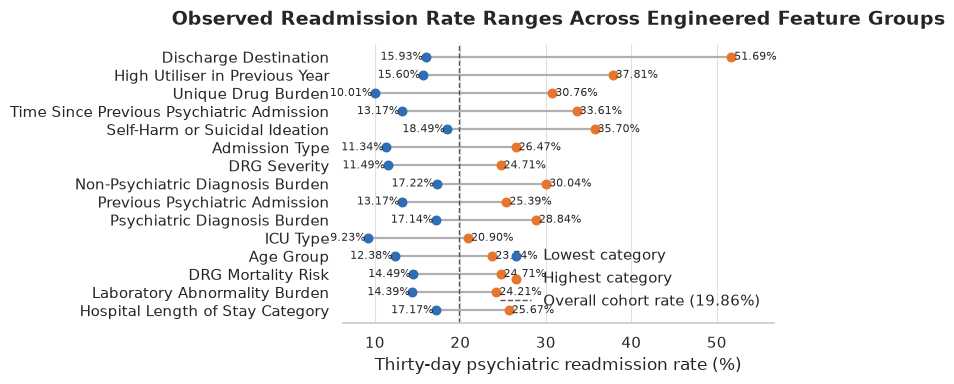

In [98]:
#plot observed readmission-rate ranges across engineered feature groups
if "feature_spread" in globals() and not feature_spread.empty:
    plot_df = feature_spread.head(15).copy()
    plot_df = plot_df.sort_values("Rate difference (percentage points)", ascending=True)
    overall_rate = df["readmitted_30d"].mean() * 100

    fig, ax = plt.subplots(figsize=(8, 4))

    #draw the range between the lowest-risk and highest-risk category in each feature group
    for row_position, (_, row) in enumerate(plot_df.iterrows()):
        ax.plot([row["Lowest rate (%)"], row["Highest rate (%)"]], [row_position, row_position],
            color="#B0B0B0", linewidth=1.6, zorder=1)

    ax.scatter(plot_df["Lowest rate (%)"], range(len(plot_df)), color="#2F6DB5", s=38,
        label="Lowest category", zorder=2)
    ax.scatter(plot_df["Highest rate (%)"], range(len(plot_df)), color="#E6762D", s=38,
        label="Highest category", zorder=2)

    #label both endpoints so the plot can stand alone in the report
    for row_position, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["Lowest rate (%)"] - 0.35, row_position, f"{row['Lowest rate (%)']:.2f}%",
            va="center", ha="right", fontsize=8)
        ax.text(row["Highest rate (%)"] + 0.35, row_position, f"{row['Highest rate (%)']:.2f}%",
            va="center", ha="left", fontsize=8)

    #add the cohort rate as a reference line
    ax.axvline(overall_rate, color="#555555", linestyle="--", linewidth=1,
        label=f"Overall cohort rate ({overall_rate:.2f}%)")

    #style the figure for report-friendly display
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df["Feature group"])
    ax.set_title("Observed Readmission Rate Ranges Across Engineered Feature Groups", fontsize=14, weight="bold", pad=14)
    ax.set_xlabel("Thirty-day psychiatric readmission rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(max(0, plot_df["Lowest rate (%)"].min() - 3), plot_df["Highest rate (%)"].max() + 5)
    ax.grid(axis="x", color="#E0E0E0", linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right", frameon=False)
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()
else:
    print("Feature-spread table is empty, so no readmission-rate range plot was produced.")


#### **T2.4.14 - Report-facing EDA checks**

This section adds compact descriptive checks for older-patient profiles, feature availability, and excluded discharge-status fields. These tables support the methodology and discussion chapters without adding another large block of exploratory plots.


In [99]:

#summarise older-patient risk context using available structured fields
older_group_definitions = [("All admissions", pd.Series(True, index=df.index)),
    ("Age 65+", df["anchor_age"].ge(65) if "anchor_age" in df.columns else pd.Series(False, index=df.index)),
    ("Age 70+", df["anchor_age"].ge(70) if "anchor_age" in df.columns else pd.Series(False, index=df.index)),
    ("Age 80+", df["anchor_age"].ge(80) if "anchor_age" in df.columns else pd.Series(False, index=df.index))]

older_profile_metrics = existing_columns(["has_previous_psych_admission", "previous_psych_admissions_365d",
    "previous_total_admissions_365d", "charlson_comorbidity_index_simplified", "has_cognitive_delirium",
    "had_icu_stay", "protective_aftercare_present_flag", "low_aftercare_quality_flag", "discharged_home_flag",
    "discharged_to_facility_flag", "discharged_to_psych_facility_flag", "quiet_risk_summary_score"])

older_profile_rows = []
for group_label, group_mask in older_group_definitions:
    group_mask = group_mask.fillna(False).astype(bool)
    group_df = df.loc[group_mask].copy()
    if group_df.empty:
        continue
    row = {"Group": group_label, "Admissions": len(group_df),
        "Admissions (%)": round(len(group_df) / len(df) * 100, 2),
        "Readmission Rate (%)": round(group_df["readmitted_30d"].mean() * 100, 2)}
    for feature in older_profile_metrics:
        feature_values = pd.to_numeric(group_df[feature], errors="coerce")
        if set(feature_values.dropna().unique()).issubset({0, 1}):
            row[display_name(feature) + " (%)"] = round(feature_values.mean() * 100, 2)
        else:
            row[display_name(feature) + " mean"] = round(feature_values.mean(), 3)
    older_profile_rows.append(row)

older_patient_profile = pd.DataFrame(older_profile_rows)
print("Older-patient descriptive profile:")
display(older_patient_profile)
save_table(older_patient_profile, "t2_4_older_patient_descriptive_profile")

#summarise older-patient intersections that later modelling can inspect as subgroups
older_intersection_definitions = {"age_70plus_no_previous_psych_admission": ((df["anchor_age"].ge(70) if "anchor_age" in df.columns else False) &
        (pd.to_numeric(df.get("has_previous_psych_admission", 0), errors="coerce").fillna(0).eq(0))),
    "age_70plus_with_cognitive_delirium": ((df["anchor_age"].ge(70) if "anchor_age" in df.columns else False) &
        (pd.to_numeric(df.get("has_cognitive_delirium", 0), errors="coerce").fillna(0).gt(0))),
    "age_70plus_high_charlson": ((df["anchor_age"].ge(70) if "anchor_age" in df.columns else False) &
        (pd.to_numeric(df.get("charlson_comorbidity_index_simplified", 0), errors="coerce").fillna(0).ge(3))),
    "age_70plus_home_discharge": ((df["anchor_age"].ge(70) if "anchor_age" in df.columns else False) &
        (pd.to_numeric(df.get("discharged_home_flag", 0), errors="coerce").fillna(0).gt(0))),
    "age_70plus_low_aftercare_quality": ((df["anchor_age"].ge(70) if "anchor_age" in df.columns else False) &
        (pd.to_numeric(df.get("low_aftercare_quality_flag", 0), errors="coerce").fillna(0).gt(0)))}

older_intersection_rows = []
for subgroup_name, subgroup_mask in older_intersection_definitions.items():
    subgroup_mask = pd.Series(subgroup_mask, index=df.index).fillna(False).astype(bool)
    subgroup_df = df.loc[subgroup_mask]
    if subgroup_df.empty:
        continue
    older_intersection_rows.append({"Subgroup": subgroup_name.replace("_", " "),
        "Admissions": len(subgroup_df),
        "Admissions (%)": round(len(subgroup_df) / len(df) * 100, 2),
        "Readmissions": int(subgroup_df["readmitted_30d"].sum()),
        "Readmission Rate (%)": round(subgroup_df["readmitted_30d"].mean() * 100, 2),
        "Rate Difference vs Overall (pp)": round((subgroup_df["readmitted_30d"].mean() - df["readmitted_30d"].mean()) * 100, 2)})

older_patient_intersections = pd.DataFrame(older_intersection_rows).sort_values(
    "Readmission Rate (%)", ascending=False).reset_index(drop=True)
print("Older-patient readmission-rate intersections:")
display(older_patient_intersections)
save_table(older_patient_intersections, "t2_4_older_patient_readmission_intersections")

#record which feature groups are present in structured data and which remain unavailable
availability_rows = [
    {"Feature group": "Structured demographics", "Availability in current data": "Available", "Examples": "age, gender, language, race, insurance, marital status", "Use in pipeline": "Included in cohort description and modelling inputs"},
    {"Feature group": "Psychiatric diagnoses", "Availability in current data": "Available", "Examples": "psychosis, bipolar disorder, depression, anxiety/PTSD, substance use, self-harm coding", "Use in pipeline": "Included as diagnosis flags and interaction features"},
    {"Feature group": "Hospital utilisation", "Availability in current data": "Available", "Examples": "prior admissions, prior psychiatric admissions, recency windows, ICU exposure", "Use in pipeline": "Included as prior-use and acuity features"},
    {"Feature group": "Orders, medications, labs, vitals, ICU events", "Availability in current data": "Available", "Examples": "POE, pharmacy, EMAR, labevents, ICU chart/input/output/procedure events", "Use in pipeline": "Included as structured burden, timing, and process features"},
    {"Feature group": "Discharge pathway and aftercare indicators", "Availability in current data": "Partly available", "Examples": "structured orders and discharge destination fields", "Use in pipeline": "Included as care-transition indicators, but actual post-discharge attendance is not observed"},
    {"Feature group": "Discharge-note text", "Availability in current data": "Not available in structured extract", "Examples": "clinical narrative, risk formulation, discharge summary wording", "Use in pipeline": "Not included unless MIMIC-IV-Note is separately available"},
    {"Feature group": "Community follow-up after discharge", "Availability in current data": "Not available", "Examples": "community mental health appointments, outpatient psychiatric review, crisis-team contact", "Use in pipeline": "Cannot confirm whether ordered aftercare occurred"},
    {"Feature group": "Social context", "Availability in current data": "Not available", "Examples": "housing status, living arrangement, occupation, income, informal support", "Use in pipeline": "Discussed as an important missing context"},
    {"Feature group": "Post-discharge medication adherence", "Availability in current data": "Not available", "Examples": "filled prescriptions, medication taking after discharge", "Use in pipeline": "Cannot distinguish prescribed from adhered treatment"},
    {"Feature group": "ED-only revisits", "Availability in current data": "Not available unless MIMIC-IV-ED is added", "Examples": "emergency visits without admission", "Use in pipeline": "Not used as a confirmed outcome"}]
feature_availability_summary = pd.DataFrame(availability_rows)
print("Feature availability and missing-context summary:")
display(feature_availability_summary)
save_table(feature_availability_summary, "t2_4_feature_availability_summary")

#document discharge-status fields excluded from modelling because they are not appropriate predictors for readmission risk
exclusion_patterns = ["death", "died", "hospice", "expire"]
exclusion_columns = [column for column in df.columns if any(pattern in column.lower() for pattern in exclusion_patterns)]
exclusion_rows = []
for column in exclusion_columns:
    values = df[column]
    if pd.api.types.is_numeric_dtype(values):
        nonzero_count = int(pd.to_numeric(values, errors="coerce").fillna(0).ne(0).sum())
        nonzero_percent = round(nonzero_count / len(df) * 100, 3)
        example_values = ", ".join(map(str, sorted(pd.Series(values.dropna().unique()).head(5).tolist())))
    else:
        nonzero_count = int(values.notna().sum())
        nonzero_percent = round(nonzero_count / len(df) * 100, 3)
        example_values = ", ".join(map(str, values.dropna().astype(str).value_counts().head(5).index.tolist()))
    exclusion_rows.append({"Column": column, "Non-missing/non-zero rows": nonzero_count,
        "Non-missing/non-zero rows (%)": nonzero_percent, "Example values": example_values,
        "EDA decision": "Audited descriptively only; excluded from modelling inputs where it represents death or hospice discharge status"})

modelling_exclusion_audit = pd.DataFrame(exclusion_rows).sort_values(
    "Non-missing/non-zero rows", ascending=False).reset_index(drop=True) if exclusion_rows else pd.DataFrame(
    [{"Column": "No death/hospice/expire columns found", "Non-missing/non-zero rows": 0,
        "Non-missing/non-zero rows (%)": 0, "Example values": "", "EDA decision": "No exclusion columns found in this run"}])
print("Death/hospice discharge-status exclusion audit:")
display(modelling_exclusion_audit)
save_table(modelling_exclusion_audit, "t2_4_death_hospice_exclusion_audit")

#turn the key descriptive checks into concise report prompts
eda_report_ready_summary = pd.DataFrame([
    {"Report area": "Cohort and outcome", "What to report": f"The 30-day psychiatric readmission prevalence was {df['readmitted_30d'].mean() * 100:.2f}%.", "Supporting table": "t2_4_outcome_distribution"},
    {"Report area": "Predictor scope", "What to report": "The structured feature set covers demographics, diagnoses, prior use, orders, medications, labs, vitals, ICU events, discharge pathway, and aftercare indicators.", "Supporting table": "t2_4_feature_availability_summary"},
    {"Report area": "Missing context", "What to report": "Notes, community follow-up, living situation, occupation, and post-discharge adherence are not available in the structured extract.", "Supporting table": "t2_4_feature_availability_summary"},
    {"Report area": "Older-patient profile", "What to report": "Older admissions are separated descriptively because they combine psychiatric readmission risk with greater medical complexity and different discharge pathways.", "Supporting table": "t2_4_older_patient_descriptive_profile"},
    {"Report area": "Fair modelling inputs", "What to report": "Death and hospice discharge-status fields are audited but excluded from modelling inputs because they are not appropriate predictors for psychiatric readmission risk.", "Supporting table": "t2_4_death_hospice_exclusion_audit"}])
print("Report-ready EDA summary points:")
display(eda_report_ready_summary)
save_table(eda_report_ready_summary, "t2_4_report_ready_eda_summary")


Older-patient descriptive profile:


,Group,Admissions,Admissions (%),Readmission Rate (%),Previous Psychiatric Admission (%),Previous Psychiatric Admissions in 365 Days mean,Previous Hospital Admissions in 365 Days mean,Charlson Comorbidity Index Simplified mean,Cognitive Disorder or Delirium (%),ICU Stay (%),Protective Aftercare Present (%),Low Aftercare Quality (%),Discharged Home (%),Discharged To Facility (%),Discharged To Psych Facility (%),Quiet-Risk Summary Score mean
0,All admissions,238491,100.00,19.86,54.75,1.304,1.604,1.401,13.12,16.98,72.43,12.38,30.40,35.14,1.23,2.480
1,Age 65+,73468,30.81,14.54,48.64,0.755,1.111,2.029,35.58,23.50,87.01,3.91,17.73,58.12,0.48,2.378
2,Age 70+,54581,22.89,13.69,46.90,0.682,1.025,2.042,43.41,23.68,87.13,3.75,14.23,61.22,0.44,2.358
3,Age 80+,26200,10.99,12.38,43.32,0.593,0.908,1.993,59.32,23.35,87.23,3.46,8.53,65.99,0.39,2.322


Added table to workbook sheet: t2_4_older_patient_descriptive_
Older-patient readmission-rate intersections:


,Subgroup,Admissions,Admissions (%),Readmissions,Readmission Rate (%),Rate Difference vs Overall (pp)
0,age 70plus low aftercare quality,2048,0.86,406,19.82,-0.03
1,age 70plus high charlson,19535,8.19,3103,15.88,-3.97
2,age 70plus with cognitive delirium,23695,9.94,3057,12.90,-6.96
3,age 70plus home discharge,7767,3.26,972,12.51,-7.34
4,age 70plus no previous psych admission,28983,12.15,2919,10.07,-9.79


Added table to workbook sheet: t2_4_older_patient_readmission_
Feature availability and missing-context summary:


...

,Column,Non-missing/non-zero rows,Non-missing/non-zero rows (%),Example values,EDA decision
0,No death/hospice/expire columns found,0,0,,No exclusion columns found in this run


Added table to workbook sheet: t2_4_death_hospice_exclusion_au
Report-ready EDA summary points:


,Report area,What to report,Supporting table
0,Cohort and outcome,The 30-day psychiatric readmission prevalence ...,t2_4_outcome_distribution
1,Predictor scope,The structured feature set covers demographics...,t2_4_feature_availability_summary
2,Missing context,"Notes, community follow-up, living situation, ...",t2_4_feature_availability_summary
3,Older-patient profile,Older admissions are separated descriptively b...,t2_4_older_patient_descriptive_profile
4,Fair modelling inputs,Death and hospice discharge-status fields are ...,t2_4_death_hospice_exclusion_audit


Added table to workbook sheet: t2_4_report_ready_eda_summary


't2_4_report_ready_eda_summary'

#### **T2.4.15 - EDA audit summary**

This final check records the input files, feature-domain coverage, compact EDA scope, and workbook outputs so the saved tables can be traced cleanly during reporting.


In [100]:

#final audit summary for the eda workbook
represented_domain_count = int((engineered_feature_family_summary["Features present in dataset"] > 0).sum()) if "engineered_feature_family_summary" in globals() else np.nan
total_domain_count = int(len(engineered_feature_family_summary)) if "engineered_feature_family_summary" in globals() else np.nan
present_listed_feature_count = int(engineered_feature_family_summary["Features present in dataset"].sum()) if "engineered_feature_family_summary" in globals() else np.nan
missing_listed_feature_count = int(engineered_feature_family_summary["Missing listed features"].sum()) if "engineered_feature_family_summary" in globals() and "Missing listed features" in engineered_feature_family_summary.columns else np.nan

admission_audit_row = input_audit.loc[input_audit["Dataset"].eq("Admission-Level Engineered Dataset")].iloc[0]
hourly_audit_rows = input_audit.loc[input_audit["Dataset"].eq("Hourly Clinical Sequence Dataset")]
hourly_audit_row = hourly_audit_rows.iloc[0] if not hourly_audit_rows.empty else None

eda_audit_rows = [
    {"Audit item": "Admission-level input", "Result": f"{int(admission_audit_row['Observed Rows']):,} rows x {int(admission_audit_row['Observed Columns']):,} total columns", "Workbook table": "t2_4_input_dataset_audit"},
    {"Audit item": "Admission-level reference comparison", "Result": f"reference was {int(admission_audit_row['Reference Rows']):,} rows x {int(admission_audit_row['Reference Columns']):,} columns; current run is recorded while allowing feature-count drift", "Workbook table": "t2_4_input_dataset_audit"},
    {"Audit item": "Outcome column", "Result": "readmitted_30d present and summarised as 30-day psychiatric readmission", "Workbook table": "t2_4_outcome_distribution"},
    {"Audit item": "Engineered-feature count reported by WP2.3", "Result": f"{expected_engineered_feature_count_reported_by_wp2_3:,} engineered features in the reference WP2.3 summary", "Workbook table": "t2_4_dataset_summary"},
    {"Audit item": "Feature-domain coverage", "Result": f"{represented_domain_count} of {total_domain_count} listed EDA domains have at least one matching dataset column", "Workbook table": "t2_4_engineered_feature_family_coverage"},
    {"Audit item": "Listed engineered features represented", "Result": f"{present_listed_feature_count} present; {missing_listed_feature_count} listed-but-absent", "Workbook table": "t2_4_engineered_feature_family_missing_listed_features"},
    {"Audit item": "Report-facing additions", "Result": "older-patient profile, feature availability, modelling exclusion audit, and report-ready EDA summary included", "Workbook table": "t2_4_report_ready_eda_summary"},
    {"Audit item": "Workbook table count after final audit tables", "Result": f"{len(eda_tables) + 2:,} tables collected", "Workbook table": "All saved sheets"}]

if hourly_audit_row is not None:
    eda_audit_rows.insert(1, {"Audit item": "Hourly clinical sequence input",
        "Result": f"{int(hourly_audit_row['Observed Rows']):,} rows x {int(hourly_audit_row['Observed Columns']):,} total columns",
        "Workbook table": "t2_4_input_dataset_audit"})

eda_audit_summary = pd.DataFrame(eda_audit_rows)

compact_scope_table = pd.DataFrame([
    {"Area": "Sparse order, pharmacy, EMAR, and HCPCS indicators", "EDA handling": "Summarised through prevalence and readmission-rate contrast tables rather than individual plots for every flag"},
    {"Area": "Laboratory and vital-sign derivatives", "EDA handling": "Summarised through missingness, compact correlations, burden scores, and selected high-signal contrasts"},
    {"Area": "Clinical timeline sequence channels", "EDA handling": "Summarised through admission-hour coverage and feature-family density because the row unit differs from admission-level predictors"},
    {"Area": "Interaction and score features", "EDA handling": "Covered through engineered-domain screening and rate-spread tables to keep the notebook readable"},
    {"Area": "Death/hospice discharge-status fields", "EDA handling": "Audited descriptively and excluded from modelling inputs where they reflect endpoint status rather than readmission risk"},
    {"Area": "Raw identifiers", "EDA handling": "Not profiled as predictors because identifiers are not clinically interpretable model features"}])

print("EDA audit summary:")
display(eda_audit_summary)
save_table(eda_audit_summary, "t2_4_eda_audit_summary")
save_table(compact_scope_table, "t2_4_compact_eda_scope")


EDA audit summary:


,Audit item,Result,Workbook table
0,Admission-level input,"238,491 rows x 1,442 total columns",t2_4_input_dataset_audit
1,Hourly clinical sequence input,"1,550,947 rows x 39 total columns",t2_4_input_dataset_audit
2,Admission-level reference comparison,"reference was 238,491 rows x 1,402 columns; cu...",t2_4_input_dataset_audit
3,Outcome column,readmitted_30d present and summarised as 30-da...,t2_4_outcome_distribution
4,Engineered-feature count reported by WP2.3,972 engineered features in the reference WP2.3...,t2_4_dataset_summary
5,Feature-domain coverage,10 of 10 listed EDA domains have at least one ...,t2_4_engineered_feature_family_coverage
6,Listed engineered features represented,179 present; 0 listed-but-absent,t2_4_engineered_feature_family_missing_listed_...
7,Report-facing additions,"older-patient profile, feature availability, m...",t2_4_report_ready_eda_summary
8,Workbook table count after final audit tables,96 tables collected,All saved sheets


Added table to workbook sheet: t2_4_eda_audit_summary
Added table to workbook sheet: t2_4_compact_eda_scope


't2_4_compact_eda_scope'

In [101]:
#write all collected eda tables to one excel workbook
with pd.ExcelWriter(eda_workbook_file, engine="openpyxl") as writer:
    for sheet_name, table in eda_tables.items():
        table.to_excel(writer, sheet_name=sheet_name, index=False)

print("Saved all EDA tables to one workbook:")
print(eda_workbook_file)
print("Number of tables saved:", len(eda_tables))

Saved all EDA tables to one workbook:
/scratch/DissProject/outputs/t2_4_eda_tables.xlsx
Number of tables saved: 96
